# Shear Zone WTMM — Calamita / Kuckaus / Josephine

Multifractal analysis of EBSD maps from naturally deformed rocks cut **parallel to lineation** (XZ sections) for kinematic interpretation.

**Datasets** (all XZ geometry verified from paper metadata):

| Folder | Rock | Format | Paper |
|---|---|---|---|
| `Calamita_Elba_Quartzite/` | Quartz mylonite, brittle-ductile transition | Oxford `.cpr/.crc` (binary) | Papeschi & Musumeci, *Data in Brief* 2019 |
| `Kuckaus_Namibia_Feldspar_Mylonite/` | Polymineralic (qtz + Kfs + plag) mid-crustal shear zone | Oxford `.cpr/.crc` (binary) | Stenvall, Muir & Fagereng, *GRL* 2019 |
| `Josephine_Peridotite_Olivine/ctf_files/` | Natural mantle shear zones (olivine + opx + cpx) | `.ctf` (ASCII) | Kumamoto, Warren & Hansen, *JGR Solid Earth* 2019 |

**Loader status**: `.ctf` files load natively. `.cpr/.crc` (Oxford binary) requires a one-time export to `.ctf` via MTEX or Aztec before the notebook can see them — see the discovery cell for details.

**Josephine rotation metadata**: the shipped `1365-3_RotationMetadata.xlsx` carries per-sample Euler-angle triples that transform each EBSD map from its as-scanned sample frame into the shear-zone frame (x ∥ shear direction, y ∥ shear plane normal). The rotation is applied automatically when a Josephine file is selected. For KAM-based WTMM the rotation is formally irrelevant (KAM is rotation-invariant), but applying it keeps IPF maps and pole figures in the kinematic frame where shear sense can be read off directly.


In [415]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.fft import fftfreq
import ipywidgets as widgets
from IPython.display import display
import sys

import mlx.core as mx

sys.path.insert(0, 'XSmurfWrapper')
import xsmurf_wrapper as xsm

print(f"MLX: {mx.__version__}, xsmurf: {xsm.__version__}")
# --- Shear-zone additions ---
try:
    from orix.quaternion import Orientation, Rotation
    from orix.quaternion.symmetry import D2, D3, C1
    _HAS_ORIX = True
    print(f'orix available for rotation + symmetry ops')
except ImportError:
    _HAS_ORIX = False
    print('orix not in this env — rotation + KAM fall back to pure-numpy path')

JOSEPHINE_ROTATION_XLSX = Path('EBSD/Josephine_Peridotite_Olivine/1365-3_RotationMetadata.xlsx')


MLX: 0.31.1, xsmurf: 0.1.0
orix available for rotation + symmetry ops


In [416]:
%matplotlib widget


## EBSD File Readers (CTF + CPR/CRC)


In [417]:
def read_ctf(filepath):
    """Read an Oxford Instruments .ctf (Channel Text File) EBSD dataset.
    
    Returns
    -------
    data : dict with 2D arrays for each field + metadata dict
    """
    filepath = Path(filepath)
    with open(filepath, 'r', errors='replace') as f:
        lines = f.readlines()

    meta = {'filepath': str(filepath), 'name': filepath.stem}
    phases = {}
    header_line = None

    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.startswith('XCells'):
            meta['xcells'] = int(stripped.split('\t')[1])
        elif stripped.startswith('YCells'):
            meta['ycells'] = int(stripped.split('\t')[1])
        elif stripped.startswith('XStep'):
            meta['xstep'] = float(stripped.split('\t')[1])
        elif stripped.startswith('YStep'):
            meta['ystep'] = float(stripped.split('\t')[1])
        elif stripped.startswith('Phases'):
            n_phases = int(stripped.split('\t')[1])
            for j in range(1, n_phases + 1):
                phases[j] = lines[i + j].strip().split('\t')
            meta['phases'] = phases
            meta['n_phases'] = n_phases
        elif stripped.startswith('Phase\tX\tY'):
            header_line = i
            break

    if header_line is None:
        raise ValueError(f"Could not find data header in {filepath}")

    # Read tabular data
    df = pd.read_csv(filepath, sep='\t', skiprows=header_line, engine='python',
                     on_bad_lines='skip')
    
    nx, ny = meta['xcells'], meta['ycells']
    expected = nx * ny
    actual = len(df)
    if actual != expected:
        print(f"  Warning: expected {expected} rows ({nx}x{ny}), got {actual}")
        # Truncate or pad
        if actual > expected:
            df = df.iloc[:expected]
        else:
            nx_adj = actual // ny if ny > 0 else nx
            meta['xcells'] = nx_adj
            nx = nx_adj

    data = {'meta': meta}
    shape = (ny, nx)
    for col in df.columns:
        try:
            data[col] = df[col].values.reshape(shape)
        except ValueError:
            data[col] = df[col].values  # keep flat if reshape fails

    # Convenience aliases
    data['euler1'] = data.get('Euler1', None)
    data['euler2'] = data.get('Euler2', None)
    data['euler3'] = data.get('Euler3', None)
    data['bc'] = data.get('BC', None)
    data['bs'] = data.get('BS', None)
    data['mad'] = data.get('MAD', None)
    data['phase'] = data.get('Phase', None)

    print(f"  Loaded {filepath.name}: {nx} x {ny}, step={meta.get('xstep','?')} µm, "
          f"{meta.get('n_phases','?')} phases")
    return data
# --- Oxford Instruments Channel 5 .cpr/.crc binary reader ---
# Pure-numpy reader for .cpr (ASCII INI metadata) + .crc (binary data) pairs.
# Field code mapping taken from defdap.file_readers.OxfordBinaryLoader source.
# Unlike defdap's loader, this one does NOT construct a crystal Phase object
# so it works for any Laue group (including trigonal quartz, monoclinic
# feldspars, etc.) that the narrow defdap Phase class would reject.

import re as _re_cpr

_CPR_FIELD_LOOKUP = {
    3:  ('ph1',      'float32'),   # Euler1 phi1 (rad)
    4:  ('phi',      'float32'),   # Euler2 Phi  (rad)
    5:  ('ph2',      'float32'),   # Euler3 phi2 (rad)
    6:  ('MAD',      'float32'),   # mean angular deviation
    7:  ('BC',       'uint8'),     # band contrast
    8:  ('BS',       'uint8'),     # band slope
    10: ('numBands', 'uint8'),
    11: ('AFI',      'uint8'),
    12: ('IB6',      'float32'),
}


def _parse_cpr_ini(cpr_path):
    text = Path(cpr_path).read_text(errors='replace')
    groups = {}
    current = None
    group_re = _re_cpr.compile(r'^\[(.+)\]\s*$')
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith(';'):
            continue
        m = group_re.match(line)
        if m:
            current = m.group(1)
            groups.setdefault(current, {})
            continue
        if current is None:
            continue
        if '=' in line:
            k, v = line.split('=', 1)
            groups[current][k.strip()] = v.strip()
    return groups


def read_cpr(filepath):
    """Read an Oxford Instruments .cpr/.crc file pair.

    Returns the same dict shape as read_ctf():
        meta          dict with xcells, ycells, xstep, ystep, phases, n_phases, name
        euler1/2/3    (ny, nx) float32 arrays in DEGREES
        phase         (ny, nx) uint8 array
        bc, bs, mad   (ny, nx) arrays if present
        Plus any EDX windows as EDX_<element> keys.
    """
    filepath = Path(filepath)
    cpr_path = filepath.with_suffix('.cpr')
    crc_path = filepath.with_suffix('.crc')
    if not cpr_path.exists():
        raise FileNotFoundError(f"CPR header not found: {cpr_path}")
    if not crc_path.exists():
        raise FileNotFoundError(f"CRC binary not found: {crc_path}")

    groups = _parse_cpr_ini(cpr_path)

    # Grid & step
    job = groups.get('Job', {})
    nx = int(job['xCells'])
    ny = int(job['yCells'])
    xstep = float(job.get('GridDistX', 1.0))
    ystep = float(job.get('GridDistY', xstep))

    # Phases: assemble ctf-like metadata so downstream cells keep working
    pg = groups.get('Phases', {})
    n_phases = int(pg.get('Count', 0))
    phases = {}
    for i in range(1, n_phases + 1):
        pi = groups.get(f'Phase{i}', {})
        lattice = '{};{};{}'.format(pi.get('a', '?'), pi.get('b', '?'), pi.get('c', '?'))
        angles = '{};{};{}'.format(pi.get('alpha', '?'), pi.get('beta', '?'), pi.get('gamma', '?'))
        phases[i] = [lattice, angles,
                     pi.get('StructureName', f'phase_{i}'),
                     pi.get('LaueGroup', '?'), pi.get('SpaceGroup', '?')]

    # EDX window names (field codes 100+i)
    edx_names = {}
    edx_group = groups.get('EDX Windows', {})
    if edx_group:
        n_edx = int(edx_group.get('Count', 0))
        for i in range(1, n_edx + 1):
            key = edx_group.get(f'Window{i}', f'edx{i}')
            edx_names[100 + i] = key

    # Build the binary record dtype from the [Fields] section
    fg = groups.get('Fields', {})
    n_fields = int(fg.get('Count', 0))
    dtype_items = [('phase', 'uint8')]   # phase is always first, uint8
    unknown = 0
    for i in range(1, n_fields + 1):
        code = int(fg[f'Field{i}'])
        if code in _CPR_FIELD_LOOKUP:
            dtype_items.append(_CPR_FIELD_LOOKUP[code])
        elif code in edx_names:
            dtype_items.append((f'EDX_{edx_names[code]}', 'float32'))
        else:
            unknown += 1
            dtype_items.append((f'unknown_{unknown}_code{code}', 'float32'))
            print(f'  warning: unknown CPR field code {code}, guessing float32')
    record_dtype = np.dtype(dtype_items)

    # Load binary
    raw = np.fromfile(str(crc_path), dtype=record_dtype, count=nx * ny)
    if raw.size != nx * ny:
        raw = raw[:nx * ny]
        print(f'  warning: CRC short read ({raw.size} records)')

    shape = (ny, nx)
    data = {'meta': {
        'filepath': str(filepath),
        'name': filepath.stem,
        'xcells': nx, 'ycells': ny,
        'xstep': xstep, 'ystep': ystep,
        'phases': phases, 'n_phases': n_phases,
        'format': 'cpr',
    }}

    data['phase'] = raw['phase'].reshape(shape)

    # CPR stores Euler in radians; convert to degrees to match ctf convention
    for raw_key, deg_key in [('ph1', 'euler1'), ('phi', 'euler2'), ('ph2', 'euler3')]:
        if raw_key in raw.dtype.names:
            data[deg_key] = np.rad2deg(raw[raw_key].reshape(shape)).astype(np.float32)

    if 'MAD' in raw.dtype.names: data['mad'] = raw['MAD'].reshape(shape)
    if 'BC'  in raw.dtype.names: data['bc']  = raw['BC'].reshape(shape)
    if 'BS'  in raw.dtype.names: data['bs']  = raw['BS'].reshape(shape)
    if 'numBands' in raw.dtype.names: data['bands'] = raw['numBands'].reshape(shape)
    for name in raw.dtype.names:
        if name.startswith('EDX_'):
            data[name] = raw[name].reshape(shape)

    print(f'  CPR: {nx}x{ny} @ {xstep} um, {n_phases} phases, {len(dtype_items)} fields')
    return data


def read_ebsd(filepath):
    """Dispatch to the right EBSD reader based on file extension."""
    filepath = Path(filepath)
    ext = filepath.suffix.lower()
    if ext == '.ctf':
        return read_ctf(filepath)
    elif ext in ('.cpr', '.crc'):
        return read_cpr(filepath)
    else:
        raise ValueError(f"Unsupported EBSD extension: {ext} (expected .ctf or .cpr/.crc)")


## IPF Coloring (Cubic Symmetry)

Proper Inverse Pole Figure coloring: Euler angles → rotation matrix → crystal direction 
→ reduce to fundamental zone → map position in stereographic triangle to RGB.

Standard convention: **[001]=Red, [011]=Green, [111]=Blue**.

In [418]:
def ipf_color_cubic(phi1_deg, Phi_deg, phi2_deg, sample_dir='Z'):
    """Compute IPF colors for cubic crystal symmetry (m-3m).
    
    Bunge convention: g = Z(φ₁) · X(Φ) · Z(φ₂)
    Crystal direction: h = g^T · sample_direction
    Reduced to fundamental zone, then mapped to RGB via:
        [001] = Red,  [011] = Green,  [111] = Blue
    
    Parameters
    ----------
    phi1_deg, Phi_deg, phi2_deg : 2D arrays, Euler angles in degrees
    sample_dir : 'X', 'Y', or 'Z' — which sample direction to project
    
    Returns
    -------
    rgb : (ny, nx, 3) float array in [0, 1]
    """
    p1 = np.radians(phi1_deg)
    P  = np.radians(Phi_deg)
    p2 = np.radians(phi2_deg)
    
    c1, s1 = np.cos(p1), np.sin(p1)
    cP, sP = np.cos(P),  np.sin(P)
    c2, s2 = np.cos(p2), np.sin(p2)
    
    # Rotation matrix g (Bunge ZXZ convention), then h = g^T @ sample_dir
    if sample_dir == 'Z':
        # h = g^T @ [0,0,1] = 3rd row of g
        hx = s1 * sP
        hy = -c1 * sP
        hz = cP
    elif sample_dir == 'X':
        # h = g^T @ [1,0,0] = 1st row of g
        hx = c1*c2 - s1*s2*cP
        hy = s1*c2 + c1*s2*cP
        hz = s2*sP
    elif sample_dir == 'Y':
        # h = g^T @ [0,1,0] = 2nd row of g
        hx = -c1*s2 - s1*c2*cP
        hy = -s1*s2 + c1*c2*cP
        hz = c2*sP
    
    # Cubic symmetry: take absolute values and sort ascending → fundamental zone
    h = np.stack([np.abs(hx), np.abs(hy), np.abs(hz)], axis=-1)
    h = np.sort(h, axis=-1)  # h[...,0] ≤ h[...,1] ≤ h[...,2]
    
    h0, h1, h2 = h[..., 0], h[..., 1], h[..., 2]
    
    # Map position in standard triangle to RGB
    # At [001]=(0,0,1): r=1,g=0,b=0  (Red)
    # At [011]=(0,1,1): r=0,g=1,b=0  (Green)
    # At [111]=(1,1,1): r=0,g=0,b=1  (Blue)
    r = h2 - h1    # distance from [011]-[111] edge
    g = h1 - h0    # distance from [001]-[111] edge
    b = h0          # distance from [001]-[011] edge
    
    # Normalize so max channel = 1 (full saturation)
    rgb_max = np.maximum(np.maximum(r, g), np.maximum(b, 1e-30))
    r = r / rgb_max
    g = g / rgb_max
    b = b / rgb_max
    
    rgb = np.stack([r, g, b], axis=-1).astype(np.float32)
    return np.clip(rgb, 0, 1)


def ipf_color_key(ax, n=512):
    """Draw the standard cubic IPF color key triangle on an axis.
    Vertices: [001]=Red, [011]=Green, [111]=Blue.
    """
    # Generate points inside the stereographic triangle
    img = np.zeros((n, n, 3), dtype=np.float32)
    for iy in range(n):
        for ix in range(n):
            # Barycentric-ish: map pixel to (h0, h1, h2) in fundamental zone
            # x-axis: [001] to [011], y-axis: toward [111]
            u = ix / (n - 1)  # 0=[001] side, 1=[011] side
            v = iy / (n - 1)  # 0=bottom edge, 1=[111]
            
            # Parameterize crystal direction
            h0 = v / np.sqrt(3)           # [111] component
            h1 = u * (1 - v + v/np.sqrt(2))  
            h2 = 1.0
            
            # Ensure h0 ≤ h1 ≤ h2
            h_sorted = np.sort([h0, h1, h2])
            h0s, h1s, h2s = h_sorted
            
            # Check if in fundamental zone: h0 ≤ h1 ≤ h2
            norm = np.sqrt(h0s**2 + h1s**2 + h2s**2)
            if norm < 1e-10:
                continue
            h0s, h1s, h2s = h0s/norm, h1s/norm, h2s/norm
            
            r = h2s - h1s
            g = h1s - h0s
            b = h0s
            mx = max(r, g, b, 1e-30)
            img[n - 1 - iy, ix] = [r/mx, g/mx, b/mx]
    
    # Mask outside the triangle
    for iy in range(n):
        for ix in range(n):
            if img[iy, ix].sum() == 0:
                img[iy, ix] = 1.0  # white background
    
    ax.imshow(img, extent=[0, 1, 0, 1])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['001', '011'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['', '111'])
    ax.set_aspect('equal')
    ax.set_title('IPF Key (cubic)')


# Faster vectorized color key using meshgrid
def ipf_color_key_fast(ax, n=256):
    """Vectorized IPF color key for cubic symmetry."""
    # Sample the fundamental zone in spherical coordinates
    # chi: 0 to pi/4 (angle in the (h0,h1) plane)  
    # eta: 0 to ~54.7° (angle from [001] toward equator)
    chi = np.linspace(0, np.pi/4, n)
    eta = np.linspace(0, np.arctan(np.sqrt(2)), n)
    CHI, ETA = np.meshgrid(chi, eta)
    
    # Crystal direction from angles
    h2 = np.cos(ETA)
    h1 = np.sin(ETA) * np.cos(CHI)
    h0 = np.sin(ETA) * np.sin(CHI)
    
    # Mask: must satisfy h0 ≤ h1 ≤ h2 (fundamental zone constraint)
    valid = (h0 <= h1 + 1e-10) & (h1 <= h2 + 1e-10)
    
    r = h2 - h1
    g = h1 - h0
    b = h0
    mx = np.maximum(np.maximum(r, g), np.maximum(b, 1e-30))
    
    img = np.ones((n, n, 3), dtype=np.float32)  # white background
    img[..., 0] = np.where(valid, r / mx, 1)
    img[..., 1] = np.where(valid, g / mx, 1)
    img[..., 2] = np.where(valid, b / mx, 1)
    
    ax.imshow(img[::-1], extent=[0, 45, 0, np.degrees(np.arctan(np.sqrt(2)))])
    ax.set_xlabel('χ (°)')
    ax.set_ylabel('η (°)')
    ax.text(0, 0, '001', fontsize=10, fontweight='bold', color='red',
            ha='left', va='bottom')
    ax.text(45, 0, '011', fontsize=10, fontweight='bold', color='green',
            ha='right', va='bottom')
    ax.text(45, np.degrees(np.arctan(np.sqrt(2))), '111', fontsize=10,
            fontweight='bold', color='blue', ha='right', va='top')
    ax.set_title('IPF Key (cubic)')

print("IPF coloring functions defined (cubic symmetry)")

IPF coloring functions defined (cubic symmetry)


## 2D CWT + Tensor SVD Functions

Same `cwt_2d_f32` and `tensor_svd_3x2` from `xsm_synthetic_tensor.ipynb`.

In [419]:
def compute_scales(n_oct, n_vox, a_min=1):
    norm = 6.0 / 0.86
    return [a_min * (2.0 ** (o + v / n_vox)) * norm
            for o in range(n_oct) for v in range(n_vox)]

def _build_wavelet_filters_f32(kx, ky, scale, wavelet='gaussian'):
    sx = kx * scale
    sy = ky * scale
    gauss = mx.exp(-(sx * sx + sy * sy))
    zero = mx.zeros_like(gauss)
    def to_complex(r, i):
        return mx.stack([r, i], axis=-1).view(mx.complex64).squeeze(-1)
    if wavelet == 'mexican':
        k2 = sx * sx + sy * sy
        return {
            'dx':  to_complex(zero, sx * k2 * gauss),
            'dy':  to_complex(zero, sy * k2 * gauss),
            'dxx':  to_complex(-sx * sx * k2 * gauss, zero),
            'dxy':  to_complex(-sy * sx * k2 * gauss, zero),
            'dyy':  to_complex(-sy * sy * k2 * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * k2 * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * k2 * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * k2 * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * k2 * gauss),
        }
    else:
        return {
            'dx':  to_complex(zero, sx * gauss),
            'dy':  to_complex(zero, sy * gauss),
            'dxx':  to_complex(-sx * sx * gauss, zero),
            'dxy':  to_complex(-sy * sx * gauss, zero),
            'dyy':  to_complex(-sy * sy * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * gauss),
        }

def cwt_2d_f32(image, scales, pad=32, derivs='first', wavelet='gaussian', verbose=True):
    """2D CWT via MLX FFT. derivs='first' for dx,dy only; 'all' for up to 3rd order."""
    ny, nx = image.shape
    padded = np.pad(image, pad, mode='reflect').astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx))
    kx_np = fftfreq(nx_p).astype(np.float32)
    ky_np = fftfreq(ny_p).astype(np.float32)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX, KY = mx.array(KX_np), mx.array(KY_np)
    image_fft = mx.fft.fft2(mx.array(padded))
    if derivs == 'first':
        names = ['dx', 'dy']
    else:
        names = ['dx', 'dy', 'dxx', 'dxy', 'dyy', 'dxxx', 'dxxy', 'dxyy', 'dyyy']
    n_scales = len(scales)
    result = {n: np.zeros((n_scales, ny, nx), dtype=np.float32) for n in names}
    result['mod'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    result['arg'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    for i, scale in enumerate(scales):
        filters = _build_wavelet_filters_f32(KX, KY, scale, wavelet=wavelet)
        for name in names:
            conv = mx.fft.ifft2(image_fft * filters[name])
            result[name][i] = np.array(conv.real)[crop]
        dx_s, dy_s = result['dx'][i], result['dy'][i]
        result['mod'][i] = np.sqrt(dx_s * dx_s + dy_s * dy_s)
        result['arg'][i] = np.arctan2(dy_s, dx_s).astype(np.float32)
        if verbose and (i % max(1, n_scales // 4) == 0 or i == n_scales - 1):
            print(f'  Scale {i}/{n_scales-1}: a={scale:.1f}')
    mx.eval()
    return result

def tensor_svd_3x2(gx1, gy1, gx2, gy2, gx3, gy3):
    """SVD of 3x2 Jacobian at every pixel via closed-form J^T J eigenvalues."""
    a = gx1*gx1 + gx2*gx2 + gx3*gx3
    b = gx1*gy1 + gx2*gy2 + gx3*gy3
    d = gy1*gy1 + gy2*gy2 + gy3*gy3
    trace = a + d
    det = a * d - b * b
    disc = np.sqrt(np.maximum((trace / np.float32(2))**2 - det, np.float32(0)))
    lambda1 = trace / np.float32(2) + disc
    lambda2 = np.maximum(trace / np.float32(2) - disc, np.float32(0))
    sigma_max = np.sqrt(np.maximum(lambda1, np.float32(0))).astype(np.float32)
    sigma_min = np.sqrt(lambda2).astype(np.float32)
    vx = lambda1 - d
    vy = b
    vnorm = np.sqrt(vx**2 + vy**2) + np.float32(1e-30)
    arg = np.arctan2(vy / vnorm, vx / vnorm).astype(np.float32)
    return sigma_max, sigma_min, arg

from xsmurf_wrapper.wavelet import gkapa_numpy, gkapap_numpy


print('CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined')


CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined


## Discover & Select Shear Zone Dataset

Globs `EBSD/**/*.ctf` (loadable) and `EBSD/**/*.cpr` (needs conversion) and groups by parent folder so you can tell the three datasets apart. Pick a file by its numeric index in the next cell.


In [420]:
EBSD_DIR = Path('EBSD')

# --- Loadable files: .ctf (ASCII) and .cpr (Oxford binary via read_cpr) ---
ctf_files = sorted(EBSD_DIR.rglob('*.ctf'))
cpr_files = sorted(EBSD_DIR.rglob('*.cpr'))
ebsd_files = sorted(ctf_files + cpr_files, key=lambda p: (p.parts[:-1], p.name))

# Shear-zone folder tags
SHEAR_ZONE_TAGS = {
    'Calamita_Elba_Quartzite':           ('[CAL]', 'Calamita quartzite'),
    'Kuckaus_Namibia_Feldspar_Mylonite': ('[KUC]', 'Kuckaus polymineralic mylonite'),
    'Josephine_Peridotite_Olivine':      ('[JOS]', 'Josephine peridotite'),
}

def _tag(path):
    rel = path.relative_to(EBSD_DIR)
    root = rel.parts[0] if rel.parts else ''
    return SHEAR_ZONE_TAGS.get(root, ('[...]', root))[0]

labels = []
for p in ebsd_files:
    rel = p.relative_to(EBSD_DIR)
    labels.append(f'{_tag(p)} {rel}  [{p.suffix[1:]}]')

print(f'Found {len(ebsd_files)} EBSD files ({len(ctf_files)} CTF + {len(cpr_files)} CPR):\n')
from collections import defaultdict
by_tag = defaultdict(list)
for i, p in enumerate(ebsd_files):
    by_tag[_tag(p)].append(i)
for tag, idxs in by_tag.items():
    print(f'  {tag}  ({len(idxs)} files)')
    for i in idxs:
        rel = ebsd_files[i].relative_to(EBSD_DIR)
        print(f'    [{i:3d}] {rel}  [{ebsd_files[i].suffix[1:]}]')
    print()


Found 61 EBSD files (54 CTF + 7 CPR):

  [...]  (24 files)
    [  0] 2013-05-16_Pearce_Mark_6535v1/data/Overview_Map_Processed.ctf  [ctf]
    [  1] 2013-05-16_Pearce_Mark_6535v1/data/Overview_Map_Raw.ctf  [ctf]
    [  2] 2013-05-16_Pearce_Mark_6535v1/data/Siderite_Detail_Processed.ctf  [ctf]
    [  3] 2013-05-16_Pearce_Mark_6535v1/data/Siderite_Detail_Raw.ctf  [ctf]
    [  4] 2015-06-19_Pearce_Mark_13960v1/data/Large_Albite.ctf  [ctf]
    [  5] 2015-06-19_Pearce_Mark_13960v1/data/Large_Albite_processed.ctf  [ctf]
    [  6] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_Original.ctf  [ctf]
    [  7] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4ci.ctf  [ctf]
    [  8] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4cii.ctf  [ctf]
    [  9] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4ciii.ctf  [ctf]
    [ 10] 2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4di.ctf  [ctf]
    [ 11] 2015-06-26_Pearce_Mark_13963v1/data/Twinn

In [421]:
# ---- Pick a dataset by index ----
DATASET_IDX = 57  # <-- change this to select a different file

ebsd_path = ebsd_files[DATASET_IDX]
ctf_path = ebsd_path                        # alias: downstream cells look at ctf_path
print(f'Selected: {labels[DATASET_IDX]}')
print(f'  Path: {ebsd_path}')

ebsd = read_ebsd(ebsd_path)
meta = ebsd['meta']


Selected: [KUC] Kuckaus_Namibia_Feldspar_Mylonite/Mylonite.cpr  [cpr]
  Path: EBSD/Kuckaus_Namibia_Feldspar_Mylonite/Mylonite.cpr
  CPR: 1929x353 @ 1.0 um, 1 phases, 10 fields


## Josephine: sample → structural frame rotation + KAM scalar field

Kumamoto et al. (2019) provide per-sample Euler rotations that bring each EBSD map into the kinematic reference frame where *x* is parallel to the shear direction and *y* is parallel to the shear plane normal. Without applying this rotation, pole figures and IPF maps will be in an arbitrary sample-holder frame, and shear sense cannot be read off directly.

Applied automatically below when the selected file is in `Josephine_Peridotite_Olivine/`. For the Calamita and Kuckaus datasets the section is already in the XZ kinematic frame on ingest, so the rotation is the identity.

After the rotation block, a **KAM** (kernel average misorientation) scalar field is computed from the rotated orientations using a 1-ring (8-neighbor) kernel. KAM is rotation-invariant, so it's also what you should feed into the WTMM partition function when you want the multifractal spectrum to measure intrinsic strain localization independent of your sample-frame choice. It is stored as `ebsd['kam']` in units of degrees for downstream cells.

In [422]:
# --- Parse Josephine rotation metadata (file -> sample-frame rotation) ---
def load_josephine_rotations(xlsx_path=JOSEPHINE_ROTATION_XLSX):
    if not Path(xlsx_path).exists():
        return {}
    df = pd.read_excel(xlsx_path, sheet_name=0, header=None)
    rotations = {}
    current_zone = None
    for i in range(df.shape[0]):
        row = df.iloc[i].tolist()
        first = str(row[0]) if pd.notna(row[0]) else ''
        if first.startswith('Shear Zone'):
            current_zone = first.strip()
            continue
        if pd.notna(row[2]) and str(row[2]).endswith('.ctf') and pd.notna(row[3]):
            fname = str(row[2]).strip()
            try:
                f1, F, f2 = float(row[3]), float(row[4]), float(row[5])
                rotations[fname] = {
                    'sample': str(row[0]).strip(),
                    'igsn':   str(row[1]).strip() if pd.notna(row[1]) else None,
                    'zone':   current_zone,
                    'euler_rot_deg': (f1, F, f2),
                }
            except Exception:
                pass
    return rotations

JOSEPHINE_ROTATIONS = load_josephine_rotations()
print(f'Josephine rotation table: {len(JOSEPHINE_ROTATIONS)} samples')

# Determine which (if any) structural-frame rotation to apply to the current dataset
is_josephine = 'Josephine_Peridotite_Olivine' in ctf_path.parts
rot_info = JOSEPHINE_ROTATIONS.get(ctf_path.name) if is_josephine else None

if rot_info is not None:
    f1, F, f2 = rot_info['euler_rot_deg']
    print(f"Sample   : {rot_info['sample']}  (IGSN {rot_info['igsn']})")
    print(f"Zone     : {rot_info['zone']}")
    print(f"Rotation : ({f1:+.1f}, {F:+.1f}, {f2:+.1f}) deg (Bunge ZXZ)")
    if (f1, F, f2) == (0.0, 0.0, 0.0):
        print('  → identity rotation, skipping Euler recomputation')
        ebsd['euler1_struct'] = ebsd['euler1']
        ebsd['euler2_struct'] = ebsd['euler2']
        ebsd['euler3_struct'] = ebsd['euler3']
    elif _HAS_ORIX:
        ny, nx = ebsd['euler1'].shape
        eul_flat = np.deg2rad(np.stack([
            ebsd['euler1'].ravel().astype(np.float64),
            ebsd['euler2'].ravel().astype(np.float64),
            ebsd['euler3'].ravel().astype(np.float64),
        ], axis=1))
        g_sample = Rotation.from_euler(eul_flat, direction='lab2crystal')
        g_struct_from_sample = Rotation.from_euler(
            np.deg2rad([f1, F, f2]), direction='lab2crystal'
        )
        g_struct = g_sample * g_struct_from_sample
        eul_struct = np.rad2deg(g_struct.to_euler())
        ebsd['euler1_struct'] = eul_struct[:, 0].reshape(ny, nx)
        ebsd['euler2_struct'] = eul_struct[:, 1].reshape(ny, nx)
        ebsd['euler3_struct'] = eul_struct[:, 2].reshape(ny, nx)
        print('  → rotation applied to all pixels; use ebsd["euler{1,2,3}_struct"]')
    else:
        print('  → orix not available; rotation NOT applied. Install orix to rotate.')
        ebsd['euler1_struct'] = ebsd['euler1']
        ebsd['euler2_struct'] = ebsd['euler2']
        ebsd['euler3_struct'] = ebsd['euler3']
else:
    ebsd['euler1_struct'] = ebsd['euler1']
    ebsd['euler2_struct'] = ebsd['euler2']
    ebsd['euler3_struct'] = ebsd['euler3']
    if is_josephine:
        print(f'Josephine file {ctf_path.name} not found in rotation table — assuming identity')
    else:
        print('Non-Josephine dataset — structural frame assumed equal to sample frame (XZ from paper)')


Josephine rotation table: 30 samples
Non-Josephine dataset — structural frame assumed equal to sample frame (XZ from paper)


KAM computed: shape (353, 1929), 75.5% valid pixels
  range 0.000 – 179.978 deg
  mean  6.510 deg   median 0.400 deg


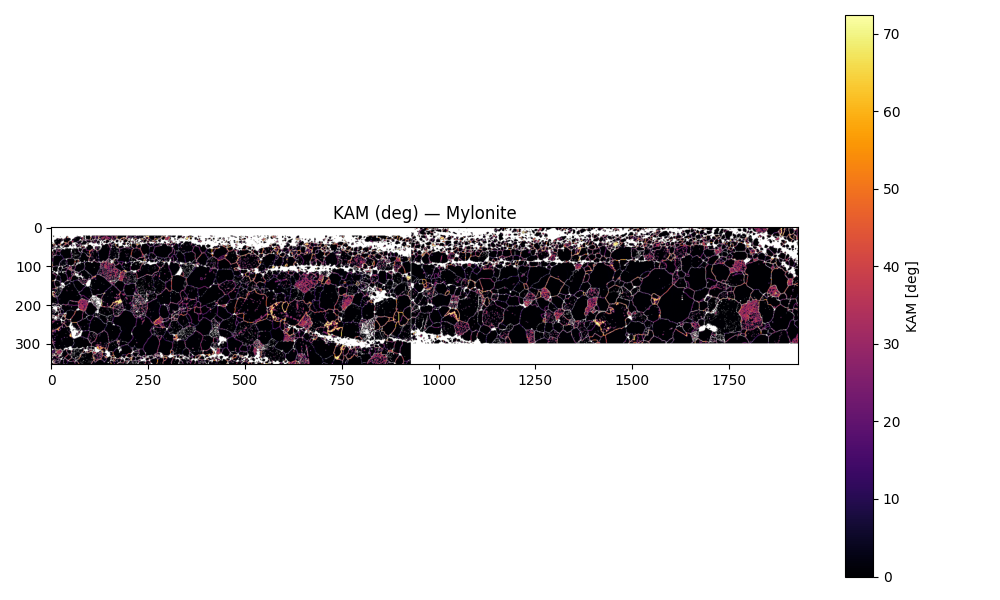


To run the existing tensor WTMM pipeline on KAM instead of Euler angles,
replace the Euler-gradient input in the WTMM cells with ebsd["kam"] (NaN-safe).


In [423]:
# --- KAM (Kernel Average Misorientation) on a 1-ring 8-neighbor kernel ---
# KAM is rotation-invariant: the global structural-frame rotation above has no
# effect on this scalar field. Unit: degrees. Stored in ebsd['kam'] for WTMM use.

def euler_to_quat(e1_deg, e2_deg, e3_deg):
    """Bunge ZXZ Euler angles (deg) -> unit quaternion (w, x, y, z)."""
    phi1 = np.deg2rad(e1_deg) * 0.5
    Phi  = np.deg2rad(e2_deg) * 0.5
    phi2 = np.deg2rad(e3_deg) * 0.5
    c1, s1 = np.cos(phi1), np.sin(phi1)
    cP, sP = np.cos(Phi),  np.sin(Phi)
    c2, s2 = np.cos(phi2), np.sin(phi2)
    w =  c1 * cP * c2 - s1 * cP * s2
    x =  c1 * sP * c2 + s1 * sP * s2
    y = -c1 * sP * s2 + s1 * sP * c2
    z =  c1 * cP * s2 + s1 * cP * c2
    return np.stack([w, x, y, z], axis=-1)

def kam_from_euler(e1, e2, e3, phase=None, kernel=1):
    """Compute KAM in degrees on an 8-connected (1-ring) neighborhood.
    
    phase : optional phase array; if provided, cross-phase neighbor pairs
            are excluded. Unindexed pixels (phase == 0) -> KAM set to NaN.
    Uses the naïve geodesic angle without crystal symmetry reduction; this
    is sufficient to localize strain gradients for WTMM purposes.
    """
    q = euler_to_quat(e1, e2, e3)             # (ny, nx, 4)
    ny, nx, _ = q.shape
    kam = np.zeros((ny, nx), dtype=np.float32)
    count = np.zeros((ny, nx), dtype=np.int32)
    shifts = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
    for dy, dx in shifts:
        ys = slice(max(0,dy),  ny+min(0,dy))
        xs = slice(max(0,dx),  nx+min(0,dx))
        yn = slice(max(0,-dy), ny+min(0,-dy))
        xn = slice(max(0,-dx), nx+min(0,-dx))
        dot = np.abs(np.sum(q[ys, xs] * q[yn, xn], axis=-1))
        dot = np.clip(dot, -1.0, 1.0)
        angle = np.rad2deg(2.0 * np.arccos(dot))
        if phase is not None:
            same = (phase[ys, xs] == phase[yn, xn]) & (phase[ys, xs] > 0)
            angle = np.where(same, angle, 0.0)
            kam[ys, xs] += angle
            count[ys, xs] += same.astype(np.int32)
        else:
            kam[ys, xs] += angle
            count[ys, xs] += 1
    with np.errstate(divide='ignore', invalid='ignore'):
        kam = np.where(count > 0, kam / count, np.nan)
    if phase is not None:
        kam = np.where(phase > 0, kam, np.nan)
    return kam

ebsd['kam'] = kam_from_euler(
    ebsd['euler1_struct'], ebsd['euler2_struct'], ebsd['euler3_struct'],
    phase=ebsd.get('phase'),
)
valid = np.isfinite(ebsd['kam'])
print(f'KAM computed: shape {ebsd["kam"].shape}, {valid.sum()/ebsd["kam"].size*100:.1f}% valid pixels')
if valid.any():
    print(f'  range {np.nanmin(ebsd["kam"]):.3f} – {np.nanmax(ebsd["kam"]):.3f} deg')
    print(f'  mean  {np.nanmean(ebsd["kam"]):.3f} deg   median {np.nanmedian(ebsd["kam"]):.3f} deg')

# Quick KAM preview
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
im = ax.imshow(ebsd['kam'], cmap='inferno', vmin=0, vmax=np.nanpercentile(ebsd['kam'], 99))
ax.set_title(f"KAM (deg) — {meta['name']}")
plt.colorbar(im, ax=ax, label='KAM [deg]')
plt.tight_layout(); plt.show()

print('\nTo run the existing tensor WTMM pipeline on KAM instead of Euler angles,')
print('replace the Euler-gradient input in the WTMM cells with ebsd["kam"] (NaN-safe).')


## Log-orientation field (Lie-algebra / so(3) representation)

Project the per-pixel orientation field q(x, y) ∈ SO(3) into the tangent space at a reference orientation q_ref, giving a clean **3-channel vector field** v(x, y) = log(q_ref⁻¹ q(x, y)) ∈ ℝ³ that is well-defined in a true vector space (so(3) ≅ ℝ³) with no gimbal-lock singularities, no 2π cycle jumps, and no crystal-symmetry multiplicity.

Per phase: the correct crystal point group is attached via orix, q_ref is found by iterated symmetry-aware Karcher mean of that phase's orientations, and each pixel is sym-reduced to the equivalent closest to q_ref before taking the log map.

**Within grains** the field is smooth (small |∇v|), **at grain boundaries** it jumps (large |∇v|). The spatial gradient tensor

$$\kappa_{ij}(x, y) \;=\; \partial_i v_j(x, y)$$

is (up to a sign convention) the **lattice curvature tensor** and therefore directly proportional to the **Nye geometrically-necessary dislocation density tensor** α. Running tensor WTMM on v(x, y) gives the multifractal spectrum D(h) of the GND density field — a physically meaningful characterization of dislocation content geometry that cannot be obtained from scalar WTMM on KAM.

Stored as `ebsd['log_orientation']` with shape `(ny, nx, 3)` and units of radians. Cross-phase and unindexed pixels are zero.


Computing log-orientation field for 1 phase(s)...
  phase 1 (Quartz-new, sym=32): 514826 px, θ median= 34.37°, θ p99= 91.34°, Karcher iters=5

--- FZ disorientation range check ---
⚠  phase 1 (Quartz-new      32    ): θ p99 =  91.34°  /  FZ max ≈ 104.50°  (ratio 0.87)
  ⚠  one or more phases exceed 80% of their FZ max — the log_orientation
      field will have π-boundary artifacts at some pixels of those phases.
      The tensor WTMM D(h) from those phases should be interpreted with care
      or analyzed per-phase with a phase-specific q_ref.

|∇v| distribution (deg/µm) across valid pixels:
  median : 0.3363
  p90    : 32.1225
  p99    : 61.2111
  max    : 203.7916

  Interpretation: median = inside-grain GND gradient; p99/max = grain boundaries.


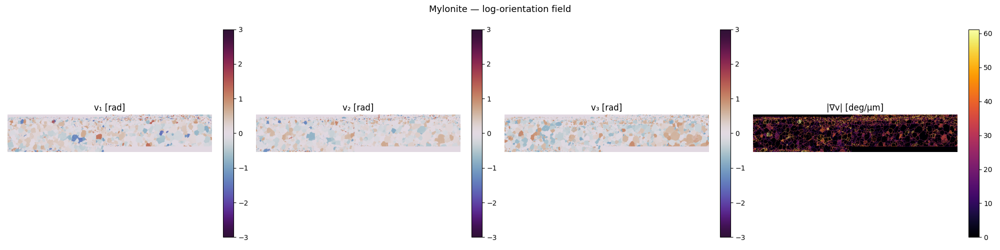

In [424]:
# --- Log-orientation (so(3)) field with per-phase symmetry via orix ---
from orix.quaternion import Orientation, Rotation
from orix.quaternion.symmetry import (
    C1, Ci, C2h, D2, D2h, D3, D3d, D6, D6h, Oh, O as SymO,
)

# Lookup from CTF phase name -> orix proper-rotation point group
PHASE_TO_SYMMETRY = {
    # Olivine / orthorhombic pyroxenes — mmm
    'Forsterite':    D2h,
    'Orthopyroxene': D2h,
    'Enstatite':     D2h,
    # Monoclinic pyroxenes / amphiboles — 2/m
    'Diopside':      C2h,
    'Augite':        C2h,
    'Clinopyroxene': C2h,
    'Tremolite':     C2h,
    'Hornblende':    C2h,
    'Actinolite':    C2h,
    # Cubic spinel — m-3m
    'Chromite':      Oh,
    'Spinel':        Oh,
    # Alpha-quartz (low T) — 32
    'Quartz-new':    D3,
    'Quartz':        D3,
    'Quartz Alpha':  D3,
    # Feldspars
    'Orthoclase':    C2h,   # 2/m
    'Sanidine':      C2h,
    'Microcline':    Ci,    # triclinic -1 (effectively C1 for rotations)
    'Albite':        Ci,
    'Plagioclase':   Ci,
    'Anorthite':     Ci,
    'K-Feldspar':    C2h,   # default to orthoclase/sanidine
    # Carbonates
    'Calcite':       D3d,   # -3m
    'Dolomite':      D3d,
}


def _quat_mul(a, b):
    """Vectorized quaternion product a * b. Broadcasts over leading dims."""
    aw, ax, ay, az = a[..., 0], a[..., 1], a[..., 2], a[..., 3]
    bw, bx, by, bz = b[..., 0], b[..., 1], b[..., 2], b[..., 3]
    return np.stack([
        aw * bw - ax * bx - ay * by - az * bz,
        aw * bx + ax * bw + ay * bz - az * by,
        aw * by - ax * bz + ay * bw + az * bx,
        aw * bz + ax * by - ay * bx + az * bw,
    ], axis=-1)


def _quat_conj(q):
    return np.stack([q[..., 0], -q[..., 1], -q[..., 2], -q[..., 3]], axis=-1)


def _sym_reduce_to_ref(q_pix, q_ref, sym_q):
    """For each pixel quaternion, pick the symmetry-equivalent minimizing the
    angle to q_ref. Returns rel = q_ref^{-1} * (q_pix * s_best) with w >= 0.
    """
    q_ref_inv = _quat_conj(q_ref)
    q_pix_sym = _quat_mul(q_pix[:, None, :], sym_q[None, :, :])  # (N, S, 4)
    rel_s = _quat_mul(q_ref_inv[None, None, :], q_pix_sym)
    signs = np.where(rel_s[..., 0] >= 0, 1.0, -1.0)
    rel_s = rel_s * signs[..., None]
    best_idx = np.argmax(rel_s[..., 0], axis=1)
    N = rel_s.shape[0]
    return rel_s[np.arange(N), best_idx]


def _sym_aware_karcher_mean(q_pix, sym_q, max_iter=5, tol_deg=0.05):
    """Iterated symmetry-aware Karcher mean via orientation-tensor dominant eigenvector.
    Converges in 1-3 iterations for CPO-clustered data.
    """
    N = q_pix.shape[0]
    q_init = q_pix * np.where(q_pix[:, 0:1] >= 0, 1.0, -1.0)
    T0 = (q_init.T @ q_init) / N
    _, v0 = np.linalg.eigh(T0)
    q_ref = v0[:, -1]
    if q_ref[0] < 0:
        q_ref = -q_ref
    for it in range(max_iter):
        rel = _sym_reduce_to_ref(q_pix, q_ref, sym_q)
        q_abs = _quat_mul(q_ref[None, :], rel)
        q_abs = q_abs * np.where(q_abs[:, 0:1] >= 0, 1.0, -1.0)
        T = (q_abs.T @ q_abs) / N
        _, v_eig = np.linalg.eigh(T)
        q_next = v_eig[:, -1]
        if q_next[0] < 0:
            q_next = -q_next
        delta_deg = np.rad2deg(2.0 * np.arccos(min(abs(float(q_ref @ q_next)), 1.0)))
        q_ref = q_next
        if delta_deg < tol_deg:
            break
    return q_ref, it + 1


def _log_orientation_for_phase(e1, e2, e3, phase_mask, symmetry):
    """Per-phase log-orientation field: v(x) = log(q_ref^{-1} q(x)).

    Returns (v_field (ny, nx, 3), q_ref_quat (4,), stats dict).
    Pixels outside phase_mask are zero.
    """
    ny, nx = phase_mask.shape
    out = np.zeros((ny, nx, 3), dtype=np.float32)
    if phase_mask.sum() == 0:
        return out, np.array([1.0, 0.0, 0.0, 0.0]), {'n_pixels': 0}

    yy, xx = np.where(phase_mask)
    eul_rad = np.deg2rad(np.stack([
        e1[phase_mask].astype(np.float64),
        e2[phase_mask].astype(np.float64),
        e3[phase_mask].astype(np.float64),
    ], axis=1))
    O = Orientation.from_euler(eul_rad, symmetry=symmetry)
    q_pix = O.data
    sym_q = symmetry.data

    q_ref_quat, n_iter = _sym_aware_karcher_mean(q_pix, sym_q)
    rel_best = _sym_reduce_to_ref(q_pix, q_ref_quat, sym_q)

    # Log map: axis * angle
    w = np.clip(rel_best[:, 0], -1.0, 1.0)
    theta = 2.0 * np.arccos(w)
    sin_half = np.sqrt(np.maximum(1.0 - w * w, 0.0))
    small = sin_half < 1e-8
    safe = np.where(small, 1.0, sin_half)
    axis = rel_best[:, 1:4] / safe[:, None]
    axis[small] = 0.0
    omega = theta[:, None] * axis
    # For tiny theta, use the more accurate Taylor approximation
    omega[small] = 2.0 * rel_best[small, 1:4]

    out[yy, xx, :] = omega.astype(np.float32)
    stats = {
        'n_pixels': int(phase_mask.sum()),
        'karcher_iterations': int(n_iter),
        'theta_median_deg': float(np.rad2deg(np.median(theta))),
        'theta_p90_deg':    float(np.rad2deg(np.percentile(theta, 90))),
        'theta_p99_deg':    float(np.rad2deg(np.percentile(theta, 99))),
    }
    return out, q_ref_quat, stats


def phase_name_from_meta(meta, phase_id):
    info = meta.get('phases', {}).get(int(phase_id))
    if info and len(info) >= 3:
        return info[2]
    return f'phase_{phase_id}'


def _lookup_symmetry(phase_name_str):
    if phase_name_str in PHASE_TO_SYMMETRY:
        return PHASE_TO_SYMMETRY[phase_name_str]
    n_lower = phase_name_str.lower()
    for key, sym in PHASE_TO_SYMMETRY.items():
        if key.lower() in n_lower or n_lower in key.lower():
            return sym
    return C1  # safe fallback: no symmetry reduction


# --- Compute the full map ---
ny, nx = ebsd['euler1_struct'].shape
log_field = np.zeros((ny, nx, 3), dtype=np.float32)
phase_info = {}
phase_ids = [int(p) for p in np.unique(ebsd['phase']) if int(p) > 0] if ebsd.get('phase') is not None else []

print(f"Computing log-orientation field for {len(phase_ids)} phase(s)...")
for pid in phase_ids:
    mask = (ebsd['phase'] == pid)
    pname = phase_name_from_meta(meta, pid)
    sym = _lookup_symmetry(pname)
    sub, q_ref, stats = _log_orientation_for_phase(
        ebsd['euler1_struct'], ebsd['euler2_struct'], ebsd['euler3_struct'],
        mask, sym,
    )
    log_field += sub
    phase_info[pid] = {'name': pname, 'symmetry': sym.name, 'q_ref_quat': q_ref, **stats}
    print(f"  phase {pid} ({pname}, sym={sym.name}): {stats['n_pixels']:6d} px, "
          f"θ median={stats['theta_median_deg']:6.2f}°, "
          f"θ p99={stats['theta_p99_deg']:6.2f}°, "
          f"Karcher iters={stats['karcher_iterations']}")

ebsd['log_orientation'] = log_field
ebsd['log_orientation_phase_info'] = phase_info

# --- Fundamental-zone sanity check on disorientation range ---
# The log map log(q_ref^{-1} q) is ill-defined at the π boundary of the
# disorientation fundamental zone (FZ). For phases whose θ_p99 approaches
# the FZ maximum, the WTMM of the log_orientation field may see spurious
# gradients at symmetry-equivalent pixel pairs near the boundary. This
# block flags affected phases so you know which D(h) results to treat
# skeptically. Threshold = 80% of the rotation FZ max angle.
_FZ_MAX_BY_SYM = {
    '1':     180.0,  # C1 triclinic, no symmetry
    '-1':    180.0,  # Ci — proper rotation only (effectively C1)
    '2/m':   180.0,  # C2h monoclinic
    'mmm':   120.0,  # D2h orthorhombic (proper D2 rotations)
    '222':   120.0,  # D2
    '32':    104.5,  # D3 trigonal
    '3m':    104.5,  # C3v
    '-3m':   104.5,  # D3d
    '622':    93.8,  # D6
    '6mm':    93.8,  # C6v
    '6/mmm':  93.8,  # D6h
    '422':    93.8,  # D4
    '4mm':    93.8,  # C4v
    '4/mmm':  93.8,  # D4h
    'm-3':    62.8,  # Th
    '432':    62.8,  # O
    'm-3m':   62.8,  # Oh (cubic)
}
print('\n--- FZ disorientation range check ---')
_any_warn = False
for _pid, _info in phase_info.items():
    _sym_name = _info['symmetry']
    _fz_max = _FZ_MAX_BY_SYM.get(_sym_name, 180.0)
    _p99 = _info['theta_p99_deg']
    _ratio = _p99 / _fz_max
    _flag = '⚠  ' if _ratio > 0.80 else '   '
    print(f'{_flag}phase {_pid} ({_info["name"]:15s} {_sym_name:6s}): '
          f'θ p99 = {_p99:6.2f}°  /  FZ max ≈ {_fz_max:6.2f}°  '
          f'(ratio {_ratio:4.2f})')
    if _ratio > 0.80:
        _any_warn = True
if _any_warn:
    print('  ⚠  one or more phases exceed 80% of their FZ max — the log_orientation')
    print('      field will have π-boundary artifacts at some pixels of those phases.')
    print('      The tensor WTMM D(h) from those phases should be interpreted with care')
    print('      or analyzed per-phase with a phase-specific q_ref.')
else:
    print('  ✓  all phases safely below 80% of FZ max — log_orientation is clean.')

# --- Diagnostic preview ---
# Spatial gradient magnitude of v (Frobenius of the 2x3 tensor ∇v)
dx_v = np.gradient(log_field, meta['xstep'], axis=1)
dy_v = np.gradient(log_field, meta['ystep'], axis=0)
grad_mag = np.sqrt(np.sum(dx_v**2 + dy_v**2, axis=-1))  # rad/µm
grad_mag_deg = np.rad2deg(grad_mag)
valid = ebsd['phase'] > 0

print(f"\n|∇v| distribution (deg/µm) across valid pixels:")
print(f"  median : {np.median(grad_mag_deg[valid]):.4f}")
print(f"  p90    : {np.percentile(grad_mag_deg[valid], 90):.4f}")
print(f"  p99    : {np.percentile(grad_mag_deg[valid], 99):.4f}")
print(f"  max    : {grad_mag_deg[valid].max():.4f}")
print("\n  Interpretation: median = inside-grain GND gradient; p99/max = grain boundaries.")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
im0 = axes[0].imshow(log_field[..., 0], cmap='twilight_shifted', vmin=-3, vmax=3)
axes[0].set_title('v₁ [rad]')
plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(log_field[..., 1], cmap='twilight_shifted', vmin=-3, vmax=3)
axes[1].set_title('v₂ [rad]')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
im2 = axes[2].imshow(log_field[..., 2], cmap='twilight_shifted', vmin=-3, vmax=3)
axes[2].set_title('v₃ [rad]')
plt.colorbar(im2, ax=axes[2], fraction=0.046)
vmax = max(np.percentile(grad_mag_deg[valid], 99), 1e-3)
im3 = axes[3].imshow(grad_mag_deg, cmap='inferno', vmin=0, vmax=vmax)
axes[3].set_title('|∇v| [deg/µm]')
plt.colorbar(im3, ax=axes[3], fraction=0.046)
for ax in axes:
    ax.set_axis_off()
plt.suptitle(f"{meta['name']} — log-orientation field", fontsize=13)
plt.tight_layout()
plt.show()


Computing pairwise Nye tensor...
  done in 0.67s, shape=(353, 1929, 2, 3)

--- Per-phase Nye tensor diagnostics ---
  phase 1 (Quartz-new      32    ): n_pairs=  484348+  482200  max pair-θ=103.30°

|N|_F Frobenius (deg/µm) over valid pixels:
  median :    0.4804
  p90    :    5.2473
  p99    :   84.7023
  max    :  142.7847
  (median ≈ within-grain GND density; p99/max ≈ grain boundaries)


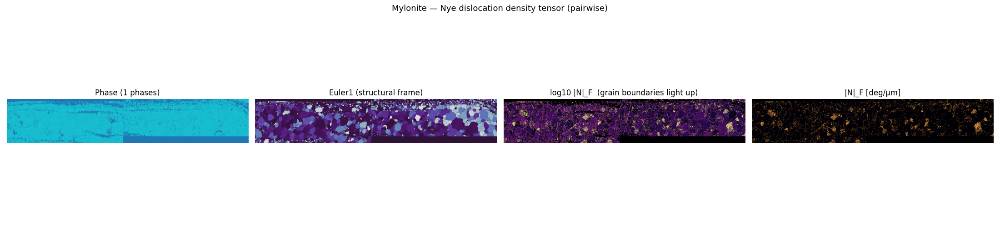

In [425]:
# --- Pairwise Nye tensor: avoids the log-map π-boundary issue ---
# For each pixel and each spatial direction, we compute the log map of the
# LOCAL neighbor disorientation, not log(q_ref^{-1} q) with a global q_ref.
# Advantages:
#   - Neighbor disorientations are always well inside the rotation FZ
#   - Per-pair symmetry reduction handles weak-CPO phases correctly
#   - The resulting tensor IS the Nye GND density tensor (up to a sign)
#
# Output stored as ebsd['nye_tensor'] with shape (ny, nx, 2, 3):
#   N[y, x, 0, :] = ∂v/∂x  (Lie-algebra vector, rad/µm)
#   N[y, x, 1, :] = ∂v/∂y
# Cross-phase pairs and edges are zero.

from scipy.ndimage import gaussian_filter as _gaussian_filter  # for later smoothing

# Extend phase symmetry to cover common rock-forming micas
PHASE_TO_SYMMETRY.update({
    'Biotite':    C2h,   # 2/m monoclinic mica
    'Muscovite':  C2h,
    'Phlogopite': C2h,
})

def _nye_euler_to_quat(e1_deg, e2_deg, e3_deg):
    phi1 = np.deg2rad(e1_deg) * 0.5
    Phi  = np.deg2rad(e2_deg) * 0.5
    phi2 = np.deg2rad(e3_deg) * 0.5
    c1, s1 = np.cos(phi1), np.sin(phi1)
    cP, sP = np.cos(Phi),  np.sin(Phi)
    c2, s2 = np.cos(phi2), np.sin(phi2)
    return np.stack([
        c1 * cP * c2 - s1 * cP * s2,
        c1 * sP * c2 + s1 * sP * s2,
       -c1 * sP * s2 + s1 * sP * c2,
        c1 * cP * s2 + s1 * cP * c2,
    ], axis=-1)

def _nye_sym_reduce_pair(rel, sym_q):
    rel_s = _quat_mul(rel[..., None, :], sym_q)
    signs = np.where(rel_s[..., 0] >= 0, 1.0, -1.0)
    rel_s = rel_s * signs[..., None]
    best_idx = np.argmax(rel_s[..., 0], axis=-1)
    expand_idx = np.expand_dims(best_idx, axis=-1)
    expand_idx = np.broadcast_to(expand_idx, (*expand_idx.shape[:-1], 4))
    return np.take_along_axis(rel_s, expand_idx[..., None, :], axis=-2).squeeze(-2)

def _nye_log_map(rel):
    w = np.clip(rel[..., 0], -1.0, 1.0)
    theta = 2.0 * np.arccos(w)
    sin_half = np.sqrt(np.maximum(1 - w * w, 0.0))
    small = sin_half < 1e-8
    safe = np.where(small, 1.0, sin_half)
    axis = rel[..., 1:4] / safe[..., None]
    omega = theta[..., None] * axis
    omega_small = 2.0 * rel[..., 1:4]
    return np.where(small[..., None], omega_small, omega)

def compute_nye_tensor(ebsd):
    """Pairwise Nye tensor. Returns (N, info)."""
    e1 = ebsd['euler1_struct']  # use structural-frame Euler if available
    e2 = ebsd['euler2_struct']
    e3 = ebsd['euler3_struct']
    phase = ebsd['phase']
    m = ebsd['meta']
    xstep = float(m['xstep'])
    ystep = float(m['ystep'])
    ny, nx = e1.shape

    N = np.zeros((ny, nx, 2, 3), dtype=np.float32)
    q_field = _nye_euler_to_quat(e1, e2, e3).astype(np.float64)

    # Collect phases and their symmetry groups
    phase_ids = [int(p) for p in np.unique(phase) if int(p) > 0]
    sym_map = {}
    for pid in phase_ids:
        pname = phase_name_from_meta(m, pid)
        sym_map[pid] = _lookup_symmetry(pname)

    info = {}
    for dir_idx, (dy, dx, step) in enumerate([(0, 1, xstep), (1, 0, ystep)]):
        for pid, sym_obj in sym_map.items():
            sym_q = sym_obj.data
            ya = slice(0, ny - dy); xa = slice(0, nx - dx)
            yb = slice(dy, ny);     xb = slice(dx, nx)
            same_phase = (phase[ya, xa] == pid) & (phase[yb, xb] == pid)
            if not same_phase.any():
                continue

            qa = q_field[ya, xa]
            qb = q_field[yb, xb]
            rel = _quat_mul(_quat_conj(qa), qb)
            rel_reduced = _nye_sym_reduce_pair(rel, sym_q)
            omega = _nye_log_map(rel_reduced) / step

            # Only write where same-phase
            out_slice = N[ya, xa, dir_idx, :]
            mask3 = same_phase[..., None]
            N[ya, xa, dir_idx, :] = np.where(mask3, omega.astype(np.float32), out_slice)

            if pid not in info:
                info[pid] = {
                    'name': phase_name_from_meta(m, pid),
                    'symmetry': sym_obj.name,
                    'n_pairs_x': 0, 'n_pairs_y': 0,
                    'max_theta_deg': 0.0,
                }
            w_cl = np.clip(rel_reduced[..., 0], -1, 1)
            theta_deg = 2 * np.rad2deg(np.arccos(w_cl))
            if same_phase.any():
                info[pid]['max_theta_deg'] = max(
                    info[pid]['max_theta_deg'],
                    float(theta_deg[same_phase].max())
                )
            info[pid][f'n_pairs_{"xy"[dir_idx]}'] = int(same_phase.sum())

    return N, info

# Optional Fourier-domain fractional integration (Arneodo et al.) — not used
# by default. Set FRACINT_ALPHA > 0 in the tensor WTMM switch cell below to
# shift all Hölder exponents by +α before analysis. α = 1 on the Nye tensor
# recovers the smoothed log-orientation field; α = 0.5 gives cleaner τ(q) tails.
def fracint_2d(field, alpha, pad=None):
    """Apply α-order fractional integration via the Fourier domain.

    F'(k) = F(k) / |k|^α, DC preserved. Mitigates edge artifacts from the
    heavy-tailed `|r|^(-(2-α))` real-space kernel via three stacked fixes:

    1. **Linear detrend**: fit and subtract a plane (mean + linear x/y trend)
       before filtering, add it back after. Fractional integration amplifies
       both the constant offset AND any linear gradient in the input — both
       would manifest as border halos. Removing the plane first confines the
       filter's effect to the non-linear residual.
    2. **Large reflect pad**: pad = max(ny, nx) // 2 (half the image). The
       kernel decays as r^(-(2-α)) which for α=0.5 is r^(-1.5) — still has
       meaningful mass well outside a 32-pixel neighborhood. A half-image
       pad pushes the wraparound beyond the region where the kernel matters.
    3. **DC preservation** of the padded array.

    Parameters
    ----------
    field : (ny, nx) real array
    alpha : float — integration order (0 = passthrough)
    pad   : int or None — reflect-pad width. Default = max(ny, nx) // 2.
    """
    if alpha == 0:
        return field
    ny, nx = field.shape
    if pad is None:
        pad = max(ny, nx) // 2

    # Detrend: fit mean + linear x + linear y, subtract, filter residual,
    # add the plane back afterward. Uses float64 for the lstsq to avoid
    # float32 rounding pollution in the trend estimate.
    yy_idx, xx_idx = np.mgrid[:ny, :nx].astype(np.float64)
    A = np.column_stack([np.ones(ny * nx),
                          xx_idx.ravel(),
                          yy_idx.ravel()])
    # Fit only over finite (non-NaN) pixels
    finite = np.isfinite(field.ravel())
    if finite.any():
        coef, *_ = np.linalg.lstsq(A[finite],
                                    field.ravel()[finite].astype(np.float64),
                                    rcond=None)
    else:
        coef = np.zeros(3)
    trend = (coef[0] + coef[1] * xx_idx + coef[2] * yy_idx).astype(field.dtype)
    residual = np.where(np.isfinite(field), field - trend, 0).astype(field.dtype)

    # Reflect pad the residual
    padded = np.pad(residual, pad, mode='reflect').astype(field.dtype)
    ny_p, nx_p = padded.shape
    kx = np.fft.fftfreq(nx_p) * nx_p
    ky = np.fft.fftfreq(ny_p) * ny_p
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX * KX + KY * KY)
    K[0, 0] = 1.0
    F = np.fft.fft2(padded)
    F_filt = F / (K ** alpha)
    F_filt[0, 0] = F[0, 0]
    result_padded = np.real(np.fft.ifft2(F_filt))
    result = result_padded[pad:pad + ny, pad:pad + nx]

    return (result + trend).astype(field.dtype)

# --- Compute the field ---
import time as _t_nye
_t0 = _t_nye.time()
print("Computing pairwise Nye tensor...")
nye, nye_info = compute_nye_tensor(ebsd)
print(f'  done in {_t_nye.time()-_t0:.2f}s, shape={nye.shape}')
ebsd['nye_tensor'] = nye
ebsd['nye_tensor_info'] = nye_info

print('\n--- Per-phase Nye tensor diagnostics ---')
for pid, d in nye_info.items():
    print(f'  phase {pid} ({d["name"]:15s} {d["symmetry"]:6s}): '
          f'n_pairs={d["n_pairs_x"]:8d}+{d["n_pairs_y"]:8d}  '
          f'max pair-θ={d["max_theta_deg"]:6.2f}°')

frob = np.sqrt(np.sum(nye ** 2, axis=(-1, -2)))
frob_deg = np.rad2deg(frob)
valid = ebsd['phase'] > 0
print(f'\n|N|_F Frobenius (deg/µm) over valid pixels:')
print(f'  median : {np.median(frob_deg[valid]):9.4f}')
print(f'  p90    : {np.percentile(frob_deg[valid], 90):9.4f}')
print(f'  p99    : {np.percentile(frob_deg[valid], 99):9.4f}')
print(f'  max    : {frob_deg[valid].max():9.4f}')
print('  (median ≈ within-grain GND density; p99/max ≈ grain boundaries)')

# Diagnostic plot: phase + Euler1 + log|N|_F + linear|N|_F
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(ebsd['phase'], cmap='tab10')
axes[0].set_title(f'Phase ({meta["n_phases"]} phases)')
axes[1].imshow(ebsd['euler1_struct'], cmap='twilight_shifted', vmin=0, vmax=360)
axes[1].set_title('Euler1 (structural frame)')
log_frob = np.log10(frob_deg + 1e-3)
vmin = np.percentile(log_frob[valid], 5) if valid.any() else -3
vmax = np.percentile(log_frob[valid], 99) if valid.any() else 2
axes[2].imshow(log_frob, cmap='inferno', vmin=vmin, vmax=vmax)
axes[2].set_title('log10 |N|_F  (grain boundaries light up)')
lin_vmax = np.percentile(frob_deg[valid], 99) if valid.any() else 1
axes[3].imshow(frob_deg, cmap='inferno', vmin=0, vmax=lin_vmax)
axes[3].set_title(f'|N|_F [deg/µm]')
for ax in axes:
    ax.set_axis_off()
plt.suptitle(f'{meta["name"]} — Nye dislocation density tensor (pairwise)', fontsize=13)
plt.tight_layout()
plt.show()


## Metadata & Phase Table

In [426]:
print(f"Dataset: {meta['name']}")
print(f"Grid:    {meta['xcells']} x {meta['ycells']}")
print(f"Step:    {meta['xstep']} x {meta['ystep']} µm")
print(f"Size:    {meta['xcells']*meta['xstep']:.1f} x {meta['ycells']*meta['ystep']:.1f} µm")
print(f"Phases:  {meta['n_phases']}")
print()

if 'phases' in meta:
    for pid, info in meta['phases'].items():
        # info[0] = lattice params, info[1] = angles, info[2] = name (typically)
        name = info[2] if len(info) > 2 else '?'
        lattice = info[0] if len(info) > 0 else '?'
        print(f"  Phase {pid}: {name}  ({lattice})")

# Count indexed vs unindexed
if ebsd['phase'] is not None:
    indexed = np.count_nonzero(ebsd['phase'])
    total = ebsd['phase'].size
    print(f"\nIndexed: {indexed}/{total} ({100*indexed/total:.1f}%)")

Dataset: Mylonite
Grid:    1929 x 353
Step:    1.0 x 1.0 µm
Size:    1929.0 x 353.0 µm
Phases:  1

  Phase 1: Quartz-new  (4.9130;4.9130;5.5040)

Indexed: 514826/680937 (75.6%)


## Visualize All Fields

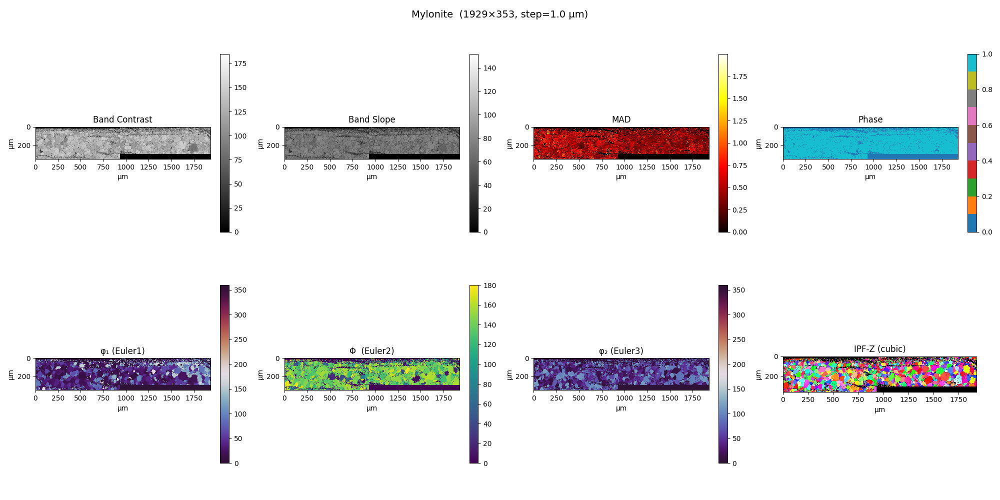

In [427]:
nx, ny = meta['xcells'], meta['ycells']
extent = [0, nx * meta['xstep'], ny * meta['ystep'], 0]  # µm, origin top-left

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(f"{meta['name']}  ({nx}×{ny}, step={meta['xstep']} µm)", fontsize=14)

# twilight_shifted is cyclic and perceptually uniform — correct for periodic angles
# viridis for Φ (0–180°, not periodic)
fields = [
    ('bc',     'Band Contrast',    'gray',              None),
    ('bs',     'Band Slope',       'gray',              None),
    ('mad',    'MAD',              'hot',               None),
    ('phase',  'Phase',            'tab10',             None),
    ('euler1', 'φ₁ (Euler1)',      'twilight_shifted',  (0, 360)),
    ('euler2', 'Φ  (Euler2)',      'viridis',           (0, 180)),
    ('euler3', 'φ₂ (Euler3)',      'twilight_shifted',  (0, 360)),
]

for ax, (key, title, cmap, vlim) in zip(axes.flat, fields):
    arr = ebsd[key]
    if arr is None:
        ax.set_visible(False)
        continue
    kw = {'extent': extent, 'cmap': cmap, 'interpolation': 'nearest'}
    if vlim:
        kw['vmin'], kw['vmax'] = vlim
    im = ax.imshow(arr, **kw)
    ax.set_title(title)
    ax.set_xlabel('µm')
    ax.set_ylabel('µm')
    plt.colorbar(im, ax=ax, fraction=0.046)

# Proper IPF coloring in the last panel
ax = axes.flat[7]
if ebsd['euler1'] is not None:
    ipf_rgb = ipf_color_cubic(ebsd['euler1'], ebsd['euler2'], ebsd['euler3'],
                              sample_dir='Z')
    # Black out unindexed pixels
    if ebsd['phase'] is not None:
        ipf_rgb[ebsd['phase'] == 0] = 0
    ax.imshow(ipf_rgb, extent=extent, interpolation='nearest')
    ax.set_title('IPF-Z (cubic)')
    ax.set_xlabel('µm')
    ax.set_ylabel('µm')
else:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Histograms

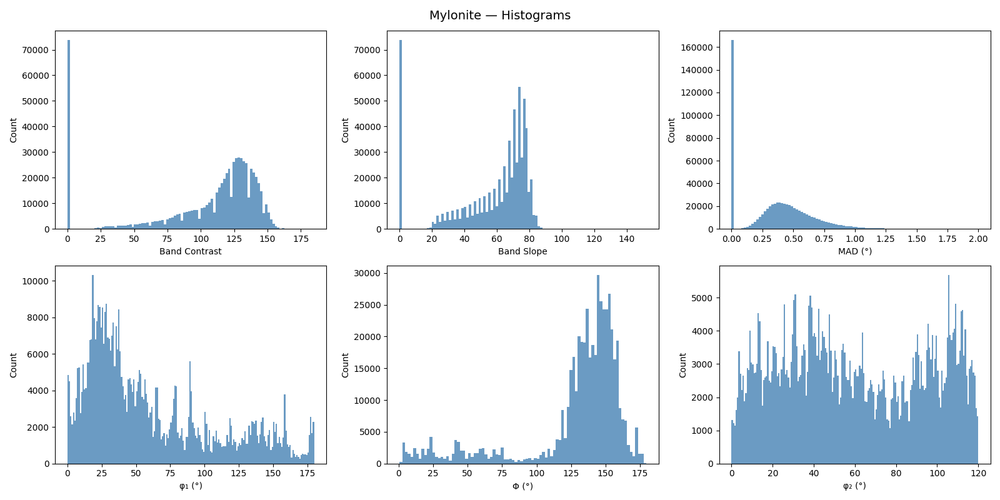

In [428]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f"{meta['name']} — Histograms", fontsize=14)

# Only indexed pixels for Euler histograms
indexed_mask = ebsd['phase'].ravel() > 0 if ebsd['phase'] is not None else np.ones(ny*nx, dtype=bool)

hist_fields = [
    ('bc',     'Band Contrast',  100, None),
    ('bs',     'Band Slope',     100, None),
    ('mad',    'MAD (°)',        100, None),
    ('euler1', 'φ₁ (°)',         180, indexed_mask),
    ('euler2', 'Φ (°)',           90, indexed_mask),
    ('euler3', 'φ₂ (°)',         180, indexed_mask),
]

for ax, (key, label, nbins, mask) in zip(axes.flat, hist_fields):
    arr = ebsd[key]
    if arr is None:
        ax.set_visible(False)
        continue
    vals = arr.ravel()
    if mask is not None:
        vals = vals[mask]
    ax.hist(vals, bins=nbins, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## IPF Maps (X, Y, Z) + Color Key

Inverse Pole Figure coloring for all three sample directions. The color key triangle
shows the cubic fundamental zone: **[001]=Red, [011]=Green, [111]=Blue**.

Note: this assumes cubic symmetry — for hexagonal/trigonal phases the fundamental zone
is different (would need `orix` for full generality).

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9229627e-16..1.0].


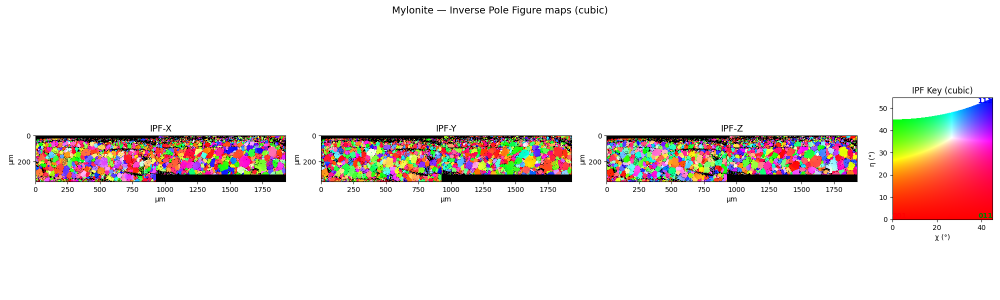

In [429]:
fig = plt.figure(figsize=(20, 6))

# 3 IPF maps + 1 color key
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.4])

unindexed_mask = ebsd['phase'] == 0 if ebsd['phase'] is not None else None

for i, direction in enumerate(['X', 'Y', 'Z']):
    ax = fig.add_subplot(gs[0, i])
    rgb = ipf_color_cubic(ebsd['euler1'], ebsd['euler2'], ebsd['euler3'],
                          sample_dir=direction)
    if unindexed_mask is not None:
        rgb[unindexed_mask] = 0
    ax.imshow(rgb, extent=extent, interpolation='nearest')
    ax.set_title(f'IPF-{direction}', fontsize=13)
    ax.set_xlabel('µm')
    ax.set_ylabel('µm')

# Color key
ax_key = fig.add_subplot(gs[0, 3])
ipf_color_key_fast(ax_key)

plt.suptitle(f"{meta['name']} — Inverse Pole Figure maps (cubic)", fontsize=14)
plt.tight_layout()
plt.show()

## Phase Map (Color-Coded)

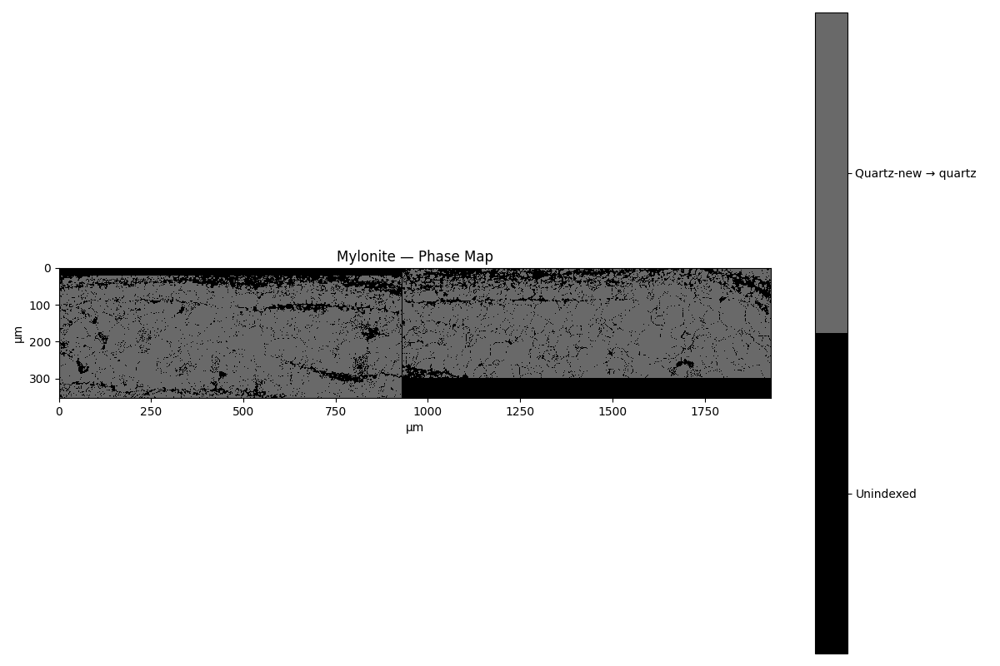

In [430]:
# --- Phase map with mineral-specific colors ---
#
# PHASE_COLOR_LOOKUP maps mineral names (case-insensitive) to a color.  Because
# different datasets assign different phase IDs to the same mineral, lookup is
# done by the name string stored in meta['phases'][pid] rather than by ID.
# Add more entries here as you encounter new minerals in your datasets.

from matplotlib.colors import ListedColormap, to_rgb as _to_rgb

PHASE_COLOR_LOOKUP = {
    'gold':       '#FFD700',   # gold → gold
    'chlorite':   'green',
    'trollite':   'purple',    # common misspelling
    'troilite':   'purple',    # correct FeS mineral name
    'pyrite':     'red',
    'calcite':    'tan',
    'quartz':     'dimgray',   # smokey grey
    'phlogopite': 'hotpink',
    'albite':     'lightblue',
}
UNINDEXED_COLOR      = 'black'
UNKNOWN_PHASE_COLOR  = '#888888'   # fallback for minerals not in the lookup


def _resolve_phase_color(name, lookup=None):
    """Match a CTF phase name against PHASE_COLOR_LOOKUP with fallback:
       1. Exact case-insensitive match on the stripped name.
       2. Any lookup key appearing as a whole word in the name
          (handles 'Calcite, magnesian', 'Low albite', 'Troilite 2H',
           'Quartz low', 'Quartz-new', 'Muscovite-2M1', etc.).
    Returns (color_name, matched_key) or (None, None) if no match.

    No substring fallback: keeps 'Chalcopyrite' from matching 'pyrite'.
    If you want a substring hit, add the full mineral name as an explicit
    alias entry in PHASE_COLOR_LOOKUP.
    """
    import re as _re
    if lookup is None:
        lookup = PHASE_COLOR_LOOKUP
    key = name.strip().lower()
    if key in lookup:
        return lookup[key], key
    tokens = set(_re.findall(r'[a-z]+', key))
    for lk in lookup:
        if lk in tokens:
            return lookup[lk], lk
    return None, None

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

phase_map = ebsd['phase']
if phase_map is not None:
    n_ph = meta['n_phases']

    # Build the ListedColormap and tick labels from the dataset's phase table
    colors = [_to_rgb(UNINDEXED_COLOR)]   # index 0 = unindexed
    tick_labels = ['Unindexed']
    for pid in range(1, n_ph + 1):
        if pid in meta.get('phases', {}):
            info = meta['phases'][pid]
            name = info[2] if len(info) > 2 else f'Phase {pid}'
        else:
            name = f'Phase {pid}'
        color_name, matched_key = _resolve_phase_color(name)
        color = color_name if color_name is not None else UNKNOWN_PHASE_COLOR
        colors.append(_to_rgb(color))
        # Tag unknowns (and variant matches) so you can see what's going on
        if color_name is None:
            label = f'{name} (unmapped)'
        elif matched_key != name.strip().lower():
            label = f'{name} → {matched_key}'
        else:
            label = name
        tick_labels.append(label)

    cmap = ListedColormap(colors)

    im = ax.imshow(phase_map, extent=extent, cmap=cmap,
                   vmin=-0.5, vmax=n_ph + 0.5, interpolation='nearest')
    cbar = plt.colorbar(im, ax=ax, ticks=range(n_ph + 1))
    cbar.ax.set_yticklabels(tick_labels)

    ax.set_title(f"{meta['name']} — Phase Map")
    ax.set_xlabel('µm')
    ax.set_ylabel('µm')

plt.tight_layout()
plt.show()


## Band Contrast with Grain Boundary Overlay

BC is the most natural scalar field for standard 2D WTMM — grain boundaries show up as low-BC ridges.

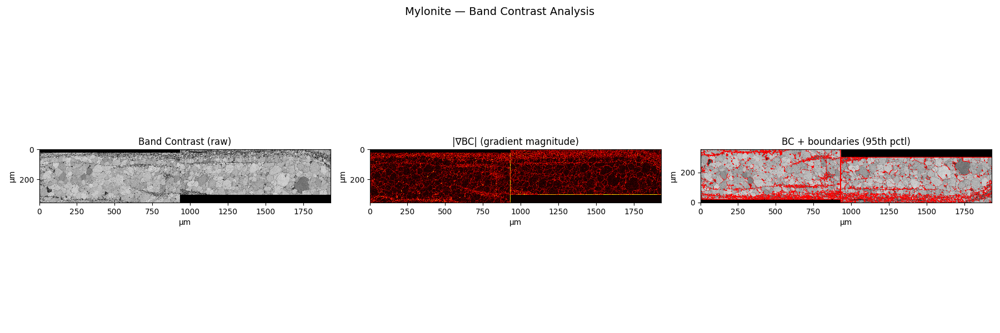

In [431]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

bc = ebsd['bc'].astype(np.float32)

# Raw BC
axes[0].imshow(bc, extent=extent, cmap='gray', interpolation='nearest')
axes[0].set_title('Band Contrast (raw)')

# Spatial gradients (finite difference) — highlights grain boundaries
dbc_dx = np.gradient(bc, axis=1)
dbc_dy = np.gradient(bc, axis=0)
grad_mag = np.sqrt(dbc_dx**2 + dbc_dy**2)

axes[1].imshow(grad_mag, extent=extent, cmap='hot', interpolation='nearest')
axes[1].set_title('|∇BC| (gradient magnitude)')

# Threshold for grain boundary overlay
threshold = np.percentile(grad_mag, 95)
axes[2].imshow(bc, extent=extent, cmap='gray', interpolation='nearest')
axes[2].contour(grad_mag, levels=[threshold], colors='red', linewidths=0.5,
                extent=[0, nx*meta['xstep'], 0, ny*meta['ystep']])
axes[2].set_title(f'BC + boundaries (95th pctl)')
axes[2].invert_yaxis()

for ax in axes:
    ax.set_xlabel('µm')
    ax.set_ylabel('µm')

plt.suptitle(f"{meta['name']} — Band Contrast Analysis", fontsize=14)
plt.tight_layout()
plt.show()

## Euler Angle Spatial Gradients

Preview of the 3×2 Jacobian structure: each Euler angle has dx, dy derivatives → 6 gradient images.
The tensor SVD of this 3×2 Jacobian at each pixel gives σ_max and σ_min — same as the InSAR 3-component approach.

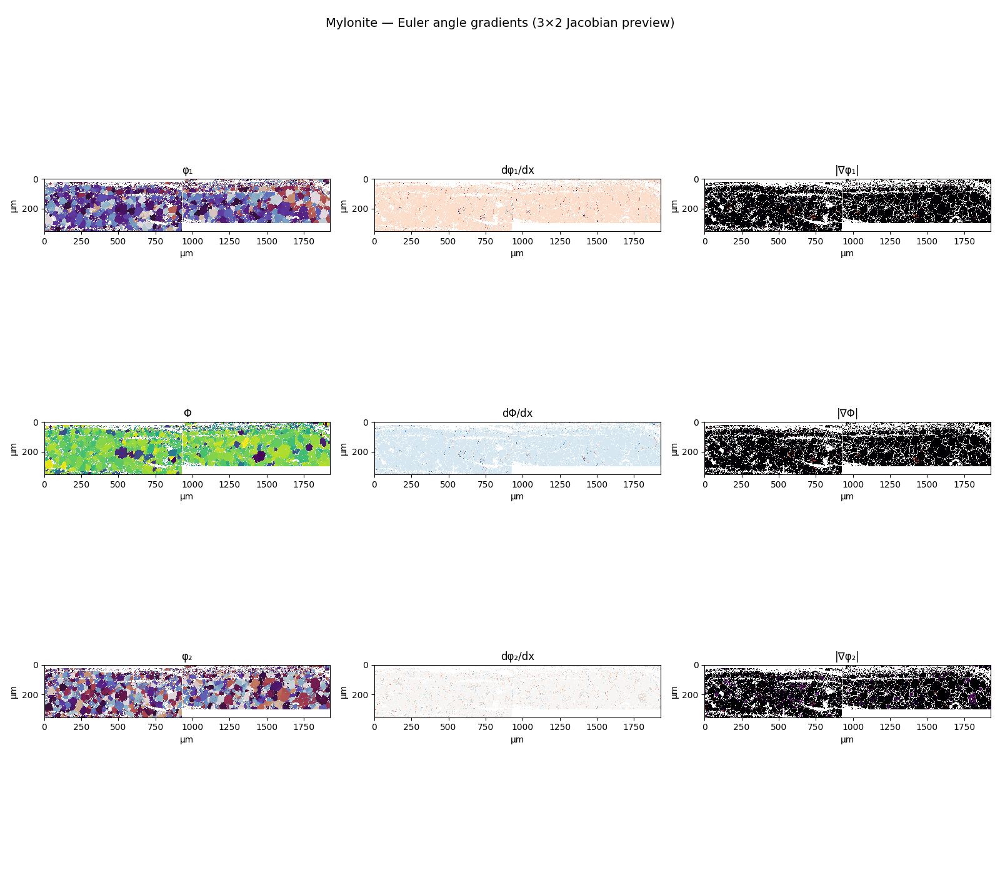

In [432]:
e1 = ebsd['euler1'].astype(np.float32)
e2 = ebsd['euler2'].astype(np.float32)
e3 = ebsd['euler3'].astype(np.float32)

# Mask unindexed pixels with NaN for cleaner gradients
if ebsd['phase'] is not None:
    unindexed = ebsd['phase'] == 0
    e1[unindexed] = np.nan
    e2[unindexed] = np.nan
    e3[unindexed] = np.nan

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
euler_names = ['φ₁', 'Φ', 'φ₂']
euler_arrays = [e1, e2, e3]
# Cyclic for periodic angles, sequential for Φ
euler_cmaps = ['twilight_shifted', 'viridis', 'twilight_shifted']

for row, (name, arr, cmap) in enumerate(zip(euler_names, euler_arrays, euler_cmaps)):
    # Raw field
    axes[row, 0].imshow(arr, extent=extent, cmap=cmap, interpolation='nearest')
    axes[row, 0].set_title(f'{name}')

    # dx, dy
    dx = np.gradient(arr, meta['xstep'], axis=1)
    dy = np.gradient(arr, meta['ystep'], axis=0)
    grad = np.sqrt(dx**2 + dy**2)
    
    axes[row, 1].imshow(dx, extent=extent, cmap='RdBu_r', interpolation='nearest')
    axes[row, 1].set_title(f'd{name}/dx')
    
    axes[row, 2].imshow(grad, extent=extent, cmap='inferno', interpolation='nearest')
    axes[row, 2].set_title(f'|∇{name}|')

for ax in axes.flat:
    ax.set_xlabel('µm')
    ax.set_ylabel('µm')

plt.suptitle(f"{meta['name']} — Euler angle gradients (3×2 Jacobian preview)", fontsize=14)
plt.tight_layout()
plt.show()

In [433]:
# --- Tensor WTMM input channel switch ---
# Choose what the existing 3×2 tensor WTMM pipeline (cells below) receives as
# its 3 "component" fields. Run this cell AFTER the Euler-gradient preview
# and BEFORE the tensor WTMM parameter cell.
#
#   'log_orientation'  — Lie-algebra components v₁,v₂,v₃ (rad) from
#                        log(q_ref⁻¹ q) with per-phase symmetry reduction.
#                        This is the xsmurf-standard path: feed the scalar
#                        field directly to cwt_2d_f32 and let the wavelet
#                        ψ = ∂G/∂x do the differentiation. Physical meaning
#                        of σ_max: local lattice curvature / GND magnitude.
#                        Small-scale artifacts can appear near the log-map
#                        π boundary for pixels whose disorientation is near
#                        the fundamental-zone maximum of their phase
#                        (cell 15 prints a warning for affected phases).
#   'euler'            — Legacy: raw Bunge Euler triples (deg). Has gimbal
#                        lock, 2π cycles, crystal-symmetry gauge artifacts.
#                        Kept only for comparison against older notebooks.
#
# FRACINT_ALPHA applies α-order fractional integration via Fourier (see
# fracint_2d in cell 16) to each of the 3 channels BEFORE the CWT in
# cell 33. α > 0 shifts all Hölder exponents by +α (useful if your τ(q)
# tails are noisy or if the scalar field has h < 0 singularities). α = 0
# is the default and matches standard xsmurf analysis. NOTE: fracint as
# an analysis preprocessor is nonstandard — validate against synthetic
# multifractals before publishing any results produced with α ≠ 0.

TENSOR_WTMM_INPUT = 'log_orientation'   # or 'euler'
FRACINT_ALPHA = .642                  # 0 = no fractional integration

if TENSOR_WTMM_INPUT == 'log_orientation':
    assert 'log_orientation' in ebsd, 'Run the log-orientation compute cell first.'
    v = ebsd['log_orientation']
    e1 = v[..., 0].astype(np.float32)
    e2 = v[..., 1].astype(np.float32)
    e3 = v[..., 2].astype(np.float32)
    print('Tensor WTMM input: log-orientation (rad).')
    print(' → σ_max interprets as local lattice curvature / GND density component.')
    print(f'   v₁ range: [{e1.min():+.3f}, {e1.max():+.3f}] rad')
    print(f'   v₂ range: [{e2.min():+.3f}, {e2.max():+.3f}] rad')
    print(f'   v₃ range: [{e3.min():+.3f}, {e3.max():+.3f}] rad')
elif TENSOR_WTMM_INPUT == 'euler':
    e1 = ebsd['euler1'].astype(np.float32)
    e2 = ebsd['euler2'].astype(np.float32)
    e3 = ebsd['euler3'].astype(np.float32)
    print('Tensor WTMM input: Bunge Euler angles (deg). [LEGACY — has gauge artifacts]')
else:
    raise ValueError(f"Unknown TENSOR_WTMM_INPUT={TENSOR_WTMM_INPUT!r}")

# Mask unindexed pixels with NaN — matches the legacy cell-27 convention.
# cell 33 calls np.nan_to_num on these copies before feeding to cwt_2d_f32.
if ebsd.get('phase') is not None:
    unindexed = ebsd['phase'] == 0
    e1[unindexed] = np.nan
    e2[unindexed] = np.nan
    e3[unindexed] = np.nan
    print(f'Masked {unindexed.sum()} unindexed pixels as NaN.')

if FRACINT_ALPHA != 0:
    print(f'FRACINT_ALPHA = {FRACINT_ALPHA} will be applied to e1/e2/e3 in cell 33.')


Tensor WTMM input: log-orientation (rad).
 → σ_max interprets as local lattice curvature / GND density component.
   v₁ range: [-1.566, +1.567] rad
   v₂ range: [-1.705, +1.660] rad
   v₃ range: [-1.043, +1.044] rad
Masked 166111 unindexed pixels as NaN.
FRACINT_ALPHA = 0.642 will be applied to e1/e2/e3 in cell 33.


## 3×2 Tensor WTMM on Euler Angles

Full wavelet-domain pipeline on the 3 Bunge Euler angles:
1. **CWT** each component (φ₁, Φ, φ₂) → wavelet derivatives (dx, dy) at each scale
2. **3×2 Tensor SVD** of the Jacobian at each scale → σ_max, arg
3. **NMS** (non-maxima suppression) on the SVD modulus → extrema
4. **Vertical chaining** across scales
5. **Partition function** → τ(q), h(q), D(h) spectrum

In [435]:
# ===== PARAMETERS =====
n_oct = 4
n_vox = 9
WAVELET = 'mexican'       # 'gaussian' (g1, 1 vanishing moment) or 'mexican' (g2, 3 vanishing moments)
EXTREMA_METHOD = 'follow'  # 'wtmm2d' (NMS, fast) or 'follow' (kapa/kapap, xsmurf default, slower)
SMOOTH_CHAINS = True       # smooth modulus dips along h-chains before ssm (xsmurf's 'ssm -smooth')
THRESH = 1e-6
BORDER_PERCENT = 1
# ======================

scales = compute_scales(n_oct, n_vox)
print(f'{len(scales)} scales: [{scales[0]:.1f}, {scales[-1]:.1f}]')
print(f'Wavelet: {WAVELET}, Method: {EXTREMA_METHOD}, Smooth: {SMOOTH_CHAINS}')

derivs_mode = 'all' if EXTREMA_METHOD == 'follow' else 'first'

e1_clean = np.nan_to_num(e1, nan=0.0).astype(np.float32)
e2_clean = np.nan_to_num(e2, nan=0.0).astype(np.float32)
e3_clean = np.nan_to_num(e3, nan=0.0).astype(np.float32)

if FRACINT_ALPHA != 0:
    print(f'Applying fracint α={FRACINT_ALPHA} to e1/e2/e3 before CWT...')
    e1_clean = fracint_2d(e1_clean, FRACINT_ALPHA).astype(np.float32)
    e2_clean = fracint_2d(e2_clean, FRACINT_ALPHA).astype(np.float32)
    e3_clean = fracint_2d(e3_clean, FRACINT_ALPHA).astype(np.float32)

print(f'\nCWT on phi1 (derivs={derivs_mode})...')
deriv_e1 = cwt_2d_f32(e1_clean, scales, pad=32, derivs=derivs_mode, wavelet=WAVELET)
print(f'CWT on Phi (derivs={derivs_mode})...')
deriv_e2 = cwt_2d_f32(e2_clean, scales, pad=32, derivs=derivs_mode, wavelet=WAVELET)
print(f'CWT on phi2 (derivs={derivs_mode})...')
deriv_e3 = cwt_2d_f32(e3_clean, scales, pad=32, derivs=derivs_mode, wavelet=WAVELET)

36 scales: [7.0, 103.4]
Wavelet: mexican, Method: follow, Smooth: True
Applying fracint α=0.642 to e1/e2/e3 before CWT...

CWT on phi1 (derivs=all)...
  Scale 0/35: a=7.0
  Scale 9/35: a=14.0
  Scale 18/35: a=27.9
  Scale 27/35: a=55.8
  Scale 35/35: a=103.4
CWT on Phi (derivs=all)...
  Scale 0/35: a=7.0
  Scale 9/35: a=14.0
  Scale 18/35: a=27.9
  Scale 27/35: a=55.8
  Scale 35/35: a=103.4
CWT on phi2 (derivs=all)...
  Scale 0/35: a=7.0
  Scale 9/35: a=14.0
  Scale 18/35: a=27.9
  Scale 27/35: a=55.8
  Scale 35/35: a=103.4


In [436]:
# Step 2-3: Tensor SVD + extrema detection + HORIZONTAL chaining at each scale
# Vertical chaining is deferred until after optional subregion selection (next cell)
print(f'3x2 Tensor SVD + {EXTREMA_METHOD} extrema detection...')
ext_images = []
sigma_max_all = []
sigma_min_all = []

for i, scale in enumerate(scales):
    # Tensor SVD on wavelet-domain derivatives
    sigma_max, sigma_min, arg_svd = tensor_svd_3x2(
        deriv_e1['dx'][i], deriv_e1['dy'][i],
        deriv_e2['dx'][i], deriv_e2['dy'][i],
        deriv_e3['dx'][i], deriv_e3['dy'][i])
    sigma_max_all.append(sigma_max)
    sigma_min_all.append(sigma_min)

    if EXTREMA_METHOD == 'follow':
        deriv_svd = cwt_2d_f32(sigma_max, [scale], pad=16, derivs='all',
                               wavelet=WAVELET, verbose=False)
        kapa = gkapa_numpy(
            deriv_svd['dx'][0], deriv_svd['dy'][0],
            deriv_svd['dxx'][0], deriv_svd['dxy'][0], deriv_svd['dyy'][0])
        kapap = gkapap_numpy(
            deriv_svd['dx'][0], deriv_svd['dy'][0],
            deriv_svd['dxx'][0], deriv_svd['dxy'][0], deriv_svd['dyy'][0],
            deriv_svd['dxxx'][0], deriv_svd['dxxy'][0],
            deriv_svd['dxyy'][0], deriv_svd['dyyy'][0])
        ext = xsm.find_extrema_follow(
            xsm.XImage.from_numpy(kapa),
            xsm.XImage.from_numpy(kapap),
            xsm.XImage.from_numpy(deriv_svd['mod'][0]),
            xsm.XImage.from_numpy(deriv_svd['arg'][0]),
            scale, thresh=THRESH)
    else:
        dx_svd = (sigma_max * np.cos(arg_svd)).astype(np.float32)
        dy_svd = (sigma_max * np.sin(arg_svd)).astype(np.float32)
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(dx_svd),
            xsm.XImage.from_numpy(dy_svd),
            scale, thresh=THRESH)

    ext_images.append(ext)
    if i % max(1, len(scales)//4) == 0 or i == len(scales)-1:
        print(f'  Scale {i}/{len(scales)-1}: a={scale:.1f}, {ext.extr_nb} extrema')

print(f'\nExtrema per octave: {[ext_images[i].extr_nb for i in range(0, len(scales), n_vox)]}')

# Cut edges to avoid boundary artifacts
for i in range(len(ext_images)):
    ext_images[i] = xsm.cut_edge(ext_images[i], border_percent=BORDER_PERCENT)

# Step 4a: Horizontal chaining only (hsearch + ssm, NO vchain yet)
print('Horizontal chaining (hsearch + ssm)...')
for sid in range(len(ext_images)):
    xsm.hsearch(ext_images[sid])
    if SMOOTH_CHAINS:
        xsm.smooth_chains(ext_images[sid])
    xsm.ssm(ext_images[sid])

print(f'Horizontal chains extracted at {len(ext_images)} scales')
print('Run the next cell to select a subregion for vertical chaining (or set VCHAIN_ROI = None to chain the full image).')

3x2 Tensor SVD + follow extrema detection...
  Scale 0/35: a=7.0, 163722 extrema
  Scale 9/35: a=14.0, 119689 extrema
  Scale 18/35: a=27.9, 61891 extrema
  Scale 27/35: a=55.8, 34189 extrema
  Scale 35/35: a=103.4, 17102 extrema

Extrema per octave: [163722, 119689, 61891, 34189]
Horizontal chaining (hsearch + ssm)...
Horizontal chains extracted at 36 scales
Run the next cell to select a subregion for vertical chaining (or set VCHAIN_ROI = None to chain the full image).


In [437]:
# Step 4b: Subregion selection + vertical chaining
# Set VCHAIN_ROI to (x_min, x_max, y_min, y_max) in pixel coords to restrict
# vertical chaining to a subregion (avoids stitches / edge artifacts).
# Set to None to chain the full image.

VCHAIN_ROI = None  # e.g. (50, 400, 20, 300)

# --- Interactive ROI selector (run this cell, drag a rectangle, then re-run) ---
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector

def _select_roi():
    """Show sigma_max at mid scale and let user draw a rectangle."""
    mid = len(scales) // 2
    fig_roi, ax_roi = plt.subplots(1, 1, figsize=(10, 8))
    ax_roi.imshow(sigma_max_all[mid], extent=extent, cmap='hot', interpolation='nearest')
    ax_roi.set_title('Draw a rectangle to select ROI for vertical chaining\n'
                     '(close window when done, or skip to chain full image)')

    roi_result = [None]
    def _on_select(eclick, erelease):
        x0, x1 = sorted([eclick.xdata, erelease.xdata])
        y0, y1 = sorted([eclick.ydata, erelease.ydata])
        # Convert from extent coords to pixel coords
        px_per_um = sigma_max_all[mid].shape[1] / (extent[1] - extent[0])
        py_per_um = sigma_max_all[mid].shape[0] / (extent[3] - extent[2])
        roi_result[0] = (
            int((x0 - extent[0]) * px_per_um),
            int((x1 - extent[0]) * px_per_um),
            int((y0 - extent[2]) * py_per_um),
            int((y1 - extent[2]) * py_per_um),
        )
        print(f'Selected ROI (pixels): x=[{roi_result[0][0]}, {roi_result[0][1]}], '
              f'y=[{roi_result[0][2]}, {roi_result[0][3]}]')

    _rs = RectangleSelector(ax_roi, _on_select, useblit=True,
                            button=[1], interactive=True,
                            props=dict(facecolor='cyan', alpha=0.3))
    fig_roi._roi_selector = _rs  # prevent GC
    plt.show()
    return roi_result[0]

if VCHAIN_ROI is None:
    print('VCHAIN_ROI is None — will chain the full image.')
    print('To select interactively, uncomment the line below and re-run:')
    print('  # VCHAIN_ROI = _select_roi()')
else:
    print(f'Using ROI: x=[{VCHAIN_ROI[0]}, {VCHAIN_ROI[1]}], y=[{VCHAIN_ROI[2]}, {VCHAIN_ROI[3]}]')

# --- Apply ROI: zero out extrema outside the box before vertical chaining ---
if VCHAIN_ROI is not None:
    x_min, x_max, y_min, y_max = VCHAIN_ROI
    n_removed = 0
    for ei in ext_images:
        if ei.extr_nb == 0:
            continue
        edata = ei.get_extrema_arrays()
        xs, ys = edata['x'], edata['y']
        outside = (xs < x_min) | (xs > x_max) | (ys < y_min) | (ys > y_max)
        if outside.any():
            n_removed += int(outside.sum())
            # Set modulus to 0 for extrema outside ROI so they won't participate
            # in vertical chaining (ssm already ran, this just nullifies them)
            mods = edata['mod']
            mods[outside] = 0.0
    print(f'  Zeroed {n_removed} extrema outside ROI')

# Step 4c: Vertical chaining
import math
print('Vertical chaining (vchain)...')
for sid in range(1, len(ext_images)):
    octave = sid // n_vox
    voice = sid % n_vox
    scale = 1.0 * (2.0 ** (octave + voice / float(n_vox))) * (6.0 / 0.86)
    box_size = max(1, int(math.log(scale) * 2 / math.log(2)))
    is_first = (sid == 1)
    xsm.vchain(ext_images[sid - 1], ext_images[sid], box_size, 0.8, is_first=is_first)

chains = xsm.extract_vertical_chains(ext_images, scales)
holders = xsm.compute_holder_exponents(chains)

h_vals = np.array([h['h'] for h in holders])
roi_str = f' ROI={VCHAIN_ROI}' if VCHAIN_ROI else ''
print(f'\n=== 3x2 Tensor WTMM [{EXTREMA_METHOD}, {WAVELET}]{roi_str} ===')
print(f'  {len(chains)} chains, median h = {np.nanmedian(h_vals):.3f}')
print(f'  h range (5-95%): [{np.nanpercentile(h_vals, 5):.2f}, {np.nanpercentile(h_vals, 95):.2f}]')

VCHAIN_ROI is None — will chain the full image.
To select interactively, uncomment the line below and re-run:
  # VCHAIN_ROI = _select_roi()
Vertical chaining (vchain)...

=== 3x2 Tensor WTMM [follow, mexican] ===
  11156 chains, median h = 0.311
  h range (5-95%): [-1.51, 1.31]


### Tensor SVD modulus across scales

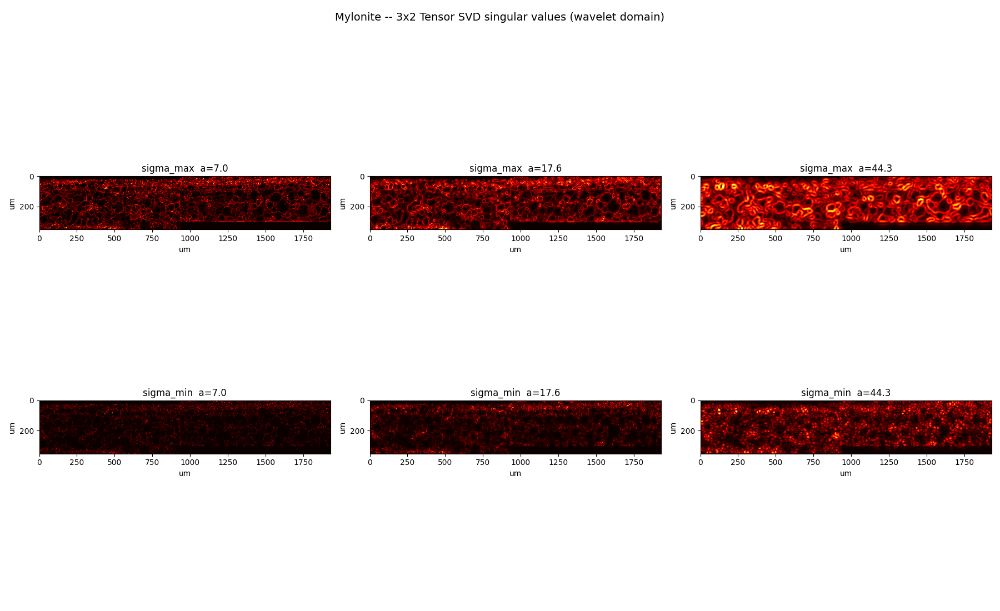

In [438]:
# Show sigma_max at 3 representative scales
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
show_si = [0, len(scales)//3, 2*len(scales)//3]
for col, si in enumerate(show_si):
    axes[0, col].imshow(sigma_max_all[si], extent=extent, cmap='hot', interpolation='nearest')
    axes[0, col].set_title(f'sigma_max  a={scales[si]:.1f}')
    axes[1, col].imshow(sigma_min_all[si], extent=extent, cmap='hot', interpolation='nearest')
    axes[1, col].set_title(f'sigma_min  a={scales[si]:.1f}')
for ax in axes.flat:
    ax.set_xlabel('um'); ax.set_ylabel('um')
plt.suptitle(f'{meta["name"]} -- 3x2 Tensor SVD singular values (wavelet domain)', fontsize=14)
plt.tight_layout()
plt.show()

### Holder Map + Distribution

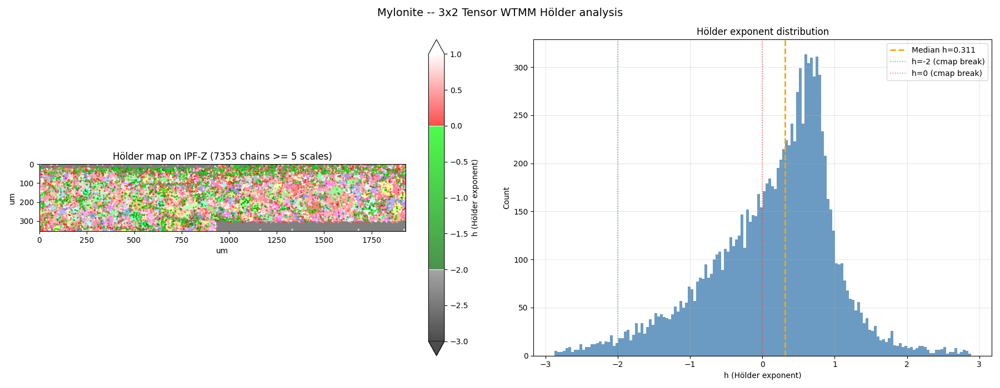

In [439]:
# --- Custom Hölder colormap ---
#   h < -2:           black → grey (h = -3 → -2)
#   h = -2:           discontinuity grey → dark green
#   -2 < h < 0:       dark green → lime green
#   h = 0:            discontinuity lime green → red
#   h > 0:            red → white (h = 0 → 1)
from matplotlib.colors import LinearSegmentedColormap, to_rgb as _to_rgb

HOLDER_VMIN = -3.0
HOLDER_VMAX =  1.0

_black     = _to_rgb('black')
_grey      = _to_rgb('grey')
_darkgreen = _to_rgb('darkgreen')
_lime      = _to_rgb('lime')
_red       = _to_rgb('red')
_white     = _to_rgb('white')

def _h_pos(h):
    return (h - HOLDER_VMIN) / (HOLDER_VMAX - HOLDER_VMIN)

_p_low = _h_pos(-2.0)   # grey | darkgreen discontinuity
_p_mid = _h_pos( 0.0)   # lime  | red       discontinuity

def _chan(i):
    return [
        (0.0,    _black[i],     _black[i]),       # h = -3: black
        (_p_low, _grey[i],      _darkgreen[i]),   # h = -2: grey on left, darkgreen on right
        (_p_mid, _lime[i],      _red[i]),         # h =  0: lime on left, red on right
        (1.0,    _white[i],     _white[i]),       # h =  1: white
    ]

holder_cmap = LinearSegmentedColormap(
    'holder_custom',
    {'red': _chan(0), 'green': _chan(1), 'blue': _chan(2)},
    N=512,
)
holder_cmap.set_bad('magenta')

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Holder map overlaid on IPF-Z
ipf_bg = ipf_color_cubic(ebsd['euler1'], ebsd['euler2'], ebsd['euler3'], sample_dir='Z')
if ebsd['phase'] is not None:
    ipf_bg[ebsd['phase'] == 0] = 0

axes[0].imshow(ipf_bg, extent=extent, interpolation='nearest', alpha=0.5)
long_ch = [(h, ch) for h, ch in zip(holders, chains) if len(ch['mod']) >= 5]
if long_ch:
    xs = np.array([h['x'] for h, _ in long_ch])
    ys = np.array([h['y'] for h, _ in long_ch])
    hs = np.array([h['h'] for h, _ in long_ch])
    sc = axes[0].scatter(xs * meta['xstep'], ys * meta['ystep'],
                         c=hs, cmap=holder_cmap, s=2,
                         vmin=HOLDER_VMIN, vmax=HOLDER_VMAX, alpha=0.7)
    cb = plt.colorbar(sc, ax=axes[0], label='h (Hölder exponent)',
                      extend='both')
    # Mark the colormap discontinuities on the colorbar
    for _hv in (-2.0, 0.0):
        cb.ax.axhline(_hv, color='white', lw=0.8, alpha=0.9)
axes[0].set_title(f'Hölder map on IPF-Z ({len(long_ch)} chains >= 5 scales)')
axes[0].set_xlabel('um'); axes[0].set_ylabel('um')

# Holder histogram
h_finite = h_vals[np.isfinite(h_vals)]
axes[1].hist(h_finite, bins=150, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(np.nanmedian(h_finite), color='orange', ls='--', lw=2,
                label=f'Median h={np.nanmedian(h_finite):.3f}')
axes[1].axvline(-2.0, color='green', ls=':', lw=1.2, alpha=0.6, label='h=-2 (cmap break)')
axes[1].axvline( 0.0, color='red',   ls=':', lw=1.2, alpha=0.6, label='h=0 (cmap break)')
axes[1].set_xlabel('h (Hölder exponent)')
axes[1].set_ylabel('Count')
axes[1].set_title('Hölder exponent distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'{meta["name"]} -- 3x2 Tensor WTMM Hölder analysis', fontsize=14)
plt.tight_layout()
plt.show()


### Anisotropy Analysis (Khalil et al. 2006)

Three diagnostics using the existing WTMM data — no new CWT needed:

1. **P_a(A)**: PDF of wavelet argument across scales. Flat = isotropic grain boundaries,
   peaked = preferred orientation (crystallographic anisotropy).
2. **Component-wise PDF collapse**: Rescale T_ψ₁ (dx) and T_ψ₂ (dy) by a^H independently
   to find H_x and H_y — directional roughness exponents of the Euler angle fields.
3. **tan(A_ψ) scaling**: slope of log|tan(A)| vs log(a) = H_y − H_x directly.

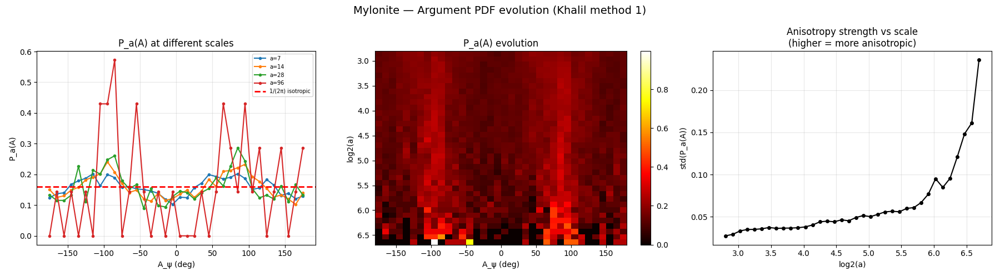

Dominant gradient direction at finest scale: 85°


In [440]:
# (%matplotlib inline removed — cell 2 sets widget backend globally)
import sys
sys.path.insert(0, 'XSmurfWrapper')
from theory.directional import argument_pdf_evolution, component_pdf_collapse, argument_scaling

# 1. P_a(A) — argument PDF evolution
pa_ebsd = argument_pdf_evolution(ext_images, scales, n_bins=36)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# P_a(A) at 4 representative scales
scale_show = [0, len(scales)//4, len(scales)//2, len(scales)-2]
for si in scale_show:
    a = scales[si]
    axes[0].plot(np.degrees(pa_ebsd['bin_centers']), pa_ebsd['Pa_A'][si],
                 '.-', label=f'a={a:.0f}')
axes[0].axhline(1/(2*np.pi), color='red', ls='--', lw=2, label='1/(2π) isotropic')
axes[0].set(xlabel='A_ψ (deg)', ylabel='P_a(A)', title='P_a(A) at different scales')
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

# P_a(A) as scale-angle heatmap
axes[1].imshow(pa_ebsd['Pa_A'], aspect='auto', cmap='hot',
               extent=[-180, 180, pa_ebsd['log2_scales'][-1], pa_ebsd['log2_scales'][0]])
axes[1].set(xlabel='A_ψ (deg)', ylabel='log2(a)', title='P_a(A) evolution')
plt.colorbar(axes[1].images[0], ax=axes[1], fraction=0.046)

# Deviation from isotropy: std of P_a(A) per scale
pa_std = np.std(pa_ebsd['Pa_A'], axis=1)
axes[2].plot(pa_ebsd['log2_scales'], pa_std, 'ko-', ms=4)
axes[2].set(xlabel='log2(a)', ylabel='std(P_a(A))',
            title='Anisotropy strength vs scale\n(higher = more anisotropic)')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{meta["name"]} — Argument PDF evolution (Khalil method 1)', fontsize=14)
plt.tight_layout(); plt.show()

# Report peak directions at finest scale
finest_pa = pa_ebsd['Pa_A'][0]
peak_idx = np.argmax(finest_pa)
peak_angle = np.degrees(pa_ebsd['bin_centers'][peak_idx])
print(f'Dominant gradient direction at finest scale: {peak_angle:.0f}°')

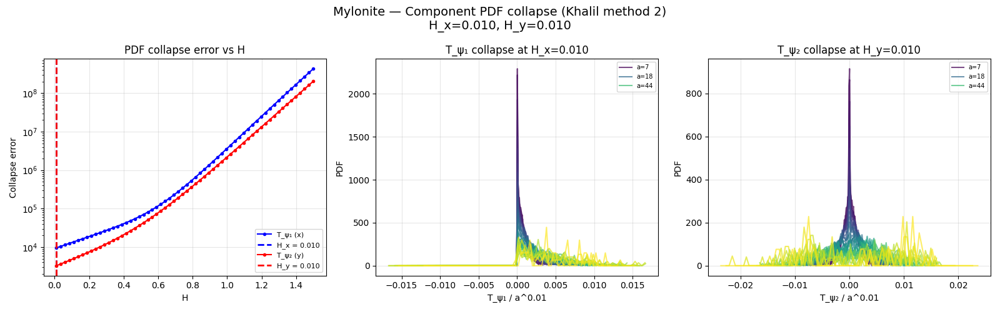

Directional Hurst exponents:
  H_x = 0.010 (x-direction roughness)
  H_y = 0.010 (y-direction roughness)
  => Approximately isotropic (|H_x - H_y| < 0.05)


In [441]:
# 2. Component-wise PDF collapse — find H_x and H_y
# Uses the tensor SVD derivatives (deriv_e1, deriv_e2, deriv_e3)
# We combine them via the SVD modulus/arg to get effective T_ψ₁ and T_ψ₂

# For the 3x2 tensor case, T_ψ₁ and T_ψ₂ are the SVD-projected components
# Reconstruct from sigma_max * cos(arg) and sigma_max * sin(arg)
# These are already stored as the dx/dy used for NMS

# Build a "deriv" dict with dx=T_ψ₁, dy=T_ψ₂ from the tensor SVD output
deriv_svd = {
    'dx': np.zeros((len(scales), ny, nx), dtype=np.float32),
    'dy': np.zeros((len(scales), ny, nx), dtype=np.float32),
}
for i in range(len(scales)):
    s_max, s_min, arg = tensor_svd_3x2(
        deriv_e1['dx'][i], deriv_e1['dy'][i],
        deriv_e2['dx'][i], deriv_e2['dy'][i],
        deriv_e3['dx'][i], deriv_e3['dy'][i])
    deriv_svd['dx'][i] = (s_max * np.cos(arg)).astype(np.float32)
    deriv_svd['dy'][i] = (s_max * np.sin(arg)).astype(np.float32)

collapse_ebsd = component_pdf_collapse(
    deriv_svd, scales, ext_images,
    H_test_range=(0.01, 1.5), n_H=60, n_bins=80)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(collapse_ebsd['H_test'], collapse_ebsd['collapse_error_x'], 'b.-', label='T_ψ₁ (x)')
axes[0].axvline(collapse_ebsd['H_x'], color='blue', ls='--', lw=2,
                label=f'H_x = {collapse_ebsd["H_x"]:.3f}')
axes[0].plot(collapse_ebsd['H_test'], collapse_ebsd['collapse_error_y'], 'r.-', label='T_ψ₂ (y)')
axes[0].axvline(collapse_ebsd['H_y'], color='red', ls='--', lw=2,
                label=f'H_y = {collapse_ebsd["H_y"]:.3f}')
axes[0].set(xlabel='H', ylabel='Collapse error', title='PDF collapse error vs H')
axes[0].set_yscale('log')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Show collapsed PDFs at best H_x
cmap_sc = plt.cm.viridis
n_pdfs = len(collapse_ebsd['pdfs_x'])
for idx, (si, pdf_data) in enumerate(sorted(collapse_ebsd['pdfs_x'].items())):
    c = cmap_sc(idx / max(1, n_pdfs - 1))
    axes[1].plot(pdf_data['centers'], pdf_data['pdf'], '-', color=c, alpha=0.7,
                 label=f'a={pdf_data["scale"]:.0f}' if idx % max(1, n_pdfs//3) == 0 else None)
axes[1].set(xlabel=f'T_ψ₁ / a^{collapse_ebsd["H_x"]:.2f}', ylabel='PDF',
            title=f'T_ψ₁ collapse at H_x={collapse_ebsd["H_x"]:.3f}')
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

n_pdfs_y = len(collapse_ebsd['pdfs_y'])
for idx, (si, pdf_data) in enumerate(sorted(collapse_ebsd['pdfs_y'].items())):
    c = cmap_sc(idx / max(1, n_pdfs_y - 1))
    axes[2].plot(pdf_data['centers'], pdf_data['pdf'], '-', color=c, alpha=0.7,
                 label=f'a={pdf_data["scale"]:.0f}' if idx % max(1, n_pdfs_y//3) == 0 else None)
axes[2].set(xlabel=f'T_ψ₂ / a^{collapse_ebsd["H_y"]:.2f}', ylabel='PDF',
            title=f'T_ψ₂ collapse at H_y={collapse_ebsd["H_y"]:.3f}')
axes[2].legend(fontsize=7); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{meta["name"]} — Component PDF collapse (Khalil method 2)\n'
             f'H_x={collapse_ebsd["H_x"]:.3f}, H_y={collapse_ebsd["H_y"]:.3f}', fontsize=14)
plt.tight_layout(); plt.show()

print(f'Directional Hurst exponents:')
print(f'  H_x = {collapse_ebsd["H_x"]:.3f} (x-direction roughness)')
print(f'  H_y = {collapse_ebsd["H_y"]:.3f} (y-direction roughness)')
if abs(collapse_ebsd['H_x'] - collapse_ebsd['H_y']) > 0.05:
    rougher = 'x' if collapse_ebsd['H_x'] < collapse_ebsd['H_y'] else 'y'
    print(f'  => Anisotropic: {rougher}-direction is rougher (lower H)')
else:
    print(f'  => Approximately isotropic (|H_x - H_y| < 0.05)')

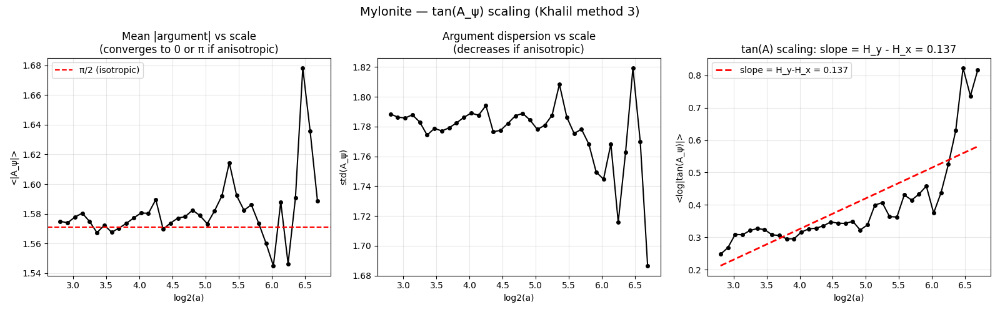

H_y - H_x from tan(A) scaling: 0.137
H_y - H_x from PDF collapse:   0.000
Consistency check: these should agree.


In [442]:
# 3. tan(A_ψ) scaling — direct anisotropy ratio
arg_sc = argument_scaling(ext_images, scales)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Mean |A| vs scale
axes[0].plot(arg_sc['log2_scales'], arg_sc['mean_abs_arg'], 'ko-', ms=4)
axes[0].axhline(np.pi/2, color='red', ls='--', label='π/2 (isotropic)')
axes[0].set(xlabel='log2(a)', ylabel='<|A_ψ|>',
            title='Mean |argument| vs scale\n(converges to 0 or π if anisotropic)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Std of A vs scale
axes[1].plot(arg_sc['log2_scales'], arg_sc['std_arg'], 'ko-', ms=4)
axes[1].set(xlabel='log2(a)', ylabel='std(A_ψ)',
            title='Argument dispersion vs scale\n(decreases if anisotropic)')
axes[1].grid(True, alpha=0.3)

# tan(A) scaling
valid = np.isfinite(arg_sc['mean_log_tan_arg'])
if valid.any():
    axes[2].plot(arg_sc['log2_scales'][valid], arg_sc['mean_log_tan_arg'][valid], 'ko-', ms=4)
    if np.isfinite(arg_sc['delta_H_fit']):
        x_fit = arg_sc['log2_scales'][valid]
        y_fit = arg_sc['delta_H_fit'] * x_fit * np.log(2)  # convert slope to natural log scale
        axes[2].plot(x_fit, y_fit + arg_sc['mean_log_tan_arg'][valid].mean() - y_fit.mean(),
                     'r--', lw=2, label=f'slope = H_y-H_x = {arg_sc["delta_H_fit"]:.3f}')
axes[2].set(xlabel='log2(a)', ylabel='<log|tan(A_ψ)|>',
            title=f'tan(A) scaling: slope = H_y - H_x = {arg_sc["delta_H_fit"]:.3f}')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{meta["name"]} — tan(A_ψ) scaling (Khalil method 3)', fontsize=14)
plt.tight_layout(); plt.show()

print(f'H_y - H_x from tan(A) scaling: {arg_sc["delta_H_fit"]:.3f}')
print(f'H_y - H_x from PDF collapse:   {collapse_ebsd["H_y"] - collapse_ebsd["H_x"]:.3f}')
print(f'Consistency check: these should agree.')

### Partition Function + Multifractal Spectrum D(h)

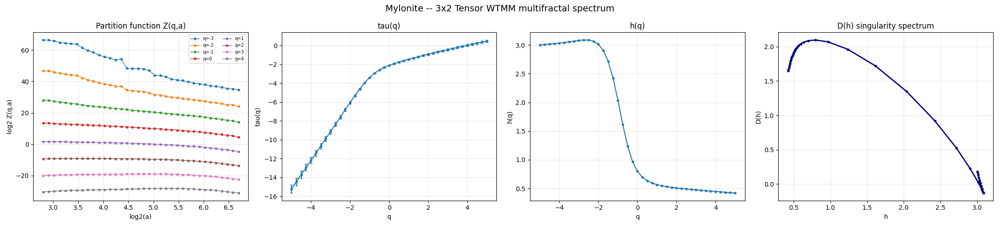


Multifractal parameters:
  h(q=0) = 0.799  (most singular dimension)
  h(q=1) = 0.567  (information dimension)
  D(q=0) = 2.098  (box-counting dimension)
  h range: [0.423, 3.087]
  Width of D(h): 2.663  (multifractality strength)


In [443]:
# Step 5: Partition function and multifractal spectrum
spectra = xsm.compute_spectra(ext_images, scales)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Z(q,a)
q_show = np.arange(-3, 5, 1.0)
for q in q_show:
    qi = np.argmin(np.abs(spectra['q_list'] - q))
    axes[0].plot(spectra['log2_scales'], spectra['log2_Z'][qi], '.-',
                 label=f'q={q:.0f}', lw=1)
axes[0].set(xlabel='log2(a)', ylabel='log2 Z(q,a)', title='Partition function Z(q,a)')
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(True, alpha=0.3)

# tau(q)
axes[1].errorbar(spectra['q_list'], spectra['tau'],
                 yerr=spectra.get('tau_err', None), fmt='.-', capsize=2)
axes[1].set(xlabel='q', ylabel='tau(q)', title='tau(q)')
axes[1].grid(True, alpha=0.3)

# h(q)
axes[2].plot(spectra['q_list'], spectra['h'], '.-')
axes[2].set(xlabel='q', ylabel='h(q)', title='h(q)')
axes[2].grid(True, alpha=0.3)

# D(h) spectrum
valid = np.isfinite(spectra['D']) & np.isfinite(spectra['h'])
axes[3].plot(spectra['h'][valid], spectra['D'][valid], '.-', color='darkblue', lw=2)
axes[3].set(xlabel='h', ylabel='D(h)', title='D(h) singularity spectrum')
axes[3].grid(True, alpha=0.3)

plt.suptitle(f'{meta["name"]} -- 3x2 Tensor WTMM multifractal spectrum', fontsize=14)
plt.tight_layout()
plt.show()

# Print key multifractal parameters
h_at_q0 = spectra['h'][np.argmin(np.abs(spectra['q_list'] - 0))]
h_at_q1 = spectra['h'][np.argmin(np.abs(spectra['q_list'] - 1))]
D_at_q0 = spectra['D'][np.argmin(np.abs(spectra['q_list'] - 0))]
h_range = spectra['h'][valid]
print(f'\nMultifractal parameters:')
print(f'  h(q=0) = {h_at_q0:.3f}  (most singular dimension)')
print(f'  h(q=1) = {h_at_q1:.3f}  (information dimension)')
print(f'  D(q=0) = {D_at_q0:.3f}  (box-counting dimension)')
print(f'  h range: [{h_range.min():.3f}, {h_range.max():.3f}]')
print(f'  Width of D(h): {h_range.max() - h_range.min():.3f}  (multifractality strength)')

### Skeleton Plot: Spurious vs Genuine Chains

Chains whose supremum (max |W|) is at the **finest** scale are typically noise — real
singularities have modulus *increasing* with scale. Split the skeleton to check.

Chains: 2374 sup-at-finest (spurious), 8782 genuine


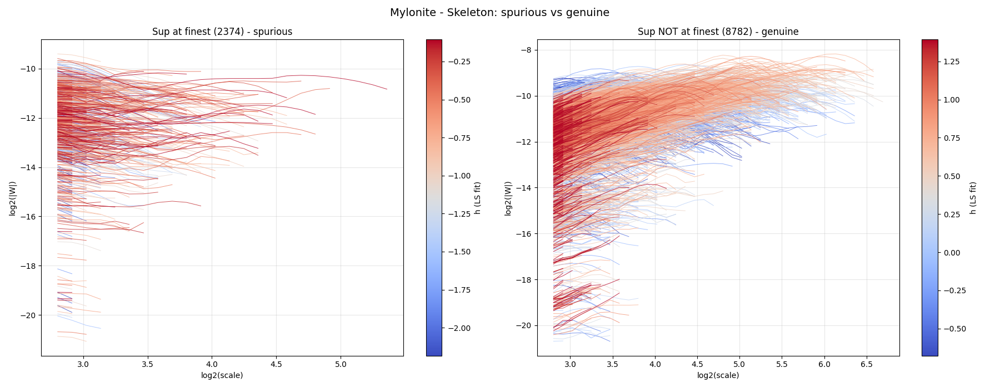

In [444]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.collections import LineCollection

# Holder lookups
h_fit_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in holders}
holders_slope = xsm.compute_holder_local_slope(chains, method='max')
h_slope_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in holders_slope}

# Classify chains: sup-at-finest (spurious) vs genuine
chain_sup_finest = set()
chain_genuine = set()
for ch in chains:
    n = len(ch['mod'])
    if n < 2: continue
    anchor = (int(ch['x'][0]), int(ch['y'][0]))
    sup_idx = np.argmax(np.abs(ch['mod']))
    if sup_idx == 0:
        chain_sup_finest.add(anchor)
    else:
        chain_genuine.add(anchor)

print(f"Chains: {len(chain_sup_finest)} sup-at-finest (spurious), {len(chain_genuine)} genuine")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
log2_s = np.log2(np.array(scales))

for col, (ax, title, anchor_set) in enumerate([
    (axes[0], f'Sup at finest ({len(chain_sup_finest)}) - spurious', chain_sup_finest),
    (axes[1], f'Sup NOT at finest ({len(chain_genuine)}) - genuine', chain_genuine)]):
    
    items = []
    for ch in chains[:5000]:
        n = len(ch['mod'])
        if n < 2: continue
        anchor = (int(ch['x'][0]), int(ch['y'][0]))
        if anchor not in anchor_set: continue
        h = h_fit_lookup.get(anchor, np.nan)
        if not np.isfinite(h): continue
        items.append((h, n, ch['log2_mod']))
    
    if items:
        items.sort(key=lambda t: t[0])
        hv = np.array([t[0] for t in items])
        vn, vx = np.percentile(hv, [5, 95])
        if vn == vx: vn, vx = hv.min(), hv.max()
        nm = Normalize(vmin=vn, vmax=vx)
        cm = plt.cm.coolwarm
        for h, n, lm in items:
            ax.plot(log2_s[:n], lm, '-', color=cm(nm(h)), alpha=0.8, lw=0.7)
        sm = ScalarMappable(norm=nm, cmap=cm); sm.set_array([])
        plt.colorbar(sm, ax=ax, label='h (LS fit)')
    
    ax.set(xlabel='log2(scale)', ylabel='log2(|W|)', title=title)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'{meta["name"]} - Skeleton: spurious vs genuine', fontsize=14)
plt.tight_layout()
plt.show()

### Chain Filter

Remove spurious chains before recomputing partition function. Adjust thresholds
based on the skeleton plot above.

Filtered: 9439 / 11156 chains
  log2(mod) >= -14.0, min_vc >= 1, remove_sup_finest=False
  FRAC_INT_EXPO = 0.0
  Median h (filtered): 0.322


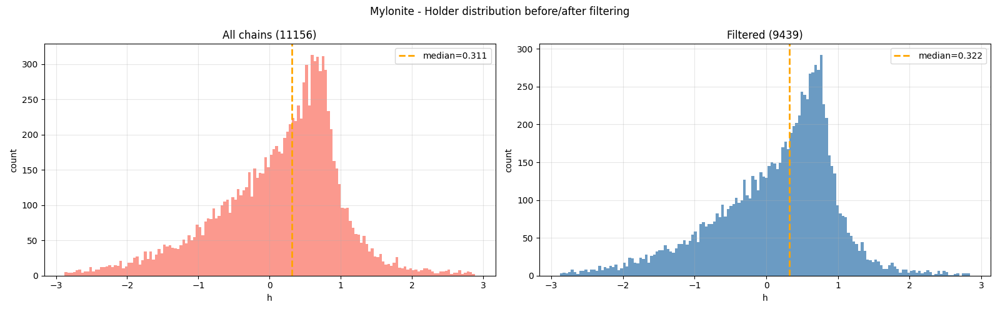

In [445]:
# --- Filter parameters (adjust based on skeleton plot) ---
LOG2_MOD_MIN = -14.0          # remove chains with mean log2(|W|) below this
MIN_VC_PF = 1                # minimum vertical chain length
MIN_H_PF = -3.0               # minimum Holder exponent (-5 = no filter)
REMOVE_SUP_AT_FINEST = False   # remove chains whose max modulus is at finest scale

# Fractional integration exponent used in chainmax.
# The chainmax supremum uses |M| * a^FRAC_INT_EXPO, so the measured Holder
# exponents are shifted by this value. Subtract it when displaying h.
FRAC_INT_EXPO = 0.0           # set to e.g. 1.0 if using fractional integration

filtered_chains = []
for ch in chains:
    n = len(ch['mod'])
    if n < MIN_VC_PF:
        continue
    mean_log2_mod = np.mean(ch['log2_mod'])
    if mean_log2_mod < LOG2_MOD_MIN:
        continue
    if REMOVE_SUP_AT_FINEST and n >= 2:
        sup_idx = np.argmax(np.abs(ch['mod']))
        if sup_idx == 0:
            continue
    key = (int(ch['x'][0]), int(ch['y'][0]))
    h = h_fit_lookup.get(key, np.nan)
    if MIN_H_PF > -4.9 and (np.isnan(h) or h < MIN_H_PF):
        continue
    filtered_chains.append(ch)

print(f"Filtered: {len(filtered_chains)} / {len(chains)} chains")
print(f"  log2(mod) >= {LOG2_MOD_MIN}, min_vc >= {MIN_VC_PF}, "
      f"remove_sup_finest={REMOVE_SUP_AT_FINEST}")
print(f"  FRAC_INT_EXPO = {FRAC_INT_EXPO}")

# Build filtered positions set for partition function
filtered_positions = set()
for ch in filtered_chains:
    n_ch = len(ch['mod'])
    for si in range(min(n_ch, len(scales))):
        filtered_positions.add((si, int(ch['x'][si]), int(ch['y'][si])))

# Build chainmax lookup
chainmax = [{} for _ in range(len(scales))]
for ch in filtered_chains:
    n_ch = len(ch['mod'])
    running_max = 0.0
    for si in range(min(n_ch, len(scales))):
        m = abs(float(ch['mod'][si]))
        if m > running_max:
            running_max = m
        chainmax[si][(int(ch['x'][si]), int(ch['y'][si]))] = running_max

# Recompute holders on filtered chains
filtered_holders = xsm.compute_holder_exponents(filtered_chains)
h_filt = np.array([h['h'] for h in filtered_holders])
print(f"  Median h (filtered): {np.nanmedian(h_filt):.3f}")

# Compare histograms
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
h_all = np.array([h['h'] for h in holders])
for ax, vals, title, color in [
    (axes[0], h_all[np.isfinite(h_all)], f'All chains ({len(chains)})', 'salmon'),
    (axes[1], h_filt[np.isfinite(h_filt)], f'Filtered ({len(filtered_chains)})', 'steelblue')]:
    ax.hist(vals, bins=150, color=color, edgecolor='none', alpha=0.8)
    ax.axvline(np.median(vals), color='orange', ls='--', lw=2,
               label=f'median={np.median(vals):.3f}')
    ax.set(xlabel='h', ylabel='count', title=title)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle(f'{meta["name"]} - Holder distribution before/after filtering')
plt.tight_layout()
plt.show()

### Filtered Partition Function + D(h)

Recompute spectra using only the filtered (genuine) chains.

In [453]:
# Compute BOTH standard and chainmax partition functions on filtered chains
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

q_list_full = np.arange(-1, 8, 0.1) #np.concatenate([np.arange(-5, -2, 0.5), np.arange(-2, 2.01, 0.25), np.arange(2.5, 5.5, 0.5)])
n_q = len(q_list_full)
n_sc = len(scales)
log2 = np.log(2.0)

# Standard: use wavelet modulus at each scale
STq_std = np.zeros((n_q, n_sc), dtype=np.float64)
STqlogT_std = np.zeros((n_q, n_sc), dtype=np.float64)

# Chainmax: use running max modulus along the chain up to current scale
STq_cmax = np.zeros((n_q, n_sc), dtype=np.float64)
STqlogT_cmax = np.zeros((n_q, n_sc), dtype=np.float64)

Nq = np.zeros(n_sc, dtype=np.int64)

for ch in filtered_chains:
    n_ch = len(ch['mod'])
    running_max = 0.0
    for si in range(min(n_ch, n_sc)):
        m = abs(float(ch['mod'][si]))
        if m <= 0: continue
        if m > running_max:
            running_max = m
        log_m = np.log(m)
        log_m_sup = np.log(max(running_max, 1e-30))
        Nq[si] += 1
        for qi, q in enumerate(q_list_full):
            mq = m ** q if q != 0 else 1.0
            STq_std[qi, si] += mq
            STqlogT_std[qi, si] += log_m * mq
            mq_sup = running_max ** q if q != 0 else 1.0
            STq_cmax[qi, si] += mq_sup
            STqlogT_cmax[qi, si] += log_m_sup * mq_sup

def build_hd(STq_in, STqlogT_in):
    tau = np.full((n_q, n_sc), np.nan)
    h = np.full((n_q, n_sc), np.nan)
    D = np.full((n_q, n_sc), np.nan)
    vZ = STq_in > 0
    tau[vZ] = np.log(STq_in[vZ]) / log2
    h[vZ] = STqlogT_in[vZ] / (log2 * STq_in[vZ])
    for qi, q in enumerate(q_list_full):
        for si in range(n_sc):
            if STq_in[qi, si] > 0:
                D[qi, si] = (q * STqlogT_in[qi, si] - STq_in[qi, si] * np.log(STq_in[qi, si])) / (STq_in[qi, si] * log2)
    return {'tau_qa': tau, 'h_qa': h, 'D_qa': D,
            'q_list': q_list_full, 'scales': np.array(scales),
            'log2_scales': np.log2(np.array(scales))}

hd_std = build_hd(STq_std, STqlogT_std)
hd_cmax = build_hd(STq_cmax, STqlogT_cmax)

print(f'Partition functions computed: {n_q} q-values, {n_sc} scales')
print(f'Extrema per scale (sample): {Nq[::max(1,n_sc//4)]}')
print(f'Standard and chainmax both ready')

Partition functions computed: 90 q-values, 36 scales
Extrema per scale (sample): [9439 4129 1330  289]
Standard and chainmax both ready


In [454]:
# --- Scalar WTMM pipeline on KAM (for the interactive D(h) viewer) ---
# Reuses scales, wavelet choice, thresholds, and filter params from the
# tensor pipeline above. Produces hd_kam and hd_kam_cmax with the same
# structure as hd_std / hd_cmax so the interactive cell can toggle between
# tensor (log-orientation / Euler) and scalar (KAM) multifractal spectra on
# the same dataset.
#
# Requires: cells above through cell 49 (filter params + hd_std/hd_cmax build)
# must already have been run, AND ebsd['kam'] must exist (from the KAM cell).

if 'kam' not in ebsd or ebsd['kam'] is None:
    print("ebsd['kam'] not computed — run the KAM cell above first. Skipping.")
    hd_kam = None
    hd_kam_cmax = None
else:
    kam_in = np.nan_to_num(ebsd['kam'], nan=0.0).astype(np.float32)
    print(f'KAM scalar WTMM: CWT on KAM field {kam_in.shape}, {len(scales)} scales...')
    _derivs_mode_kam = 'all' if EXTREMA_METHOD == 'follow' else 'first'
    deriv_kam = cwt_2d_f32(kam_in, scales, pad=32, derivs=_derivs_mode_kam,
                           wavelet=WAVELET, verbose=False)

    # Scalar WTMM extrema detection (NMS on the CWT first derivatives directly,
    # no tensor SVD step — this is the standard single-channel WTMM pipeline).
    ext_images_kam = []
    for i, scale in enumerate(scales):
        if EXTREMA_METHOD == 'follow':
            kapa = gkapa_numpy(
                deriv_kam['dx'][i], deriv_kam['dy'][i],
                deriv_kam['dxx'][i], deriv_kam['dxy'][i], deriv_kam['dyy'][i])
            kapap = gkapap_numpy(
                deriv_kam['dx'][i], deriv_kam['dy'][i],
                deriv_kam['dxx'][i], deriv_kam['dxy'][i], deriv_kam['dyy'][i],
                deriv_kam['dxxx'][i], deriv_kam['dxxy'][i],
                deriv_kam['dxyy'][i], deriv_kam['dyyy'][i])
            ext = xsm.find_extrema_follow(
                xsm.XImage.from_numpy(kapa),
                xsm.XImage.from_numpy(kapap),
                xsm.XImage.from_numpy(deriv_kam['mod'][i]),
                xsm.XImage.from_numpy(deriv_kam['arg'][i]),
                scale, thresh=THRESH)
        else:
            ext, _, _ = xsm.wtmm2d(
                xsm.XImage.from_numpy(deriv_kam['dx'][i].astype(np.float32)),
                xsm.XImage.from_numpy(deriv_kam['dy'][i].astype(np.float32)),
                scale, thresh=THRESH)
        ext_images_kam.append(ext)

    for i in range(len(ext_images_kam)):
        ext_images_kam[i] = xsm.cut_edge(ext_images_kam[i], border_percent=BORDER_PERCENT)

    xsm.chain(ext_images_kam, a_min=1.0, n_oct=n_oct, n_vox=n_vox,
              smooth=SMOOTH_CHAINS, verbose=False)
    chains_kam = xsm.extract_vertical_chains(ext_images_kam, scales)
    holders_kam = xsm.compute_holder_exponents(chains_kam)
    h_fit_lookup_kam = {(int(h['x']), int(h['y'])): h['h'] for h in holders_kam}
    print(f'  {len(chains_kam)} raw chains, median h = '
          f"{np.nanmedian([h['h'] for h in holders_kam]):.3f}")

    # Filter with the SAME parameters as the tensor pipeline (cell 47).
    # If the KAM-derived wavelet moduli live on a very different numerical
    # scale from the tensor σ_max, you may want to override LOG2_MOD_MIN here.
    filtered_chains_kam = []
    for ch in chains_kam:
        n_ch = len(ch['mod'])
        if n_ch < MIN_VC_PF:
            continue
        if np.mean(ch['log2_mod']) < LOG2_MOD_MIN:
            continue
        if REMOVE_SUP_AT_FINEST and n_ch >= 2:
            if np.argmax(np.abs(ch['mod'])) == 0:
                continue
        h_c = h_fit_lookup_kam.get((int(ch['x'][0]), int(ch['y'][0])), np.nan)
        if MIN_H_PF > -4.9 and (np.isnan(h_c) or h_c < MIN_H_PF):
            continue
        filtered_chains_kam.append(ch)

    print(f'  Filtered chains: {len(filtered_chains_kam)}/{len(chains_kam)}')

    # Build partition functions (standard + chainmax) on the filtered KAM chains.
    STq_kam  = np.zeros((n_q, n_sc), dtype=np.float64)
    STqlt_kam = np.zeros((n_q, n_sc), dtype=np.float64)
    STq_kam_c  = np.zeros((n_q, n_sc), dtype=np.float64)
    STqlt_kam_c = np.zeros((n_q, n_sc), dtype=np.float64)
    for ch in filtered_chains_kam:
        running_max = 0.0
        n_ch = len(ch['mod'])
        for si in range(min(n_ch, n_sc)):
            m = abs(float(ch['mod'][si]))
            if m <= 0:
                continue
            if m > running_max:
                running_max = m
            log_m = np.log(m)
            log_m_sup = np.log(max(running_max, 1e-30))
            for qi, q in enumerate(q_list_full):
                mq = m ** q if q != 0 else 1.0
                STq_kam[qi, si]  += mq
                STqlt_kam[qi, si] += log_m * mq
                mq_sup = running_max ** q if q != 0 else 1.0
                STq_kam_c[qi, si]  += mq_sup
                STqlt_kam_c[qi, si] += log_m_sup * mq_sup

    hd_kam      = build_hd(STq_kam,   STqlt_kam)
    hd_kam_cmax = build_hd(STq_kam_c, STqlt_kam_c)
    print('  hd_kam and hd_kam_cmax ready — selectable in the interactive viewer.')


KAM scalar WTMM: CWT on KAM field (353, 1929), 36 scales...
  11265 raw chains, median h = -0.902
  Filtered chains: 11259/11265
  hd_kam and hd_kam_cmax ready — selectable in the interactive viewer.


### Interactive Partition Function

**Left-click** to set min scale, **right-click** to set max scale for fitting.

Toggle **Standard** vs **Chainmax** (`-vc_max`): chainmax replaces each extremum's
modulus with the running maximum along its vertical chain up to that scale.
This stabilizes the partition function for negative q (sensitive to small moduli).

In [455]:
# (%matplotlib widget moved to its own cell near the top)
from IPython.display import display, clear_output
from ipywidgets import VBox

fit_state = {'scale_min': scales[2], 'scale_max': scales[-3]}
log2_s = hd_std['log2_scales']

chainmax_toggle = widgets.ToggleButtons(
    options=['Standard (-vc)', 'Chainmax (-vc_max)', 'KAM scalar', 'KAM chainmax'],
    value='Standard (-vc)', description='Method:')

q_show = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4])
colors_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))

def get_hd():
    v = chainmax_toggle.value
    if v == 'KAM scalar':     return hd_kam
    if v == 'KAM chainmax':   return hd_kam_cmax
    if v == 'Chainmax (-vc_max)': return hd_cmax
    return hd_std

# Persistent figure: 3 PF panels (top) + 2 spectrum panels (bottom)
with plt.ioff():
    _fig_pf, _axes_pf = plt.subplots(2, 3, figsize=(18, 9),
                                      gridspec_kw={'height_ratios': [1, 1]})
_axes_top = _axes_pf[0]  # tau, h, D vs log2(a)
_ax_tau_h = _axes_pf[1, 0]  # tau(q) + h(q) twin
_ax_tau_h_twin = _ax_tau_h.twinx()  # persistent twin axis for h(q)
_ax_dh = _axes_pf[1, 1]     # D(h)
_axes_pf[1, 2].set_visible(False)  # unused

def _on_click_pf(event):
    if event.inaxes is None or event.xdata is None: return
    # Only respond to clicks on the top-row axes
    if event.inaxes not in _axes_top: return
    a = 2 ** event.xdata
    if event.button == 1: fit_state['scale_min'] = a
    elif event.button == 3: fit_state['scale_max'] = a
    if fit_state['scale_min'] > fit_state['scale_max']:
        fit_state['scale_min'], fit_state['scale_max'] = fit_state['scale_max'], fit_state['scale_min']
    draw_all()

_fig_pf.canvas.mpl_connect('button_press_event', _on_click_pf)

def draw_all(*_):
    smin, smax = fit_state['scale_min'], fit_state['scale_max']
    s_mask = (np.array(scales) >= smin) & (np.array(scales) <= smax)
    hd = get_hd()
    method = chainmax_toggle.value

    # Top row: tau, h, D vs log2(a)
    for ax in _axes_top:
        ax.cla()
    for panel, (key, ylabel, title) in enumerate([
        ('tau_qa', 'log2 Z(q,a)', 'tau(q,a)'),
        ('h_qa', 'h(q,a)', 'h(q,a)'),
        ('D_qa', 'D(q,a)', 'D(q,a)')]):
        ax = _axes_top[panel]
        for qi, color in zip(q_show, colors_q):
            idx = np.argmin(np.abs(hd['q_list'] - qi))
            y = hd[key][idx]; v = np.isfinite(y)
            if v.sum() < 2: continue
            ax.plot(log2_s[v], y[v], 'o', color=color, ms=3, alpha=0.7, mec='none')
            yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
            if vf.sum() >= 2:
                try:
                    sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                    xl = log2_s[v]
                    ax.plot(xl, sl*xl+ic, '-', color=color, lw=1.2, alpha=0.5)
                    ax.text(xl[-1]+0.05, sl*xl[-1]+ic, f'{qi:g}', color=color, fontsize=7, va='center')
                except: pass
        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
        ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.set(xlabel='log2(a)', ylabel=ylabel, title=title)
        ax.grid(True, alpha=0.2)
    _axes_top[1].set_title(f'{method} L-click=min R-click=max [{smin:.1f},{smax:.1f}]', fontsize=9)

    # Bottom row: tau(q)+h(q) and D(h)
    _ax_tau_h.cla()
    _ax_tau_h_twin.cla()
    _ax_dh.cla()

    if s_mask.sum() >= 2:
        res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin, smax))
        q = res['q_list']
        valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])

        if valid.any():
            _ax_tau_h.errorbar(q[valid], res['tau'][valid], yerr=res['tau_err'][valid],
                               fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label='tau(q)')
            _ax_tau_h.set(xlabel='q', ylabel='tau(q)')
            _ax_tau_h.tick_params(axis='y', labelcolor='steelblue')
            _ax_tau_h.grid(True, alpha=0.2)
            ax2 = _ax_tau_h_twin
            ax2.errorbar(q[valid], res['h'][valid], yerr=res['h_err'][valid],
                         fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label='h(q)')
            ax2.set(ylabel='h(q)')
            ax2.tick_params(axis='y', labelcolor='red')
            h_w = res['h'][valid].max() - res['h'][valid].min()
            _ax_tau_h.set_title(f'tau(q) & h(q) [{method}] dh={h_w:.3f}', fontsize=9)
            l1, lb1 = _ax_tau_h.get_legend_handles_labels()
            l2, lb2 = ax2.get_legend_handles_labels()
            _ax_tau_h.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=7)

            sc = _ax_dh.scatter(res['h'][valid], res['D'][valid], c=q[valid], cmap='coolwarm',
                                s=60, edgecolors='black', linewidths=0.5, zorder=5)
            _ax_dh.errorbar(res['h'][valid], res['D'][valid],
                            xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                            fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
            _ax_dh.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
            pk = np.argmax(res['D'][valid])
            _ax_dh.plot(res['h'][valid][pk], res['D'][valid][pk], 'r*', ms=18, zorder=10)
            _ax_dh.annotate(f"h*={res['h'][valid][pk]:.3f}\nD*={res['D'][valid][pk]:.3f}",
                            xy=(res['h'][valid][pk], res['D'][valid][pk]),
                            xytext=(res['h'][valid][pk]+0.05, res['D'][valid][pk]-0.15),
                            fontsize=9, arrowprops=dict(arrowstyle='->', color='red'),
                            bbox=dict(boxstyle='round', fc='lightyellow'))
            _ax_dh.set(xlabel='h', ylabel='D(h)', title=f'D(h) [{method}]')
            _ax_dh.legend(fontsize=7); _ax_dh.grid(True, alpha=0.2)

    _fig_pf.canvas.draw_idle()

chainmax_toggle.observe(draw_all, names='value')
print("LEFT-click = min scale | RIGHT-click = max scale")
display(VBox([chainmax_toggle, _fig_pf.canvas]))
draw_all()

LEFT-click = min scale | RIGHT-click = max scale


### Phase Transition Detection (Specific Heat)

Piecewise linear fit to τ(q) vs ln(q) to detect phase transitions. In the constant
specific heat approximation, τ(q) is linear in ln(q) within each phase. A breakpoint
q* where the slope changes indicates a phase transition (freezing of singularities).

**Click** the left plot (τ vs ln q) or the right plot (R² vs q) to set the breakpoint.

In [456]:
# (%matplotlib widget moved to its own cell near the top)
from IPython.display import display, clear_output
from ipywidgets import VBox

try:
    sr_pf = (fit_state['scale_min'], fit_state['scale_max'])
except NameError:
    sr_pf = (scales[2], scales[-3])

fit_state_pf = {'q_break': 1.0}

cm_toggle_pf = widgets.ToggleButtons(
    options=['Standard', 'Chainmax'],
    value='Standard', description='Method:')

def get_tau_data():
    hd_fit = hd_cmax if cm_toggle_pf.value == 'Chainmax' else hd_std
    res = extract_hq_Dq_from_plateaus(hd_fit, scale_range=sr_pf)
    return res['q_list'], res['tau'], res['h'], np.isfinite(res['tau']), res

# Persistent figure
with plt.ioff():
    _fig_pt, _axes_pt = plt.subplots(1, 3, figsize=(16, 5))

def _on_click_pt(event):
    if event.inaxes == _axes_pt[0] and event.xdata is not None:
        fit_state_pf['q_break'] = float(np.exp(event.xdata))
        draw_fit()
    elif event.inaxes == _axes_pt[2] and event.xdata is not None:
        fit_state_pf['q_break'] = float(event.xdata)
        draw_fit()

_fig_pt.canvas.mpl_connect('button_press_event', _on_click_pt)

def draw_fit(*args):
    q_arr, tau_arr, h_arr, valid, _ = get_tau_data()
    q_v = q_arr[valid]; tau_v = tau_arr[valid]
    qb = fit_state_pf['q_break']
    method = cm_toggle_pf.value

    for ax in _axes_pt: ax.cla()

    # Left: tau vs ln(q)
    ax = _axes_pt[0]
    pos_mask = q_v > 0.01
    q_pos = q_v[pos_mask]; tau_pos = tau_v[pos_mask]
    lnq = np.log(q_pos)
    ax.plot(lnq, tau_pos, 'ko', ms=4, alpha=0.7, label='tau(q)')
    lnqb = np.log(max(qb, 0.01))
    mask_L = lnq <= lnqb; mask_R = lnq > lnqb
    slope_L, slope_R = np.nan, np.nan
    if mask_L.sum() >= 3:
        cL = np.polyfit(lnq[mask_L], tau_pos[mask_L], 1); slope_L = cL[0]
        fL = np.polyval(cL, lnq[mask_L])
        ss = np.sum((tau_pos[mask_L]-fL)**2); st = np.sum((tau_pos[mask_L]-tau_pos[mask_L].mean())**2)
        r2L = 1-ss/st if st > 0 else 0
        ax.plot(np.linspace(lnq[mask_L].min(), lnqb, 50),
                np.polyval(cL, np.linspace(lnq[mask_L].min(), lnqb, 50)),
                'b-', lw=2, label=f'L: slope={slope_L:.3f}, R\u00b2={r2L:.4f}')
    if mask_R.sum() >= 3:
        cR = np.polyfit(lnq[mask_R], tau_pos[mask_R], 1); slope_R = cR[0]
        fR = np.polyval(cR, lnq[mask_R])
        ss = np.sum((tau_pos[mask_R]-fR)**2); st = np.sum((tau_pos[mask_R]-tau_pos[mask_R].mean())**2)
        r2R = 1-ss/st if st > 0 else 0
        ax.plot(np.linspace(lnqb, lnq[mask_R].max(), 50),
                np.polyval(cR, np.linspace(lnqb, lnq[mask_R].max(), 50)),
                'r-', lw=2, label=f'R: slope={slope_R:.3f}, R\u00b2={r2R:.4f}')
    ax.axvline(lnqb, color='green', ls='--', lw=2, label=f'q*={qb:.2f}')
    ds = slope_L - slope_R if np.isfinite(slope_L) and np.isfinite(slope_R) else np.nan
    ax.set_title(f'tau vs ln(q), q*={qb:.2f}, ds={ds:.4f}', fontsize=9)
    ax.set(xlabel='ln(q)', ylabel='tau(q)'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # Middle: h(q)
    ax2 = _axes_pt[1]; v_h = np.isfinite(h_arr)
    ax2.plot(q_arr[v_h], h_arr[v_h], 'ko-', ms=4, alpha=0.7)
    if np.isfinite(slope_L): ax2.axhline(slope_L, color='blue', ls='--', lw=1.5, label=f'h_L={slope_L:.3f}')
    if np.isfinite(slope_R): ax2.axhline(slope_R, color='red', ls='--', lw=1.5, label=f'h_R={slope_R:.3f}')
    ax2.axvline(qb, color='green', ls='--', lw=2)
    ax2.set_title('h(q)', fontsize=9); ax2.set(xlabel='q', ylabel='h(q)')
    ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)

    # Right: R^2 scan
    ax3 = _axes_pt[2]
    q_test = np.linspace(max(q_pos.min()*1.5, 0.1), q_pos.max()*0.9, 100)
    r2_arr = []
    for qt in q_test:
        lqt = np.log(qt); mL = lnq <= lqt; mR = lnq > lqt
        r2l = r2r = np.nan; nL, nR = mL.sum(), mR.sum()
        if nL >= 3:
            c = np.polyfit(lnq[mL], tau_pos[mL], 1); f = np.polyval(c, lnq[mL])
            ss = np.sum((tau_pos[mL]-f)**2); st = np.sum((tau_pos[mL]-tau_pos[mL].mean())**2)
            r2l = 1-ss/st if st > 0 else 0
        if nR >= 3:
            c = np.polyfit(lnq[mR], tau_pos[mR], 1); f = np.polyval(c, lnq[mR])
            ss = np.sum((tau_pos[mR]-f)**2); st = np.sum((tau_pos[mR]-tau_pos[mR].mean())**2)
            r2r = 1-ss/st if st > 0 else 0
        r2_arr.append((r2l*nL+r2r*nR)/(nL+nR) if np.isfinite(r2l) and np.isfinite(r2r) and nL+nR > 0 else np.nan)
    ax3.plot(q_test, r2_arr, 'k-', lw=2, label='R\u00b2')
    ax3.axvline(qb, color='green', ls='--', lw=2)
    r2_t = np.array(r2_arr)
    if np.any(np.isfinite(r2_t)):
        ax3.axvline(q_test[np.nanargmax(r2_t)], color='orange', ls=':', lw=2,
                    label=f'best q*={q_test[np.nanargmax(r2_t)]:.2f}')
    ax3.set_title('R\u00b2 vs q*', fontsize=9); ax3.set(xlabel='q*', ylabel='R\u00b2')
    ax3.legend(fontsize=7); ax3.grid(True, alpha=0.3)

    _fig_pt.suptitle(f'{meta["name"]} [{method}] scale=[{sr_pf[0]:.0f},{sr_pf[1]:.0f}]', fontsize=10)
    _fig_pt.canvas.draw_idle()

cm_toggle_pf.observe(draw_fit, names='value')
print("Click LEFT (tau vs ln q) or RIGHT (R^2 vs q) to set q*")
display(VBox([cm_toggle_pf, _fig_pt.canvas]))
draw_fit()

Click LEFT (tau vs ln q) or RIGHT (R^2 vs q) to set q*


### WTMMM Maxima Viewer (Boltzmann Classification)

Phase-resolved WTMMM viewer with dominant/non-dominant classification via Boltzmann
weights $W(q, \mathcal{L}, a)$. Shows map + $|M|^q$ profile + D(h) spectrum side-by-side.

**Controls:** scale, q-value, threshold mode, chainmax toggle, min chain length, colors.

In [457]:
# Precompute skeleton data structures for maxima viewer
from PIL import Image, ImageDraw
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

# Chain lookup
chain_lookup = {}
for ch in chains:
    vc_len = len(ch['mod'])
    if vc_len == 0: continue
    anchor = (int(ch['x'][0]), int(ch['y'][0]))
    for si in range(min(vc_len, len(scales))):
        chain_lookup[(si, int(ch['x'][si]), int(ch['y'][si]))] = (vc_len, anchor)

try:
    _use_filt = len(filtered_positions) > 0
except NameError:
    _use_filt = False

# Build surviving WTMMM set: only WTMMM whose vertical chains survived filtering
# Pruned WTMMM are ignored during chain segmentation (coloring extends through them)
surviving_wtmmm = set()  # (scale_idx, x, y) tuples
if _use_filt:
    for ch in filtered_chains:
        n = len(ch['mod'])
        for si in range(min(n, len(scales))):
            surviving_wtmmm.add((si, int(ch['x'][si]), int(ch['y'][si])))
    print(f"Using {len(surviving_wtmmm)} surviving WTMMM positions from filtered chains")
else:
    # No filtering — all WTMMM on vertical chains survive
    surviving_wtmmm = None  # means "all survive"
    print("No chain filter applied — all WTMMM survive")

nps = len(scales)
q_grid_skel = np.arange(-5, 5.25, 0.25)
n_q_skel = len(q_grid_skel)

skel_chains = []
for ch in chains:
    n = len(ch['mod'])
    if n < 3: continue
    if _use_filt:
        in_filter = any((si, int(ch['x'][si]), int(ch['y'][si])) in filtered_positions
                        for si in range(min(n, nps)))
        if not in_filter: continue
    mods = np.maximum(np.abs(ch['mod']).astype(np.float64), 1e-30)
    skel_chains.append({
        'log2_s': np.log2(np.array(scales[:n])),
        'log2_m': np.log2(mods), 'mod': mods, 'n': n,
        'x0': int(ch['x'][0]), 'y0': int(ch['y'][0]),
        'x': ch['x'], 'y': ch['y'],
    })

n_ch = len(skel_chains)
chain_n = np.array([sc['n'] for sc in skel_chains], dtype=np.int32)

mod_matrix = np.full((n_ch, nps), np.nan, dtype=np.float64)
for ci, sc in enumerate(skel_chains):
    mod_matrix[ci, :sc['n']] = sc['mod']
mod_safe = np.where(np.isnan(mod_matrix), np.nan, np.maximum(mod_matrix, 1e-30))
log2_mod_matrix = np.log2(mod_safe)
valid_mask = ~np.isnan(mod_safe)
running_max_matrix = np.full_like(mod_safe, np.nan)
for ci in range(n_ch):
    n = chain_n[ci]
    if n > 0:
        running_max_matrix[ci, :n] = np.maximum.accumulate(mod_safe[ci, :n])
log2_running_max_matrix = np.log2(running_max_matrix)

Z_qa = np.zeros((n_q_skel, nps), dtype=np.float64)
for i_q, q in enumerate(q_grid_skel):
    for si in range(nps):
        v = mod_matrix[:, si]; ok = ~np.isnan(v)
        if ok.any():
            Z_qa[i_q, si] = np.nansum(v[ok] ** q) if q != 0 else float(ok.sum())

# Per-scale WTMMM data
wt_x_by_scale = []
wt_y_by_scale = []
wt_logmod_by_scale = []

# Segmented chains: each segment = (coords, wtmmm_idx_or_None, n_points_in_segment)
chain_segments_by_scale = []

for si in range(nps):
    ext = ext_images[si]
    data = ext.get_extrema_arrays()
    on_vc = ext.get_on_vertical_chain()
    lx_ext = ext.lx

    # WTMMM arrays (ALL on-vc extrema, not just surviving)
    if ext.extr_nb > 0:
        vc_mask = on_vc.astype(bool)
        wt_x = data['x'][vc_mask].astype(np.float64)
        wt_y = data['y'][vc_mask].astype(np.float64)
        mods_vc = np.maximum(np.abs(data['mod'][vc_mask]), 1e-30)
        wt_logmod = np.log(mods_vc)
    else:
        wt_x = np.array([]); wt_y = np.array([]); wt_logmod = np.array([])
    wt_x_by_scale.append(wt_x)
    wt_y_by_scale.append(wt_y)
    wt_logmod_by_scale.append(wt_logmod)

    # Position lookups
    pos_to_mod = {}
    pos_to_wtmmm_idx = {}  # 1d_pos -> index in wt_x/wt_y
    surviving_pos_set = set()  # WTMMM positions that survived filtering
    wt_counter = 0
    for k in range(ext.extr_nb):
        x_k, y_k = int(data['x'][k]), int(data['y'][k])
        pos_1d = y_k * lx_ext + x_k
        pos_to_mod[pos_1d] = abs(float(data['mod'][k]))
        if on_vc[k]:
            pos_to_wtmmm_idx[pos_1d] = wt_counter
            # Check if this WTMMM survived filtering
            if surviving_wtmmm is None or (si, x_k, y_k) in surviving_wtmmm:
                surviving_pos_set.add(pos_1d)
            wt_counter += 1

    # Segment chains: only split at SURVIVING WTMMM
    # Pruned WTMMM are transparent — coloring extends through them
    scale_segments = []
    line_list = ext.get_lines()
    for line in line_list:
        positions = np.asarray(line['extrema_pos'], dtype=np.int64)
        if len(positions) < 2: continue
        xs = (positions % lx_ext).astype(np.float64)
        ys = (positions // lx_ext).astype(np.float64)
        mods_along = np.array([pos_to_mod.get(int(p), 0.0) for p in positions])

        # Find SURVIVING WTMMM indices within this chain
        wtmmm_chain_idx = []
        wtmmm_wt_idx = []
        for j, p in enumerate(positions):
            p_int = int(p)
            if p_int in surviving_pos_set:
                wtmmm_chain_idx.append(j)
                wtmmm_wt_idx.append(pos_to_wtmmm_idx.get(p_int, -1))

        if len(wtmmm_chain_idx) == 0:
            # No surviving WTMMM — single non-dom segment
            coords = list(zip(xs.tolist(), ys.tolist()))
            n_pts = len(coords)
            scale_segments.append((coords, None, n_pts))
            continue

        # Split at minima between consecutive surviving WTMMM
        split_indices = [0]
        for wi in range(len(wtmmm_chain_idx) - 1):
            idx_a = wtmmm_chain_idx[wi]
            idx_b = wtmmm_chain_idx[wi + 1]
            if idx_b - idx_a > 1:
                sub_mods = mods_along[idx_a+1:idx_b]
                min_offset = np.argmin(sub_mods)
                split_indices.append(idx_a + 1 + min_offset)
            else:
                split_indices.append(idx_b)
        split_indices.append(len(positions))

        for seg_i in range(len(split_indices) - 1):
            start = split_indices[seg_i]
            end = min(split_indices[seg_i + 1] + 1, len(positions))
            if end - start < 2: continue
            seg_coords = list(zip(xs[start:end].tolist(), ys[start:end].tolist()))
            n_pts = len(seg_coords)
            if n_pts < 2: continue
            wt_idx = wtmmm_wt_idx[min(seg_i, len(wtmmm_wt_idx)-1)]
            scale_segments.append((seg_coords, wt_idx, n_pts))

    chain_segments_by_scale.append(scale_segments)

# Background images
nyp, nxp = meta['ycells'], meta['xcells']
ipf_bg = ipf_color_cubic(ebsd['euler1'], ebsd['euler2'], ebsd['euler3'], sample_dir='Z')
if ebsd['phase'] is not None:
    ipf_bg[ebsd['phase'] == 0] = 0
ipf_bg_u8 = (np.clip(ipf_bg, 0, 1) * 255).astype(np.uint8)
bc_arr = ebsd['bc'].astype(np.float64)
bc_norm = ((bc_arr - bc_arr.min()) / (bc_arr.max() - bc_arr.min() + 1e-30) * 255).astype(np.uint8)
bc_bg_u8 = np.stack([bc_norm]*3, axis=-1)

# ---- Phase map background (uses PHASE_COLOR_LOOKUP from the phase map cell) ----
from matplotlib.colors import to_rgb as _to_rgb_bg
import re as _re_bg

_phase_lookup = globals().get('PHASE_COLOR_LOOKUP', {
    'gold':        '#FFD700',
    'chlorite':    'green',
    'clinochlore': 'green',
    'troilite':    'purple',
    'trollite':    'purple',
    'pyrite':      'red',
    'calcite':     'tan',
    'quartz':      'dimgray',
    'phlogopite':  'hotpink',
    'albite':      'white',
})

# Reuse _resolve_phase_color from the phase map cell if it's defined, else
# inline the same logic so this cell is standalone-runnable.
_resolve = globals().get('_resolve_phase_color')
if _resolve is None:
    def _resolve(name, lookup=_phase_lookup):
        k = name.strip().lower()
        if k in lookup:
            return lookup[k], k
        toks = set(_re_bg.findall(r'[a-z]+', k))
        for lk in lookup:
            if lk in toks:
                return lookup[lk], lk
        return None, None

phase_bg_u8 = np.zeros((nyp, nxp, 3), dtype=np.uint8)   # unindexed → black
if ebsd.get('phase') is not None:
    _phase_arr = ebsd['phase']
    for _pid in range(1, meta['n_phases'] + 1):
        if _pid in meta.get('phases', {}):
            _info = meta['phases'][_pid]
            _name = _info[2] if len(_info) > 2 else f'Phase {_pid}'
        else:
            _name = f'Phase {_pid}'
        _color_name, _ = _resolve(_name, _phase_lookup)
        if _color_name is None:
            _color_name = '#888888'
        _rgb = _to_rgb_bg(_color_name)
        _rgb_u8 = (int(_rgb[0] * 255), int(_rgb[1] * 255), int(_rgb[2] * 255))
        _mask = (_phase_arr == _pid)
        if _mask.any():
            phase_bg_u8[_mask] = _rgb_u8

bg_dict = {
    'IPF-Z':         ipf_bg_u8,
    'Band Contrast': bc_bg_u8,
    'Phase':         phase_bg_u8,
    'Gray':          np.full((nyp, nxp, 3), 128, dtype=np.uint8),
    'Black':         np.full((nyp, nxp, 3), 0,   dtype=np.uint8),
}

total_segs = sum(len(s) for s in chain_segments_by_scale)
print(f"Maxima viewer ready: {n_ch} chains, {nps} scales, {total_segs} colored segments")

# ====================================================================
# Precompute per-point partition function contributions (run once)
# This eliminates the need to loop ext_images in the interactive viewer
# ====================================================================
q_pf_global = np.arange(-1, 8.1, 0.1)
n_q_pf = len(q_pf_global)
q0_mask_global = (q_pf_global == 0)

# Build skel_chain anchor lookup: (x0, y0) -> ci
_anchor_to_ci = {}
for ci, sc in enumerate(skel_chains):
    _anchor_to_ci[(sc['x0'], sc['y0'])] = ci

# Per-scale precomputed arrays
point_mq_by_scale = []         # list of (n_pts, n_q) float64
point_logm_mq_by_scale = []    # list of (n_pts, n_q) float64
point_mod_by_scale_raw = []    # list of (n_pts,) float64 — raw |M|
point_mod_by_scale_cmax = []   # list of (n_pts,) float64 — chainmax |M|
point_chain_idx_by_scale = []  # list of (n_pts,) int — index into skel_chains
wtmmm_to_chain_by_scale = []   # list of (n_wt,) int — wt_idx -> ci (-1 if unmapped)

# "All" partition function (never changes)
STq_all_pre = np.zeros((n_q_pf, nps), dtype=np.float64)
STqlogT_all_pre = np.zeros((n_q_pf, nps), dtype=np.float64)
# Same but with chainmax moduli
STq_all_pre_cmax = np.zeros((n_q_pf, nps), dtype=np.float64)
STqlogT_all_pre_cmax = np.zeros((n_q_pf, nps), dtype=np.float64)

for si in range(nps):
    ext = ext_images[si]
    edata = ext.get_extrema_arrays()
    on_vc = ext.get_on_vertical_chain()
    n_wt = int(on_vc.sum()) if ext.extr_nb > 0 else 0

    mods_raw = []
    mods_cmax = []
    chain_idxs = []
    wt_to_chain = np.full(n_wt, -1, dtype=np.int64)

    wt_idx = 0
    for k in range(ext.extr_nb):
        if not on_vc[k]:
            continue
        x_k, y_k = int(edata['x'][k]), int(edata['y'][k])
        pos_key = (si, x_k, y_k)

        # Filter check
        if _use_filt and pos_key not in filtered_positions:
            wt_idx += 1
            continue

        # Chain length check — get vc info
        vc_info = chain_lookup.get(pos_key, (0, None))
        if vc_info[0] < 1:
            wt_idx += 1
            continue

        m = abs(float(edata['mod'][k]))
        if m <= 0:
            wt_idx += 1
            continue

        m_raw = max(m, 1e-30)
        # Chainmax version
        m_cm = m_raw
        if si < len(chainmax):
            m_cm = max(chainmax[si].get((x_k, y_k), m_raw), 1e-30)

        # Map to skel_chain index
        anchor = vc_info[1]
        ci = _anchor_to_ci.get(anchor, -1) if anchor is not None else -1

        mods_raw.append(m_raw)
        mods_cmax.append(m_cm)
        chain_idxs.append(ci)
        wt_to_chain[wt_idx] = ci
        wt_idx += 1

    n_pts = len(mods_raw)
    if n_pts > 0:
        m_arr = np.array(mods_raw, dtype=np.float64)
        m_cm_arr = np.array(mods_cmax, dtype=np.float64)
        log_m = np.log(m_arr)
        log_m_cm = np.log(m_cm_arr)

        # (n_pts, n_q) arrays
        mq = np.power(m_arr[:, None], q_pf_global[None, :])
        mq[:, q0_mask_global] = 1.0
        logm_mq = log_m[:, None] * mq

        mq_cm = np.power(m_cm_arr[:, None], q_pf_global[None, :])
        mq_cm[:, q0_mask_global] = 1.0
        logm_mq_cm = log_m_cm[:, None] * mq_cm

        STq_all_pre[:, si] = mq.sum(axis=0)
        STqlogT_all_pre[:, si] = logm_mq.sum(axis=0)
        STq_all_pre_cmax[:, si] = mq_cm.sum(axis=0)
        STqlogT_all_pre_cmax[:, si] = logm_mq_cm.sum(axis=0)

        point_mq_by_scale.append(mq)
        point_logm_mq_by_scale.append(logm_mq)
        point_mod_by_scale_raw.append(m_arr)
        point_mod_by_scale_cmax.append(m_cm_arr)
        point_chain_idx_by_scale.append(np.array(chain_idxs, dtype=np.int64))
    else:
        point_mq_by_scale.append(np.zeros((0, n_q_pf), dtype=np.float64))
        point_logm_mq_by_scale.append(np.zeros((0, n_q_pf), dtype=np.float64))
        point_mod_by_scale_raw.append(np.array([], dtype=np.float64))
        point_mod_by_scale_cmax.append(np.array([], dtype=np.float64))
        point_chain_idx_by_scale.append(np.array([], dtype=np.int64))

    wtmmm_to_chain_by_scale.append(wt_to_chain)

# Precompute "All" hd (raw and chainmax) — these never change
def _build_hd_pre(STq, STqlogT):
    log2_c = np.log(2.0)
    n_q, n_sc = STq.shape
    tau = np.full((n_q, n_sc), np.nan)
    h = np.full((n_q, n_sc), np.nan)
    D = np.full((n_q, n_sc), np.nan)
    vZ = STq > 0
    tau[vZ] = np.log(STq[vZ]) / log2_c
    h[vZ] = STqlogT[vZ] / (log2_c * STq[vZ])
    for iq, qq in enumerate(q_pf_global):
        good = STq[iq] > 0
        if np.any(good):
            D[iq, good] = (qq*STqlogT[iq,good] - STq[iq,good]*np.log(STq[iq,good])) / (STq[iq,good]*log2_c)
    return {'tau_qa': tau, 'h_qa': h, 'D_qa': D,
            'q_list': q_pf_global, 'scales': np.array(scales),
            'log2_scales': np.log2(np.array(scales))}

hd_all_raw_pre = _build_hd_pre(STq_all_pre, STqlogT_all_pre)
hd_all_cmax_pre = _build_hd_pre(STq_all_pre_cmax, STqlogT_all_pre_cmax)

total_pts = sum(len(a) for a in point_mod_by_scale_raw)
print(f"Partition precompute done: {total_pts} surviving points across {nps} scales, {n_q_pf} q-values")

Using 94689 surviving WTMMM positions from filtered chains
Maxima viewer ready: 8136 chains, 36 scales, 219450 colored segments
Partition precompute done: 94689 surviving points across 36 scales, 91 q-values


interactive(children=(IntSlider(value=18, continuous_update=False, description='Scale:', layout=Layout(width='…

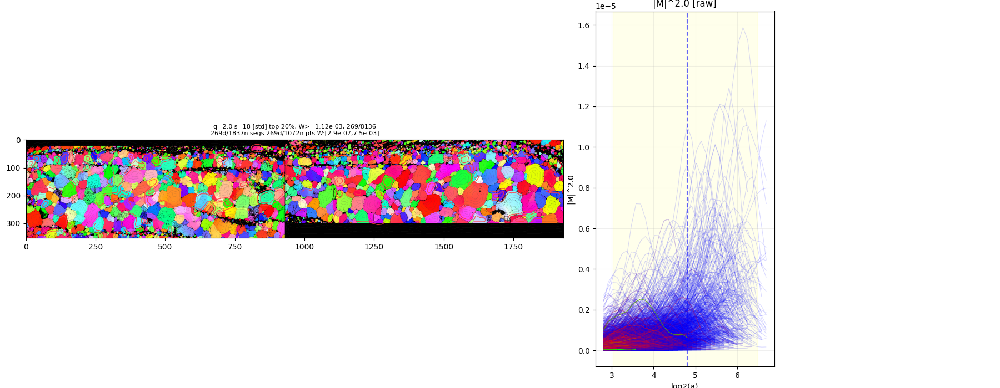

In [458]:
# (%matplotlib widget moved to its own cell near the top)
from ipywidgets import interactive, IntRangeSlider, IntSlider, FloatSlider, Dropdown, Checkbox, Layout
from IPython.display import display as _display_scalebar
from matplotlib.collections import LineCollection

_w_cache = {}
log2_s_global = np.log2(np.array(scales))

# Precompute maxima-line coords and profile line segments
try:
    maxima_coords_cache
except NameError:
    maxima_coords_cache = []
    for ci in range(n_ch):
        sc = skel_chains[ci]
        n_sc = min(sc['n'], nps)
        if n_sc < 2:
            maxima_coords_cache.append(None)
            continue
        coords = [(int(sc['x'][si]), int(sc['y'][si])) for si in range(n_sc)]
        maxima_coords_cache.append(coords)

# Precompute per-scale arrow data
try:
    wt_arg_by_scale
except NameError:
    wt_arg_by_scale = []
    for si in range(nps):
        ext = ext_images[si]
        if ext.extr_nb > 0:
            edata = ext.get_extrema_arrays()
            on_vc = ext.get_on_vertical_chain()
            wt_arg_by_scale.append(edata['arg'][on_vc.astype(bool)].astype(np.float64))
        else:
            wt_arg_by_scale.append(np.array([]))

def get_w(si, q_val, use_chainmax=False):
    key = (int(si), float(q_val), bool(use_chainmax))
    if key in _w_cache:
        return _w_cache[key]
    lm = wt_logmod_by_scale[si]
    if len(lm) == 0:
        _w_cache[key] = np.array([])
        return _w_cache[key]
    if use_chainmax:
        lm = lm.copy()
        for j in range(len(lm)):
            xy = (int(wt_x_by_scale[si][j]), int(wt_y_by_scale[si][j]))
            m_sup = chainmax[si].get(xy, None) if si < len(chainmax) else None
            if m_sup is not None and m_sup > 0:
                lm[j] = np.log(max(m_sup, 1e-30))
    log_w = q_val * lm
    log_w -= log_w.max()
    w = np.exp(log_w)
    Z = w.sum()
    out = w / Z if Z > 0 else w
    _w_cache[key] = out
    return out

_cm = {'red':(255,60,60), 'yellow':(255,255,0), 'cyan':(0,255,255),
       'lime':(0,255,0), 'magenta':(255,0,255), 'orange':(255,165,0),
       'white':(255,255,255), 'gray':(120,120,120), 'dark gray':(60,60,60),
       'blue':(50,100,255), 'green':(50,200,50)}

def classify_chains(scale_idx, q_val, classify_chainmax, thresh_mode, dom_percentile, abs_thresh):
    is_dom_chain = np.zeros(n_ch, dtype=bool)
    if thresh_mode == 'Top percentile':
        w_all = get_w(scale_idx, q_val, classify_chainmax)
        wt2ch = wtmmm_to_chain_by_scale[scale_idx]
        w_nz = w_all[w_all > 0]
        if len(w_nz) == 0:
            return is_dom_chain, 'no data'
        cutoff = np.percentile(w_nz, 100.0 - dom_percentile)
        for j in range(len(w_all)):
            if w_all[j] >= cutoff and j < len(wt2ch) and wt2ch[j] >= 0:
                is_dom_chain[wt2ch[j]] = True
        return is_dom_chain, f'top {dom_percentile:.0f}%, W>={cutoff:.2e}, {is_dom_chain.sum()}/{n_ch}'
    elif thresh_mode == '|M|^q at scale':
        mods = point_mod_by_scale_cmax[scale_idx] if classify_chainmax else point_mod_by_scale_raw[scale_idx]
        ci_arr = point_chain_idx_by_scale[scale_idx]
        if len(mods) == 0:
            return is_dom_chain, 'no data'
        mq = np.power(mods, q_val) if q_val != 0 else np.ones_like(mods)
        mq_max = mq.max()
        if mq_max > 0:
            mq = mq / mq_max  # normalize so max = 1
        for idx in np.where(mq >= abs_thresh)[0]:
            ci = ci_arr[idx]
            if ci >= 0: is_dom_chain[ci] = True
        return is_dom_chain, f'|M|^{q_val:.1f}>={abs_thresh:.2e} (norm), {is_dom_chain.sum()}/{n_ch}'
    elif thresh_mode == 'sup |M|^q (all scales)':
        mods = point_mod_by_scale_cmax[scale_idx]
        ci_arr = point_chain_idx_by_scale[scale_idx]
        if len(mods) == 0:
            return is_dom_chain, 'no data'
        mq = np.power(mods, q_val) if q_val != 0 else np.ones_like(mods)
        mq_max = mq.max()
        if mq_max > 0:
            mq = mq / mq_max  # normalize so max = 1
        for idx in np.where(mq >= abs_thresh)[0]:
            ci = ci_arr[idx]
            if ci >= 0: is_dom_chain[ci] = True
        return is_dom_chain, f'sup|M|^{q_val:.1f}>={abs_thresh:.2e} (norm), {is_dom_chain.sum()}/{n_ch}'
    return is_dom_chain, 'all'

def compute_spectra_fast(is_dom_chain, display_chainmax):
    use_cmax = display_chainmax
    STq_d = np.zeros((n_q_pf, nps), dtype=np.float64)
    STqlogT_d = np.zeros((n_q_pf, nps), dtype=np.float64)
    STq_n = np.zeros((n_q_pf, nps), dtype=np.float64)
    STqlogT_n = np.zeros((n_q_pf, nps), dtype=np.float64)
    for si in range(nps):
        ci_arr = point_chain_idx_by_scale[si]
        if len(ci_arr) == 0: continue
        valid_ci = ci_arr >= 0
        dom_mask = np.zeros(len(ci_arr), dtype=bool)
        dom_mask[valid_ci] = is_dom_chain[ci_arr[valid_ci]]
        if use_cmax:
            m_arr = point_mod_by_scale_cmax[si]
            log_m = np.log(m_arr)
            mq_arr = np.power(m_arr[:, None], q_pf_global[None, :])
            mq_arr[:, q0_mask_global] = 1.0
            logm_mq_arr = log_m[:, None] * mq_arr
        else:
            mq_arr = point_mq_by_scale[si]
            logm_mq_arr = point_logm_mq_by_scale[si]
        if dom_mask.any():
            STq_d[:, si] = mq_arr[dom_mask].sum(axis=0)
            STqlogT_d[:, si] = logm_mq_arr[dom_mask].sum(axis=0)
        non_mask = ~dom_mask
        if non_mask.any():
            STq_n[:, si] = mq_arr[non_mask].sum(axis=0)
            STqlogT_n[:, si] = logm_mq_arr[non_mask].sum(axis=0)
    hd_all = hd_all_cmax_pre if use_cmax else hd_all_raw_pre
    hd_dom = _build_hd_pre(STq_d, STqlogT_d)
    hd_non = _build_hd_pre(STq_n, STqlogT_n)
    return hd_all, hd_dom, hd_non

# ---- Persistent figure (created once) ----
_fig_v = plt.figure(figsize=(18, 7))
_gs_v = _fig_v.add_gridspec(1, 3, width_ratios=[3, 1, 1])
_ax_map = _fig_v.add_subplot(_gs_v[0, 0])
_ax_prof = _fig_v.add_subplot(_gs_v[0, 1])
_ax_dh = _fig_v.add_subplot(_gs_v[0, 2])
_fig_v.tight_layout()

def draw_map(scale_idx, fit_range, q_val, min_vc, min_hchain, classify_chainmax, display_chainmax,
             thresh_mode, dom_percentile, abs_thresh, show_mode, bg_type,
             dom_color, dom_alpha, non_color_name, non_alpha,
             dom_width, non_width, point_size, show_spectra):

    is_dom_chain, thresh_info = classify_chains(
        scale_idx, q_val, classify_chainmax, thresh_mode, dom_percentile, abs_thresh)
    wt2ch = wtmmm_to_chain_by_scale[scale_idx]
    is_dom_wt = np.zeros(len(wt2ch), dtype=bool)
    valid_wt = wt2ch >= 0
    is_dom_wt[valid_wt] = is_dom_chain[wt2ch[valid_wt]]

    w_all = get_w(scale_idx, q_val, classify_chainmax)
    uniform_w = 1.0 / max(1, (w_all > 0).sum()) if len(w_all) > 0 else 0

    dc = _cm.get(dom_color, (255,60,60))
    nc = _cm.get(non_color_name, (60,60,60))
    da = int(round(dom_alpha * 255))
    na = int(round(non_alpha * 255))
    dw = 0 if dom_width <= 0 else max(1, int(np.ceil(dom_width)))
    nw = 0 if non_width <= 0 else max(1, int(np.ceil(non_width)))

    # PIL rendering (same logic)
    bg = bg_dict.get(bg_type, bg_dict['IPF-Z'])
    base = Image.fromarray(bg.copy()).convert('RGBA')
    overlay = Image.new('RGBA', base.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay, 'RGBA')
    n_dom_pts, n_non_pts, n_dom_segs, n_non_segs = 0, 0, 0, 0

    if show_mode in ('Chains + WTMMM', 'Chains only', 'Chains + maxima lines'):
        segments = chain_segments_by_scale[scale_idx]
        for is_d_pass in [False, True]:
            for coords, wt_idx, n_pts in segments:
                if n_pts < min_hchain or len(coords) < 2: continue
                seg_dom = (wt_idx is not None and wt_idx < len(is_dom_wt) and is_dom_wt[wt_idx])
                if seg_dom != is_d_pass: continue
                color = dc if seg_dom else nc
                alpha = da if seg_dom else na
                width = dw if seg_dom else nw
                if alpha > 0 and width > 0:
                    draw.line([(int(x), int(y)) for x, y in coords], fill=(*color, alpha), width=width)
                if seg_dom: n_dom_segs += 1
                else: n_non_segs += 1

    if show_mode in ('Chains + WTMMM', 'WTMMM only', 'Arrows (argument)'):
        wx = wt_x_by_scale[scale_idx]
        wy = wt_y_by_scale[scale_idx]
        w_max_local = w_all.max() + 1e-30 if len(w_all) > 0 else 1.0
        arg_arr = wt_arg_by_scale[scale_idx] if show_mode == 'Arrows (argument)' else None
        mod_arr = np.exp(wt_logmod_by_scale[scale_idx]) if len(wt_logmod_by_scale[scale_idx]) > 0 else np.array([])
        mod_max_s = mod_arr.max() + 1e-30 if len(mod_arr) > 0 else 1.0
        for is_d_pass in [False, True]:
            for j in range(len(wx)):
                if j >= len(w_all) or w_all[j] <= 0: continue
                is_d = j < len(is_dom_wt) and is_dom_wt[j]
                if is_d != is_d_pass: continue
                color_pt = dc if is_d else nc
                alpha_pt = da if is_d else na
                width_pt = dw if is_d else nw
                if alpha_pt <= 0: continue
                px, py = int(wx[j]), int(wy[j])
                if arg_arr is not None and j < len(arg_arr):
                    arg_val = float(arg_arr[j])
                    mod_n = mod_arr[j] / mod_max_s if j < len(mod_arr) else 0
                    al = mod_n * point_size
                    dx_a, dy_a = np.cos(arg_val)*al, np.sin(arg_val)*al
                    draw.line([(px,py),(int(px+dx_a),int(py+dy_a))], fill=(*color_pt,alpha_pt), width=max(1,width_pt))
                    draw.ellipse([px-2,py-2,px+2,py+2], fill=(*color_pt,alpha_pt))
                else:
                    w_n = w_all[j] / w_max_local
                    r = max(1, int(point_size/10*(0.3+0.7*w_n)))
                    draw.ellipse([px-r,py-r,px+r,py+r], fill=(*color_pt,alpha_pt))
                if is_d: n_dom_pts += 1
                else: n_non_pts += 1

    if show_mode in ('Maxima lines', 'Chains + maxima lines'):
        for is_d_pass in [False, True]:
            for ci in range(n_ch):
                if chain_n[ci] < min_vc: continue
                coords = maxima_coords_cache[ci]
                if coords is None: continue
                is_d = is_dom_chain[ci]
                if is_d != is_d_pass: continue
                color = dc if is_d else nc
                alpha = da if is_d else na
                width = dw if is_d else nw
                if alpha > 0 and width > 0:
                    draw.line(coords, fill=(*color,alpha), width=width)

    rendered = np.array(Image.alpha_composite(base, overlay).convert('RGB'))

    # ---- Update persistent figure ----
    _ax_map.cla()
    _ax_prof.cla()
    _ax_dh.cla()
    _ax_dh.set_visible(show_spectra)

    # Map
    _ax_map.imshow(rendered, origin='upper', extent=[0, nxp, nyp, 0], aspect='equal')
    method = 'cmax' if classify_chainmax else 'std'
    w_info = f'W:[{w_all.min():.1e},{w_all.max():.1e}]' if len(w_all) > 0 else ''
    _ax_map.set_title(f'q={q_val:.1f} s={scale_idx} [{method}] {thresh_info}\n'
                      f'{n_dom_segs}d/{n_non_segs}n segs {n_dom_pts}d/{n_non_pts}n pts {w_info}', fontsize=8)

    # Profile (LineCollection)
    fit_lo, fit_hi = fit_range
    cmap_prof = plt.cm.brg
    w_ci = get_w(scale_idx, q_val, classify_chainmax)
    w_color = np.zeros(n_ch, dtype=np.float64)
    for ci in range(min(n_ch, len(w_ci))):
        if chain_n[ci] >= min_vc: w_color[ci] = w_ci[ci]
    w_max = w_color.max() if w_color.max() > 0 else 1.0

    # Sort chains by Boltzmann weight ASCENDING so weakest draw first and
    # the strongest are stacked on top (LineCollection renders in list order,
    # later segments cover earlier ones).
    _active_cis = [ci for ci in range(n_ch) if chain_n[ci] >= min_vc]
    _active_cis.sort(key=lambda ci: w_color[ci])

    lc_segs, lc_colors = [], []
    for ci in _active_cis:
        sc = skel_chains[ci]; n_sc = sc['n']
        if n_sc < 2: continue
        mvals = running_max_matrix[ci, :n_sc] if display_chainmax else sc['mod'][:n_sc]
        with np.errstate(invalid='ignore'):
            yvals = np.power(mvals, q_val) if q_val != 0 else mvals
        pts = np.column_stack([sc['log2_s'], yvals])
        segs = np.stack([pts[:-1], pts[1:]], axis=1)
        lc_segs.append(segs)
        wn = w_color[ci] / w_max
        c = cmap_prof(wn)
        lc_colors.extend([(*c[:3], 0.15+0.85*wn)] * len(segs))
    if lc_segs:
        lc = LineCollection(np.concatenate(lc_segs), colors=lc_colors, linewidths=0.8)
        _ax_prof.add_collection(lc)
        _ax_prof.autoscale()
    _ax_prof.axvline(log2_s_global[scale_idx], color='blue', ls='--', alpha=0.6, lw=1.5)
    _ax_prof.axvspan(log2_s_global[fit_lo], log2_s_global[fit_hi], alpha=0.08, color='yellow')
    # Show threshold line when using coefficient-based thresholding
    if thresh_mode in ('|M|^q at scale', 'sup |M|^q (all scales)') and abs_thresh > 0:
        # The profile plots raw |M|^q, but classify_chains normalizes to max=1.
        # Back-convert: threshold_raw = abs_thresh * max(|M|^q) at this scale
        _mods_prof = point_mod_by_scale_cmax[scale_idx] if display_chainmax else point_mod_by_scale_raw[scale_idx]
        if len(_mods_prof) > 0:
            _mq_prof = np.power(_mods_prof, q_val) if q_val != 0 else np.ones_like(_mods_prof)
            _thresh_raw = abs_thresh * _mq_prof.max()
            _ax_prof.axhline(_thresh_raw, color='red', ls='-', lw=1.5, alpha=0.8,
                             label=f'thresh={abs_thresh:.2e}')
            _ax_prof.legend(fontsize=7, loc='upper left')
    qlabel = f'|M|^{q_val:.1f}' if q_val != 0 else '|M|'
    _ax_prof.set(xlabel='log2(a)', ylabel=qlabel, title=f'{qlabel} [{"cmax" if display_chainmax else "raw"}]')
    _ax_prof.grid(True, alpha=0.2)

    # D(h) panel
    if show_spectra:
        fit_lo_s, fit_hi_s = scales[fit_lo], scales[fit_hi]
        sr = (fit_lo_s, fit_hi_s)
        dom_plot_c = tuple(np.array(dc) / 255.0)
        non_plot_c = tuple(np.array(nc) / 255.0)
        hd_all, hd_dom, hd_non = compute_spectra_fast(is_dom_chain, display_chainmax)
        for hd_cur, color, label in [(hd_all, 'black', 'All'),
                                      (hd_dom, dom_plot_c, 'Dominant'),
                                      (hd_non, non_plot_c, 'Non-dominant')]:
            try:
                sp = extract_hq_Dq_from_plateaus(hd_cur, scale_range=sr)
                vd = np.isfinite(sp['D']) & np.isfinite(sp['h'])
                if vd.any():
                    # Subtract fractional integration exponent from h
                    _fie = globals().get('FRAC_INT_EXPO', 0.0)
                    h_corrected = sp['h'][vd] - _fie
                    _ax_dh.plot(h_corrected, sp['D'][vd], '.-', color=color, lw=2, label=label)
                    _ax_dh.fill_between(h_corrected, sp['D'][vd]-sp['D_err'][vd],
                                        sp['D'][vd]+sp['D_err'][vd], color=color, alpha=0.1)
            except: pass
        _ax_dh.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
        _ax_dh.set(xlabel='h', ylabel='D(h)', title=f'D(h) [{"cmax" if display_chainmax else "raw"}]')
        _ax_dh.legend(fontsize=7); _ax_dh.grid(True, alpha=0.3)

    _fig_v.canvas.draw_idle()

_scalebar_interactive = interactive(
    draw_map,
    scale_idx=IntSlider(value=nps//2, min=0, max=nps-1,
                        description='Scale:', layout=Layout(width='70%'), continuous_update=False),
    fit_range=IntRangeSlider(value=[2, nps-3], min=0, max=nps-1,
                             description='Fit range:', layout=Layout(width='70%'), continuous_update=False),
    q_val=FloatSlider(value=2.0, min=-10.0, max=10.0, step=0.25,
                      description='q:', layout=Layout(width='70%'), continuous_update=False),
    min_vc=IntSlider(value=3, min=1, max=30, step=1,
                     description='Min vc:', layout=Layout(width='50%'), continuous_update=False),
    min_hchain=IntSlider(value=5, min=1, max=200, step=1,
                         description='Min h-chain:', layout=Layout(width='60%'), continuous_update=False),
    classify_chainmax=Checkbox(value=False, description='Classify chainmax'),
    display_chainmax=Checkbox(value=False, description='Display chainmax'),
    thresh_mode=Dropdown(options=['Top percentile', '|M|^q at scale', 'sup |M|^q (all scales)'],
                         value='Top percentile', description='Thresh mode:'),
    dom_percentile=FloatSlider(value=20.0, min=1.0, max=100.0, step=1.0,
                               description='Top %:', layout=Layout(width='60%'), continuous_update=False),
    abs_thresh=FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01,
                           description='|M|^q thresh:', layout=Layout(width='60%'), continuous_update=False),
    show_mode=Dropdown(options=['Chains + WTMMM', 'WTMMM only', 'Arrows (argument)',
                                'Maxima lines', 'Chains + maxima lines', 'Chains only'],
                       value='Chains + WTMMM', description='Show:'),
    bg_type=Dropdown(options=list(bg_dict.keys()), value='IPF-Z', description='Background:'),
    dom_color=Dropdown(options=['red','yellow','cyan','lime','magenta','orange','white','blue','green'],
                       value='red', description='Dom color:'),
    dom_alpha=FloatSlider(value=1.0, min=0.0, max=1.0, step=0.05,
                          description='Dom alpha:', layout=Layout(width='50%'), continuous_update=False),
    non_color_name=Dropdown(options=['red','yellow','cyan','lime','magenta','orange','white','blue','green','gray','dark gray'],
                            value='dark gray', description='Non color:'),
    non_alpha=FloatSlider(value=0.3, min=0.0, max=1.0, step=0.05,
                          description='Non alpha:', layout=Layout(width='50%'), continuous_update=False),
    dom_width=FloatSlider(value=2.0, min=0.5, max=5.0, step=0.5,
                          description='Dom width:', layout=Layout(width='50%'), continuous_update=False),
    non_width=FloatSlider(value=1.0, min=0.0, max=3.0, step=0.5,
                          description='Non width:', layout=Layout(width='50%'), continuous_update=False),
    point_size=FloatSlider(value=15.0, min=1.0, max=50.0, step=1.0,
                           description='Pt/arrow size:', layout=Layout(width='50%'), continuous_update=False),
    show_spectra=Checkbox(value=False, description='Show D(h)'),
)
_display_scalebar(_scalebar_interactive)

## Wavelet Scale Bar (per Turiel 2008, Fig. 2)

A traditional µm scale bar assumes a single characteristic length, but a wavelet
at scale $a$ has at least three meaningful lengths:

1. **Central-lobe width** — the "nominal" scale
2. **Zero-crossings** — set the minimum separation of features the transform can
   resolve (Turiel et al. 2008, *J. Phys. A* 41:015501, Fig. 2: "the zero-crossings
   then correspond to pixel boundaries. For that reason, the number of zero-crossings
   determines the minimum attainable resolution")
3. **Tail extent** — sets how far each singularity estimate is influenced by

`add_wavelet_scalebar(...)` draws a miniature of the wavelet profile with
zero-crossings (red ticks) and tail endpoints (black ticks) marked, converted to
physical units via `px_to_unit`.  The Mexican-hat default used in this notebook
(`WAVELET = 'mexican'`) has three zero-crossings — exactly the case illustrated
in Turiel Fig. 2.  Two modes:

- **`mode='auto'`** — bar length = actual wavelet footprint at the displayed scale.
- **`mode='fixed'`** — bar length represents a user-chosen reference length (e.g.
  50 µm).  The wavelet is drawn at the scale whose footprint equals that reference.


In [ ]:
# --- Wavelet scale bar helper (see Turiel et al. 2008, Fig. 2) ---
#
# Minimal overlay: neon-green wavelet profile drawn directly on the axes
# (no background box).  Vertical neon-green lines mark the outer zero
# crossings — the true support of the analyzing wavelet (Turiel 2008 Fig. 2:
# "the zero-crossings ... correspond to pixel boundaries ... the number of
# zero-crossings determines the minimum attainable resolution").  The tails
# of the wavelet past the outer zero crossings are still drawn so the full
# shape is visible, but they are not marked.  The label shows the zero-
# crossing support in the user-supplied physical unit only (no pixel
# readout).  The drawing uses a single pixels-→-axes-fraction scale
# factor, so the rendered curve is true-to-scale against the underlying
# image: one pixel of wavelet profile == one pixel of the image.

import matplotlib.patheffects as path_effects


def gaussian_gradient_profile(x, scale):
    """Scalar 1st-derivative-of-Gaussian (g1 family, 1 vanishing moment).

    Shape: x * exp(-x²/(4·scale²))
    Odd function with a single zero crossing at x=0; extrema at x=±√2·scale.
    """
    p = x * np.exp(-(x * x) / (4.0 * scale * scale))
    m = float(np.max(np.abs(p)))
    return p / m if m > 0 else p


def mexican_hat_profile(x, scale):
    """Scalar Ricker / Mexican-hat wavelet (g2 family, 3 vanishing moments).

    Shape: (1 - x²/(4·scale²)) * exp(-x²/(4·scale²))
    Zero crossings at x = ±2·scale — these define the true support used by
    the scale bar (Turiel 2008, Fig. 2).
    """
    a2 = scale * scale
    p = (1.0 - (x * x) / (4.0 * a2)) * np.exp(-(x * x) / (4.0 * a2))
    m = float(np.max(np.abs(p)))
    return p / m if m > 0 else p


# Back-compat alias for the earlier v2 naming.
mexican_gradient_profile = mexican_hat_profile


_WAVELET_PROFILE_REGISTRY = {
    'gaussian': gaussian_gradient_profile,   # g1, 1 vanishing moment
    'mexican':  mexican_hat_profile,         # g2, 3 vanishing moments (scalar Ricker)
}


def _wavelet_zero_crossings(profile, x):
    """Return x-values of sign changes in `profile` (linear interpolation)."""
    p = np.asarray(profile)
    zcs = []
    for i in range(len(p) - 1):
        a, b = p[i], p[i + 1]
        if a == 0.0:
            zcs.append(float(x[i]))
        elif a * b < 0:
            frac = -a / (b - a)
            zcs.append(float(x[i] + frac * (x[i + 1] - x[i])))
    return np.array(zcs)


def _wavelet_support_from_zcs(profile, x):
    """True support span: between outermost zero crossings when >=2 exist;
    otherwise fall back to the outermost local maxima of |profile|
    (e.g. the g1 gradient, which has only a single ZC at x=0 but two lobes)."""
    zcs = _wavelet_zero_crossings(profile, x)
    if len(zcs) >= 2:
        return float(zcs.min()), float(zcs.max()), zcs
    p = np.abs(np.asarray(profile))
    local_max_idx = [
        i for i in range(1, len(p) - 1)
        if p[i] >= p[i - 1] and p[i] >= p[i + 1] and p[i] > 0
    ]
    if len(local_max_idx) >= 2:
        return float(x[local_max_idx[0]]), float(x[local_max_idx[-1]]), zcs
    return float(x[0]), float(x[-1]), zcs


def _wavelet_tail_range(profile, x, tail_threshold):
    """Return (x_tlo, x_thi) where |profile| first/last exceeds
    `tail_threshold * max|profile|`."""
    p = np.abs(np.asarray(profile))
    pmax = float(p.max())
    if pmax == 0:
        return float(x[0]), float(x[-1])
    mask = p >= tail_threshold * pmax
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return float(x[0]), float(x[-1])
    return float(x[idx[0]]), float(x[idx[-1]])


def _infer_image_pixel_width(ax):
    """Return the pixel width of the first image drawn on `ax`, or None."""
    imgs = ax.get_images()
    if imgs:
        try:
            arr = imgs[0].get_array()
            return int(arr.shape[1])  # columns = pixel width
        except Exception:
            return None
    return None


def add_wavelet_scalebar(
    ax,
    *,
    mode='auto',
    scale=None,
    ref_length=None,
    px_to_unit=1.0,
    unit_str='px',
    wavelet='gaussian',
    profile_fn=None,
    tail_threshold=0.01,              # fraction of peak |profile| defining tail cutoff
    loc='lower right',
    pad_frac=0.02,
    width_frac=None,                  # None = auto-size from tail-to-tail extent
    min_width_frac=0.0,
    max_width_frac=None,
    height_frac=0.12,
    face_alpha=0.88,                  # kept for back-compat; no longer used
    box_color='white',                # kept for back-compat; no longer used
    wavelet_color='#39FF14',          # neon green
    mark_color='#39FF14',             # neon green
    fontsize=8,
    image_pixel_width=None,           # override auto-detection
):
    """Draw a minimal wavelet-shaped scale bar on `ax`.

    The bar draws a miniature of the scalar wavelet at the displayed scale
    directly on the axes (no background box).  The full wavelet shape —
    including the tails past the outermost zero crossings — is rendered,
    but only the outer zero crossings are marked with vertical lines,
    because they define the true support of the analyzing wavelet
    (Turiel et al. 2008, J. Phys. A 41:015501, Fig. 2).  The label value
    reports the zero-crossing support length.

    The rendered wavelet is sized so that one profile pixel equals one
    image pixel (shared 1/img_nx axes-fraction scale factor), which makes
    the visual footprint true-to-scale against the underlying image.

    Parameters
    ----------
    ax : matplotlib Axes
    mode : {'auto', 'fixed'}
        'auto':  bar length = actual zero-crossing support at `scale`;
                 label shows the physical length.
        'fixed': bar length represents `ref_length` in `unit_str`; the
                 wavelet is drawn at the scale whose ZC support equals
                 `ref_length` so the rendered shape matches.
    scale : float
        Wavelet scale in pixels.  Required for mode='auto'.
    ref_length : float
        Reference length for mode='fixed' (same physical units as
        implied by px_to_unit).
    px_to_unit : float
        Physical length of one pixel (e.g. 0.2 µm/px for EBSD).
    unit_str : str
        Unit string in the label (e.g. 'µm').
    wavelet : {'gaussian', 'mexican'}
    profile_fn : callable, optional
        Custom profile (x_array, scale) -> 1D ndarray.  Overrides `wavelet`.
    tail_threshold : float
        Fraction of max|profile| at which the tails are truncated for
        drawing (default 1%).  Does not affect the label value.
    loc : {'lower right', 'lower left', 'upper right', 'upper left'}
    pad_frac, height_frac : float
        Padding and height in axes-fraction units.
    width_frac : float or None
        Total drawn width as a fraction of the axis.  If None (default),
        the width is auto-computed from the tail-to-tail extent ratio to
        the image pixel width so 1 profile px == 1 image px.
    wavelet_color, mark_color : color
        Colors of the wavelet curve and the zero-crossing vertical lines.
        Default neon green with a black stroke so it's visible on any
        background.
    image_pixel_width : int, optional
        Image width in pixels.  Auto-detected from `ax.get_images()` if
        not provided.

    Examples
    --------
    >>> add_wavelet_scalebar(ax, mode='auto', scale=20.0,
    ...                      px_to_unit=0.2, unit_str='µm', wavelet='mexican')
    """
    if profile_fn is None:
        if wavelet not in _WAVELET_PROFILE_REGISTRY:
            raise ValueError(
                f"wavelet must be one of {list(_WAVELET_PROFILE_REGISTRY)} "
                f"or pass profile_fn=... (got {wavelet!r})"
            )
        profile_fn = _WAVELET_PROFILE_REGISTRY[wavelet]

    # --- Resolve effective scale ---
    if mode == 'auto':
        if scale is None:
            raise ValueError("mode='auto' requires `scale` (wavelet scale in px).")
        eff_scale = float(scale)
    elif mode == 'fixed':
        if ref_length is None:
            raise ValueError("mode='fixed' requires `ref_length`.")
        if px_to_unit <= 0:
            raise ValueError("px_to_unit must be positive.")
        desired_support_px = float(ref_length) / float(px_to_unit)
        x_probe = np.linspace(-20.0, 20.0, 4001)
        prof_probe = profile_fn(x_probe, 1.0)
        x_lo_p, x_hi_p, _ = _wavelet_support_from_zcs(prof_probe, x_probe)
        support_at_s1 = x_hi_p - x_lo_p
        if support_at_s1 <= 0:
            raise ValueError("Could not determine wavelet support at scale=1.")
        eff_scale = desired_support_px / support_at_s1
    else:
        raise ValueError(f"mode must be 'auto' or 'fixed' (got {mode!r}).")

    # Sample the profile wide enough to capture the full tails.
    x_samples = np.linspace(-12.0 * eff_scale, 12.0 * eff_scale, 4001)
    prof = profile_fn(x_samples, eff_scale)

    # Zero-crossing support → what the label measures.
    x_zc_lo, x_zc_hi, zcs = _wavelet_support_from_zcs(prof, x_samples)
    zc_footprint_px = x_zc_hi - x_zc_lo
    if zc_footprint_px <= 0:
        raise ValueError("Wavelet support is zero — check scale / profile.")

    # Tail extent → what gets drawn.
    x_tlo, x_thi = _wavelet_tail_range(prof, x_samples, tail_threshold)
    # Ensure the tail range always encloses the ZC range.
    x_tlo = min(x_tlo, x_zc_lo)
    x_thi = max(x_thi, x_zc_hi)
    tail_footprint_px = x_thi - x_tlo

    label_val = (zc_footprint_px * float(px_to_unit)
                 if mode == 'auto' else float(ref_length))

    # --- Resolve drawn-region width (axes-fraction, tail-to-tail) ---
    if width_frac is None:
        img_nx = image_pixel_width
        if img_nx is None:
            img_nx = _infer_image_pixel_width(ax)
        if img_nx is None or img_nx <= 0:
            xlo_ax, xhi_ax = ax.get_xlim()
            img_nx = max(1.0, abs(xhi_ax - xlo_ax))
        # 1 profile pixel == 1 image pixel (true-to-scale)
        eff_width_frac = tail_footprint_px / float(img_nx)
        if min_width_frac is not None:
            eff_width_frac = max(float(min_width_frac), eff_width_frac)
        if max_width_frac is not None:
            eff_width_frac = min(float(max_width_frac), eff_width_frac)
    else:
        eff_width_frac = float(width_frac)

    # --- Anchor the drawn region in axes-fraction coordinates ---
    loc_table = {
        'lower right': (1.0 - pad_frac - eff_width_frac, pad_frac),
        'lower left':  (pad_frac,                        pad_frac),
        'upper right': (1.0 - pad_frac - eff_width_frac, 1.0 - pad_frac - height_frac),
        'upper left':  (pad_frac,                        1.0 - pad_frac - height_frac),
    }
    if loc not in loc_table:
        raise ValueError(f"loc must be one of {list(loc_table)}")
    box_x0, box_y0 = loc_table[loc]
    box_w = eff_width_frac
    box_h = height_frac

    bar_x0 = box_x0
    bar_x1 = box_x0 + box_w
    bar_span = bar_x1 - bar_x0

    # Vertical layout: curve sits in the upper portion, label beneath.
    band_amp_frac = 0.40
    band_cy = box_y0 + 0.68 * box_h
    label_cy = box_y0 + 0.08 * box_h

    def x_to_ax(xv):
        # Maps profile-space x (spanning tail-to-tail) to axes-fraction.
        return bar_x0 + (xv - x_tlo) / tail_footprint_px * bar_span

    def amp_to_ax(pv):
        return band_cy + pv * band_amp_frac * box_h

    # Black stroke around neon elements so they're legible on any background.
    curve_fx = [path_effects.withStroke(linewidth=3.0, foreground='black')]
    line_fx  = [path_effects.withStroke(linewidth=3.0, foreground='black')]
    text_fx  = [path_effects.withStroke(linewidth=2.5, foreground='black')]

    # Wavelet curve drawn over the full tail range.
    crop = (x_samples >= x_tlo) & (x_samples <= x_thi)
    ax.plot(
        x_to_ax(x_samples[crop]),
        amp_to_ax(prof[crop]),
        color=wavelet_color,
        lw=1.6,
        transform=ax.transAxes,
        zorder=11,
        clip_on=False,
        path_effects=curve_fx,
        solid_capstyle='round',
    )

    # Vertical lines at every zero crossing inside the drawn range.
    y_lo = band_cy - band_amp_frac * box_h
    y_hi = band_cy + band_amp_frac * box_h
    for zc in zcs:
        if zc < x_tlo - 1e-9 or zc > x_thi + 1e-9:
            continue
        zc_ax = x_to_ax(zc)
        ax.plot(
            [zc_ax, zc_ax], [y_lo, y_hi],
            color=mark_color,
            lw=1.4,
            transform=ax.transAxes,
            zorder=12,
            clip_on=False,
            path_effects=line_fx,
            solid_capstyle='round',
        )

    # Label text: physical unit only, centered on the ZC support (not
    # the tail box) so the number sits directly under the "real" scale bar.
    if label_val >= 100:
        val_str = f"{label_val:.0f}"
    elif label_val >= 10:
        val_str = f"{label_val:.1f}"
    elif label_val >= 1:
        val_str = f"{label_val:.2f}"
    else:
        val_str = f"{label_val:.3g}"
    label_text = f"{val_str} {unit_str}"

    label_ax_x = x_to_ax(0.5 * (x_zc_lo + x_zc_hi))
    ax.text(
        label_ax_x, label_cy, label_text,
        ha='center', va='center',
        fontsize=fontsize, color=wavelet_color, fontweight='bold',
        transform=ax.transAxes, zorder=13, clip_on=False,
        path_effects=text_fx,
    )


print("add_wavelet_scalebar: tails now drawn past the ZC bars; only outer "
      "zero crossings are marked.")


add_wavelet_scalebar: tails now drawn past the ZC bars; only outer zero crossings are marked.


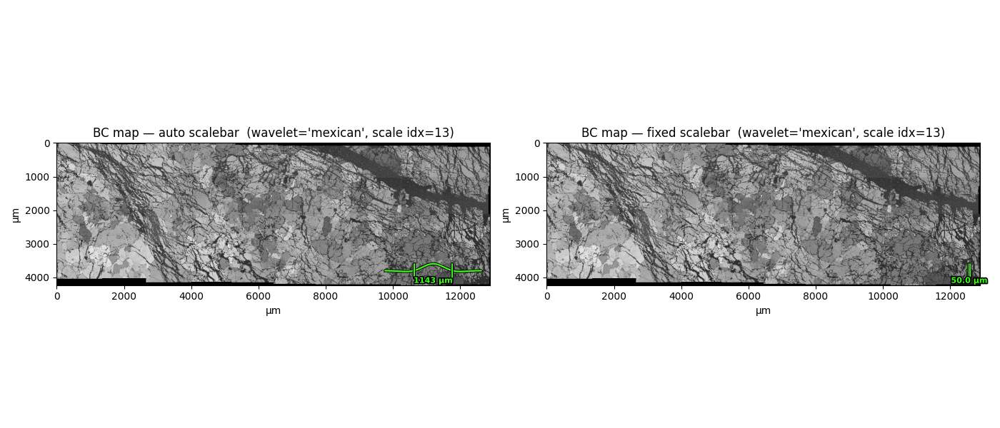

In [ ]:
# --- Demo: add_wavelet_scalebar on the BC map for the current EBSD dataset ---

demo_scale_idx = len(scales) // 2
demo_scale = float(scales[demo_scale_idx])

# Pixel size from CTF metadata (µm/pixel)
px_um = float(meta['xstep'])

bc = ebsd['bc'].astype(np.float32)
nx_img, ny_img = meta['xcells'], meta['ycells']
extent_um = [0, nx_img * meta['xstep'], ny_img * meta['ystep'], 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, mode_label in zip(axes, ['auto', 'fixed']):
    ax.imshow(bc, cmap='gray', extent=extent_um)
    ax.set_xlabel('µm')
    ax.set_ylabel('µm')
    ax.set_title(f"BC map — {mode_label} scalebar  "
                 f"(wavelet={WAVELET!r}, scale idx={demo_scale_idx})")

# Auto: bar length = actual wavelet footprint at demo_scale, converted to µm
add_wavelet_scalebar(
    axes[0],
    mode='auto',
    scale=demo_scale,
    px_to_unit=px_um, unit_str='µm',
    wavelet=WAVELET,
    loc='lower right',
)

# Fixed: 50 µm reference bar, wavelet drawn at the scale whose footprint = 50 µm
add_wavelet_scalebar(
    axes[1],
    mode='fixed',
    ref_length=50.0,
    px_to_unit=px_um, unit_str='µm',
    wavelet=WAVELET,
    loc='lower right',
)

plt.tight_layout()
plt.show()


In [ ]:
# --- Interactive per-scale GIF builder ---
#
# For each scale, shows the interactive viewer so you can adjust the threshold,
# then press "Accept & Next" to lock that scale's settings and advance.
# After all scales are done, assembles the GIF.
#
# When using coefficient-based thresholding (|M|^q modes), a horizontal
# threshold line is drawn on the profile panel.

import io, os, threading
from PIL import Image as PILImage
from IPython.display import Image as IPImage, display as ipy_display, clear_output
from ipywidgets import Button, HBox, VBox, IntSlider, FloatSlider, Dropdown, Checkbox, Layout, Output, Label

if 'draw_map' not in globals():
    raise RuntimeError("draw_map() not defined — run the interactive viewer cell first.")

# ============================================================================
# Parameters
# ============================================================================
GIF_SCALE_IDX_MIN  = 0
GIF_SCALE_IDX_MAX  = nps - 1
GIF_SCALE_IDX_STEP = max(1, nps // 20)
GIF_FPS            = 4
GIF_DPI            = 80
GIF_PING_PONG      = True

px_um = float(meta['xstep'])
_safe_name = "".join(ch if (ch.isalnum() or ch in '._-') else '_'
                     for ch in str(meta.get('name', 'ebsd')))
GIF_PATH = f"ebsd_wtmm_scalebar_{_safe_name}.gif"

# ============================================================================
# Pull defaults from existing interactive viewer
# ============================================================================
_defaults = dict(_scalebar_interactive.kwargs)

# Per-scale threshold storage
_scale_indices = list(range(GIF_SCALE_IDX_MIN, GIF_SCALE_IDX_MAX + 1, GIF_SCALE_IDX_STEP))
_per_scale_settings = {}  # scale_idx -> dict of slider values

# ============================================================================
# Interactive per-scale editor
# ============================================================================
_gif_out = Output()
_gif_status = Label(value=f'Scale 0/{len(_scale_indices)}')

_gif_q = FloatSlider(value=_defaults.get('q_val', 2.0), min=-10.0, max=10.0, step=0.25,
                     description='q:', layout=Layout(width='60%'), continuous_update=False)
_gif_thresh_mode = Dropdown(
    options=['Top percentile', '|M|^q at scale', 'sup |M|^q (all scales)'],
    value=_defaults.get('thresh_mode', 'Top percentile'), description='Thresh:')
_gif_percentile = FloatSlider(value=_defaults.get('dom_percentile', 20.0),
                              min=1.0, max=100.0, step=1.0,
                              description='Top %:', layout=Layout(width='50%'), continuous_update=False)
_gif_abs_thresh = FloatSlider(value=_defaults.get('abs_thresh', 0.0),
                              min=0.0, max=1.0, step=0.01,
                              description='|M|^q thresh:', layout=Layout(width='60%'), continuous_update=False)
_gif_classify_cmax = Checkbox(value=_defaults.get('classify_chainmax', False), description='Classify cmax')
_gif_display_cmax = Checkbox(value=_defaults.get('display_chainmax', False), description='Display cmax')

_gif_preview_btn = Button(description='Preview', button_style='info')
_gif_accept_btn = Button(description='Accept & Next', button_style='success')
_gif_skip_btn = Button(description='Skip Scale', button_style='warning')
_gif_build_btn = Button(description='Build GIF', button_style='danger')

_gif_current_idx = [0]  # mutable counter

def _gif_current_si():
    idx = _gif_current_idx[0]
    if idx < len(_scale_indices):
        return _scale_indices[idx]
    return _scale_indices[-1]

def _gif_draw_current():
    si = _gif_current_si()
    _gif_status.value = f'Scale {_gif_current_idx[0]+1}/{len(_scale_indices)} (idx={si}, a={scales[si]:.1f})'
    kwargs = dict(_defaults)
    kwargs['scale_idx'] = si
    kwargs['q_val'] = _gif_q.value
    kwargs['thresh_mode'] = _gif_thresh_mode.value
    kwargs['dom_percentile'] = _gif_percentile.value
    kwargs['abs_thresh'] = _gif_abs_thresh.value
    kwargs['classify_chainmax'] = _gif_classify_cmax.value
    kwargs['display_chainmax'] = _gif_display_cmax.value
    kwargs['show_spectra'] = True
    draw_map(**kwargs)
    # Add scalebar
    try:
        add_wavelet_scalebar(
            _ax_map, mode='auto', scale=float(scales[si]),
            px_to_unit=px_um, unit_str='\u00b5m', wavelet=WAVELET,
            loc='lower right', fontsize=9)
    except Exception:
        pass
    _fig_v.canvas.draw_idle()

def _on_preview(btn):
    _gif_draw_current()

def _on_accept(btn):
    si = _gif_current_si()
    _per_scale_settings[si] = {
        'q_val': _gif_q.value,
        'thresh_mode': _gif_thresh_mode.value,
        'dom_percentile': _gif_percentile.value,
        'abs_thresh': _gif_abs_thresh.value,
        'classify_chainmax': _gif_classify_cmax.value,
        'display_chainmax': _gif_display_cmax.value,
    }
    _gif_current_idx[0] += 1
    if _gif_current_idx[0] < len(_scale_indices):
        _gif_draw_current()
    else:
        _gif_status.value = f'All {len(_scale_indices)} scales configured. Press "Build GIF".'

def _on_skip(btn):
    si = _gif_current_si()
    # Use current slider values as-is
    _per_scale_settings[si] = {
        'q_val': _gif_q.value,
        'thresh_mode': _gif_thresh_mode.value,
        'dom_percentile': _gif_percentile.value,
        'abs_thresh': _gif_abs_thresh.value,
        'classify_chainmax': _gif_classify_cmax.value,
        'display_chainmax': _gif_display_cmax.value,
    }
    _gif_current_idx[0] += 1
    if _gif_current_idx[0] < len(_scale_indices):
        _gif_draw_current()
    else:
        _gif_status.value = f'All {len(_scale_indices)} scales configured. Press "Build GIF".'

def _on_build(btn):
    with _gif_out:
        clear_output(wait=True)
        # Fill in any unconfigured scales with defaults
        for si in _scale_indices:
            if si not in _per_scale_settings:
                _per_scale_settings[si] = {
                    'q_val': _gif_q.value,
                    'thresh_mode': _gif_thresh_mode.value,
                    'dom_percentile': _gif_percentile.value,
                    'abs_thresh': _gif_abs_thresh.value,
                    'classify_chainmax': _gif_classify_cmax.value,
                    'display_chainmax': _gif_display_cmax.value,
                }

        print(f'Building GIF: {len(_scale_indices)} forward frames at {GIF_FPS} fps...')
        forward_pil = []
        for k, si in enumerate(_scale_indices):
            settings = _per_scale_settings[si]
            kwargs = dict(_defaults)
            kwargs['scale_idx'] = si
            kwargs.update(settings)
            kwargs['show_spectra'] = True
            draw_map(**kwargs)
            try:
                add_wavelet_scalebar(
                    _ax_map, mode='auto', scale=float(scales[si]),
                    px_to_unit=px_um, unit_str='\u00b5m', wavelet=WAVELET,
                    loc='lower right', fontsize=9)
            except Exception:
                pass
            _fig_v.canvas.draw()
            buf = io.BytesIO()
            _fig_v.savefig(buf, format='png', dpi=GIF_DPI, bbox_inches='tight',
                           facecolor='white')
            buf.seek(0)
            forward_pil.append(PILImage.open(buf).convert('RGB').copy())
            buf.close()
            if (k + 1) % 5 == 0 or (k + 1) == len(_scale_indices):
                print(f"  frame {k+1}/{len(_scale_indices)}  (a={scales[si]:.1f})")

        if GIF_PING_PONG and len(forward_pil) > 2:
            pil_frames = forward_pil + forward_pil[-2:0:-1]
        else:
            pil_frames = forward_pil

        duration_ms = int(1000 / GIF_FPS)
        pil_frames[0].save(
            GIF_PATH, save_all=True, append_images=pil_frames[1:],
            duration=duration_ms, loop=0, optimize=True, disposal=2)
        _size_kb = os.path.getsize(GIF_PATH) // 1024
        print(f"\nSaved {len(pil_frames)} frames: {os.path.abspath(GIF_PATH)}  ({_size_kb} KB)")
        ipy_display(IPImage(GIF_PATH))

_gif_preview_btn.on_click(_on_preview)
_gif_accept_btn.on_click(_on_accept)
_gif_skip_btn.on_click(_on_skip)
_gif_build_btn.on_click(_on_build)

# Layout
_gif_controls = VBox([
    _gif_status,
    HBox([_gif_q, _gif_thresh_mode]),
    HBox([_gif_percentile, _gif_abs_thresh]),
    HBox([_gif_classify_cmax, _gif_display_cmax]),
    HBox([_gif_preview_btn, _gif_accept_btn, _gif_skip_btn, _gif_build_btn]),
    _gif_out,
])

# Start
_gif_current_idx[0] = 0
_gif_draw_current()
ipy_display(_gif_controls)

## Summary of All Datasets

Quick scan of every CTF file — dimensions, step size, phases, indexing rate.

In [ ]:
rows = []
for i, (path, label) in enumerate(zip(ctf_files, labels)):
    try:
        d = read_ctf(path)
        m = d['meta']
        indexed = np.count_nonzero(d['phase']) if d['phase'] is not None else '?'
        total = d['phase'].size if d['phase'] is not None else m['xcells']*m['ycells']
        pct = f"{100*indexed/total:.1f}%" if isinstance(indexed, (int, np.integer)) else '?'
        phase_names = ', '.join(
            info[2] for info in m.get('phases', {}).values() if len(info) > 2
        )
        rows.append({
            'idx': i, 'name': label,
            'nx': m['xcells'], 'ny': m['ycells'],
            'step_µm': m['xstep'],
            'size_µm': f"{m['xcells']*m['xstep']:.0f}×{m['ycells']*m['ystep']:.0f}",
            'indexed': pct,
            'phases': phase_names[:50]
        })
    except Exception as ex:
        rows.append({'idx': i, 'name': label, 'nx': '?', 'ny': '?', 'error': str(ex)[:60]})

summary_df = pd.DataFrame(rows)
display(summary_df)